#사전준비


In [ ]:
# 사용할 라이브러리 가져오기
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 시각화 보조 라이브러리
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,617 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direc

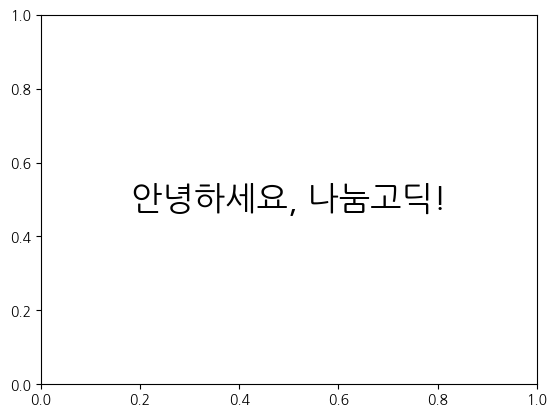

In [ ]:
# 시각화 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
!apt-get install -y fonts-nanum
!fc-cache -fv
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.text(0.5, 0.5, '안녕하세요, 나눔고딕!', ha='center', va='center', size=24)
plt.show()

import seaborn as sns
from matplotlib import rc

sns.set(style="whitegrid")

# 한글 폰트 설정
rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#sql 설치 및 사용


In [ ]:
!pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=85bb106b8892152ecb85173e870ca4ddff611685e17fcb232080ac3ad504b378
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [ ]:
from pandasql import sqldf

mysql = lambda q: sqldf(q, globals())

# 구독 서비스 덤프 데이터

##Google Drive 연결

In [ ]:
# utf8mb4_unicode_ci 변환

input_path = "/content/drive/MyDrive/코드잇스프린트_DA16기_part_2/중급 프로젝트/중급 프로젝트 덤프 데이터/DAproject_middle1_topic2_subscription_dump.sql"
output_path = "/content/drive/MyDrive/코드잇스프린트_DA16기_part_2/중급 프로젝트/중급 프로젝트 덤프 데이터/DAproject_middle1_topic2_subscription_dump.sql_mariadb.sql"

with open(input_path, "r", encoding="utf-8", errors="replace") as infile, \
     open(output_path, "w", encoding="utf-8") as outfile:

    for line in infile:
        line = line.replace(
            "utf8mb4_0900_ai_ci",
            "utf8mb4_unicode_ci"
        )
        outfile.write(line)

print("✅ 변환 완료")
print(output_path)

In [ ]:
# 파일 확인

print(os.path.exists(output_path))
print(f"{os.path.getsize(output_path) / 1024**3:.2f} GB")

## MariaDB 설치

In [ ]:
# MariaDB 설치

!apt-get update -qq
!apt-get install -y mariadb-server

In [ ]:
# 서버 시작
!service mariadb start

In [ ]:
# 데이터 베이스 생성
!mysql -u root -e "CREATE DATABASE IF NOT EXISTS project_db CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci;"

## SQL 파일 복원

In [ ]:
# 테이블 확인
!mysql -D project_db -e "SHOW TABLES;"

# 선정 과정

### 분석 테이블 설정





'start_free_trial'제외한 나머지 테이블

무료체험(start_free_trial)은 2023년 4월 매출 기여도가 낮아 폐지된 정책으로, 운영 측에서 이미 효과 검토가 완료된 기능이다. 이에 본 프로젝트에서는 현재 서비스의 사용자 행동 분석에 집중하기 위해 해당 테이블을 분석에서 제외하였다.

### 분석 범위

실제 데이터 : 2022년 1월 1일 ~ 2023년 12월 31일

분석 데이터 : 2022년 12월 1일 ~ 2023년 11월 30일

**분석 범위 선정 이유**

이벤트 테이블의 공통 데이터가 존재하는 기간을 기준으로 분석 범위를 설정하였으며, 월별 분석의 일관성을 위해 최종 분석 기간을 2022년 12월 1일부터 2023년 11월 30일까지로 선정하였다.

##  분석 대상

이벤트 테이블에서 유저를 구별할 수 있는 식별자는 ‘user_id’ 뿐이었고 비회원의 모수를 파악할 수 있는 속성은 존재하지 않았다. 따라서 우리의 분석 범위는 회원으로 한정 하였다.

### 전처리 과정

In [ ]:
# 분석 범위 내 데이터 생성

sql = """
DROP TABLE IF EXISTS enter_main_page_filtered;

CREATE TABLE enter_main_page_filtered AS
SELECT *
FROM enter_main_page
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';


DROP TABLE IF EXISTS enter_signup_page_filtered;

CREATE TABLE enter_signup_page_filtered AS
SELECT *
FROM enter_signup_page
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';


DROP TABLE IF EXISTS complete_signup_filtered;

CREATE TABLE complete_signup_filtered AS
SELECT *
FROM complete_signup
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';


DROP TABLE IF EXISTS enter_content_page_filtered;

CREATE TABLE enter_content_page_filtered AS
SELECT *
FROM enter_content_page
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';


DROP TABLE IF EXISTS click_content_page_start_content_button_filtered;

CREATE TABLE click_content_page_start_content_button_filtered AS
SELECT *
FROM click_content_page_start_content_button
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';


DROP TABLE IF EXISTS click_content_page_more_review_button_filtered;

CREATE TABLE click_content_page_more_review_button_filtered AS
SELECT *
FROM click_content_page_more_review_button
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';


DROP TABLE IF EXISTS enter_payment_page_filtered;

CREATE TABLE enter_payment_page_filtered AS
SELECT *
FROM enter_payment_page
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';


DROP TABLE IF EXISTS complete_subscription_filtered;

CREATE TABLE complete_subscription_filtered AS
SELECT *
FROM complete_subscription
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';


DROP TABLE IF EXISTS renew_subscription_filtered;

CREATE TABLE renew_subscription_filtered AS
SELECT *
FROM renew_subscription
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';


DROP TABLE IF EXISTS resubscribe_subscription_filtered;

CREATE TABLE resubscribe_subscription_filtered AS
SELECT *
FROM resubscribe_subscription
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';


DROP TABLE IF EXISTS start_content_filtered;

CREATE TABLE start_content_filtered AS
SELECT *
FROM start_content
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';


DROP TABLE IF EXISTS enter_lesson_page_filtered;

CREATE TABLE enter_lesson_page_filtered AS
SELECT *
FROM enter_lesson_page
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';


DROP TABLE IF EXISTS complete_lesson_filtered;

CREATE TABLE complete_lesson_filtered AS
SELECT *
FROM complete_lesson
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';


DROP TABLE IF EXISTS click_lesson_page_related_question_box_filtered;

CREATE TABLE click_lesson_page_related_question_box_filtered AS
SELECT *
FROM click_lesson_page_related_question_box
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';


DROP TABLE IF EXISTS end_content_filtered;

CREATE TABLE end_content_filtered AS
SELECT *
FROM end_content
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';


DROP TABLE IF EXISTS click_cancel_plan_button_filtered;

CREATE TABLE click_cancel_plan_button_filtered AS
SELECT *
FROM click_cancel_plan_button
WHERE client_event_time >= '2022-12-01'
  AND client_event_time < '2023-12-01';
"""

with open("/content/create_filtered_tables.sql", "w", encoding="utf-8") as f:
    f.write(sql)

!sudo mysql project_db < /content/create_filtered_tables.sql


In [ ]:
## anaysis_population_filtered 생성
## userid와 결제자 미결제자 구분자
sql = """
DROP TABLE IF EXISTS analysis_population_filtered;

CREATE TABLE analysis_population_filtered AS
SELECT DISTINCT
    user_id
FROM complete_signup_filtered
WHERE user_id IS NOT NULL;

ALTER TABLE analysis_population_filtered
ADD COLUMN is_subscriber TINYINT DEFAULT 0;

UPDATE analysis_population_filtered ap
JOIN (
    SELECT DISTINCT
        user_id
    FROM complete_subscription_filtered
    WHERE user_id IS NOT NULL
) cs
    ON ap.user_id = cs.user_id
SET ap.is_subscriber = 1;

DELETE ap
FROM analysis_population_filtered ap
JOIN (
    SELECT user_id
    FROM renew_subscription_filtered
    WHERE user_id IS NOT NULL

    UNION

    SELECT user_id
    FROM resubscribe_subscription_filtered
    WHERE user_id IS NOT NULL
) abnormal
    ON ap.user_id = abnormal.user_id
WHERE ap.is_subscriber = 0;

SELECT
    CONCAT(
        FORMAT(COUNT(*), 0),
        '명'
    ) AS total_users,

    CONCAT(
        FORMAT(SUM(is_subscriber = 1), 0),
        '명'
    ) AS subscriber_users,

    CONCAT(
        FORMAT(
            SUM(is_subscriber = 1)
            / COUNT(*) * 100,
            2
        ),
        '%'
    ) AS subscriber_rate,

    CONCAT(
        FORMAT(SUM(is_subscriber = 0), 0),
        '명'
    ) AS non_subscriber_users,

    CONCAT(
        FORMAT(
            SUM(is_subscriber = 0)
            / COUNT(*) * 100,
            2
        ),
        '%'
    ) AS non_subscriber_rate

FROM analysis_population_filtered;
"""

with open(
    "/content/create_analysis_population.sql",
    "w",
    encoding="utf-8"
) as f:
    f.write(sql)

!sudo mysql project_db < /content/create_analysis_population.sql

In [ ]:
!sudo mysql project_db -e "SELECT * FROM analysis_population_filtered LIMIT 10;"

In [ ]:
# 변환 과정은 데이터가 너무커서 자꾸 다운 되서 과정만 써놓았음

# ============================================================
# SQL 테이블 → CSV 변환
# ============================================================

SAVE_PATH = "/content/drive/MyDrive/csv"
os.makedirs(SAVE_PATH, exist_ok=True)


tables = [
    "enter_main_page_filtered",
    "enter_signup_page_filtered",
    "complete_signup_filtered",
    "enter_content_page_filtered",
    "click_content_page_start_content_button_filtered",
    "click_content_page_more_review_button_filtered",
    "enter_payment_page_filtered",
    "complete_subscription_filtered",
    "renew_subscription_filtered",
    "resubscribe_subscription_filtered",
    "start_content_filtered",
    "enter_lesson_page_filtered",
    "complete_lesson_filtered",
    "click_lesson_page_related_question_box_filtered",
    "end_content_filtered",
    "click_cancel_plan_button_filtered",
    "analysis_population_filtered"
]


conversion_result = []

print("SQL 테이블을 CSV로 변환합니다.\n")


for table in tables:

    output_path = os.path.join(
        SAVE_PATH,
        f"{table}.csv"
    )

    # --------------------------------------------------------
    # 1. MariaDB에서 테이블 데이터 조회
    # --------------------------------------------------------

    command = [
        "sudo",
        "mysql",
        "project_db",
        "--batch",
        "--raw",
        "-e",
        f"SELECT * FROM `{table}`;"
    ]

    result = subprocess.run(
        command,
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace"
    )


    # --------------------------------------------------------
    # 2. SQL 실행 오류 확인
    # --------------------------------------------------------

    if result.returncode != 0:

        print(f"변환 실패: {table}")
        print(result.stderr)

        conversion_result.append({
            "테이블": table,
            "변환 상태": "실패",
            "행 수": None,
            "파일 크기(MB)": None
        })

        continue


    # --------------------------------------------------------
    # 3. SQL 조회 결과 확인
    # --------------------------------------------------------

    if not result.stdout.strip():

        print(f"변환 실패: {table} 조회 결과가 비어 있습니다.")

        conversion_result.append({
            "테이블": table,
            "변환 상태": "빈 결과",
            "행 수": 0,
            "파일 크기(MB)": 0
        })

        continue


    # --------------------------------------------------------
    # 4. SQL 조회 결과를 DataFrame으로 변환
    #
    # mysql --batch 결과는 탭(\t)으로 구분되어 있음
    # --------------------------------------------------------

    try:

        df = pd.read_csv(
            io.StringIO(result.stdout),
            sep="\t",
            low_memory=False
        )

    except pd.errors.EmptyDataError:

        print(f"변환 실패: {table} 컬럼을 읽을 수 없습니다.")

        conversion_result.append({
            "테이블": table,
            "변환 상태": "읽기 실패",
            "행 수": 0,
            "파일 크기(MB)": 0
        })

        continue


    # --------------------------------------------------------
    # 5. 정식 CSV 형식으로 저장
    # --------------------------------------------------------

    df.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig"
    )


    # --------------------------------------------------------
    # 6. 저장 결과 검증
    # --------------------------------------------------------

    file_size_mb = (
        os.path.getsize(output_path)
        / 1024**2
    )

    conversion_result.append({
        "테이블": table,
        "변환 상태": "완료",
        "행 수": len(df),
        "파일 크기(MB)": round(file_size_mb, 2)
    })

    print(
        f"변환 완료: {table} "
        f"({len(df):,}행 / {file_size_mb:.2f}MB)"
    )


# ============================================================
# 변환 결과 요약
# ============================================================

conversion_summary = pd.DataFrame(
    conversion_result
)

print("\n모든 변환 작업이 종료되었습니다.")

conversion_summary

# 구독 데이터 EDA



In [ ]:
data_path = "/content/drive/MyDrive/csv"

print("📂 CSV 파일 로드 중...")

# 모든 테이블 로드
analysis_population = pd.read_csv(os.path.join(data_path, 'analysis_population_filtered.csv'), low_memory=False)
enter_main_page = pd.read_csv(os.path.join(data_path, 'enter_main_page_filtered.csv'), low_memory=False)
enter_signup_page = pd.read_csv(os.path.join(data_path, 'enter_signup_page_filtered.csv'), low_memory=False)
complete_signup = pd.read_csv(os.path.join(data_path, 'complete_signup_filtered.csv'), low_memory=False)
enter_content_page = pd.read_csv(os.path.join(data_path, 'enter_content_page_filtered.csv'), low_memory=False)
click_content_page_start_content_button = pd.read_csv(os.path.join(data_path, 'click_content_page_start_content_button_filtered.csv'), low_memory=False)
click_content_page_more_review_button = pd.read_csv(os.path.join(data_path, 'click_content_page_more_review_button_filtered.csv'), low_memory=False)
enter_payment_page = pd.read_csv(os.path.join(data_path, 'enter_payment_page_filtered.csv'), low_memory=False)
complete_subscription = pd.read_csv(os.path.join(data_path, 'complete_subscription_filtered.csv'), low_memory=False)
renew_subscription = pd.read_csv(os.path.join(data_path, 'renew_subscription_filtered.csv'), low_memory=False)
resubscribe_subscription = pd.read_csv(os.path.join(data_path, 'resubscribe_subscription_filtered.csv'), low_memory=False)
start_content = pd.read_csv(os.path.join(data_path, 'start_content_filtered.csv'), low_memory=False)
complete_lesson = pd.read_csv(os.path.join(data_path, 'complete_lesson_filtered.csv'), low_memory=False)
click_lesson_page_related_question_box = pd.read_csv(os.path.join(data_path, 'click_lesson_page_related_question_box_filtered.csv'), low_memory=False)
end_content = pd.read_csv(os.path.join(data_path, 'end_content_filtered.csv'), low_memory=False)
click_cancel_plan_button = pd.read_csv(os.path.join(data_path, 'click_cancel_plan_button_filtered.csv'), low_memory=False)
enter_lesson_page = pd.read_csv(os.path.join(data_path, 'enter_lesson_page_filtered.csv'), low_memory=False)

print("✅ 로드 완료!\n")

# 컬럼명 매핑
column_map = {
    "analysis_population": ["user_id", "is_subscriber"],
    "enter_main_page": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id"],
    "enter_signup_page": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id"],
    "complete_signup": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id", "type"],
    "enter_content_page": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id", "content.id"],
    "click_content_page_start_content_button": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id", "content.id", "button.name", "button_name"],
    "click_content_page_more_review_button": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id", "content.id"],
    "enter_payment_page": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id"],
    "complete_subscription": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id", "plan.price", "paid_amount", "coupon.discount_amount", "pg.type"],
    "renew_subscription": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id", "plan.price", "paid_amount", "coupon.discount_amount", "pg.type"],
    "resubscribe_subscription": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id", "plan.price", "paid_amount", "coupon.discount_amount", "pg.type"],
    "start_content": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id", "content.id", "content.difficulty"],
    "complete_lesson": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id", "content.id", "lesson.id"],
    "click_lesson_page_related_question_box": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id", "question.id", "content.id", "lesson.id"],
    "end_content": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id", "content.id"],
    "click_cancel_plan_button": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id"],
    "enter_lesson_page": ["city", "client_event_time", "country", "device_carrier", "device_family", "device_type", "event_type", "language", "os_name", "os_version", "platform", "user_id", "content.id", "is_trial", "lesson.id", "is_free_trial"]
}

print("🔧 컬럼명 할당 중...")

for name, cols in column_map.items():
    if name in globals():
        globals()[name].columns = cols
        print(f"✅ {name}: {len(globals()[name]):,}행")

print("\n✅ 모든 테이블 준비 완료!")

📂 CSV 파일 로드 중...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/csv/analysis_population_filtered.csv'

- 파일 목록 확인


In [ ]:
import os
import pandas as pd

data_path = "/content/drive/MyDrive/csv"

csv_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
print(f"총 {len(csv_files)}개 CSV 파일 찾음\n")
for file in sorted(csv_files):
    print(f"  ✓ {file}")



범주형 데이터의 경우 데이터 표준화를 진행하는 것이 일반적이지만, 컬럼 내용을 파악해본 결과, 현재 프로젝트 진행에 있어서 사용되지 않는 내용들임을 확인하였고, 이에 따라 전처리 소요를 줄이기 위해서 따로 표준화는 진행하지 않는 것으로 통일하였다.



1.user_id가 결측인 경우 행 전체 제거

2.device_carrier 컬럼 제거 unique 값이 1개 뿐이고, 분석에 사용하지 않는 컬럼인 event_type, platform 컬럼은 삭제하는 것으로 통일

3.client_event_time의 dtype을 datetime으로 변경

4.전체 행 중복인 경우만 삭제하는 것으로 최종 합의.

5.csv 파일 이름은 테이블 명 뒤에 _cleaned 를 붙이는 것으로 통일

6.coupon.discount_amount가 음수 값인 경우 삭제 (특정페이지만 존재)

In [ ]:
analysis_population

### [1] enter_main_page, enter_signup_page, complete_signup 전처리

In [ ]:
# 컬럼 맵 수정
column_map = {
    "analysis_population": [
        "user_id", "is_subscriber"
    ],

    "enter_main_page": [
        "city", "client_event_time", "country", "device_carrier",
        "device_family", "device_type", "event_type", "language",
        "os_name", "os_version", "platform", "user_id"
    ],

    "enter_signup_page": [
        "city", "client_event_time", "country", "device_carrier",
        "device_family", "device_type", "event_type", "language",
        "os_name", "os_version", "platform", "user_id"
    ],

    "complete_signup": [
        "city", "client_event_time", "country", "device_carrier",
        "device_family", "device_type", "event_type", "language",
        "os_name", "os_version", "platform", "user_id", "type"
    ],

    "enter_content_page": [
        "city", "client_event_time", "country", "device_carrier",
        "device_family", "device_type", "event_type", "language",
        "os_name", "os_version", "platform", "user_id", "content.id"
    ],

    "click_content_page_start_content_button": [
        "city", "client_event_time", "country", "device_carrier",
        "device_family", "device_type", "event_type", "language",
        "os_name", "os_version", "platform", "user_id",
        "content.id", "button.name", "button_name"
    ],

    "click_content_page_more_review_button": [
        "city", "client_event_time", "country", "device_carrier",
        "device_family", "device_type", "event_type", "language",
        "os_name", "os_version", "platform", "user_id",
        "content.id"
    ],

    "enter_payment_page": [
        "city", "client_event_time", "country", "device_carrier",
        "device_family", "device_type", "event_type", "language",
        "os_name", "os_version", "platform", "user_id"
    ],

    "complete_subscription": [
        "city", "client_event_time", "country", "device_carrier",
        "device_family", "device_type", "event_type", "language",
        "os_name", "os_version", "platform", "user_id",
        "plan.price", "paid_amount", "coupon.discount_amount", "pg.type"
    ],

    "renew_subscription": [
        "city", "client_event_time", "country", "device_carrier",
        "device_family", "device_type", "event_type", "language",
        "os_name", "os_version", "platform", "user_id",
        "plan.price", "paid_amount", "coupon.discount_amount", "pg.type"
    ],

    "resubscribe_subscription": [
        "city", "client_event_time", "country", "device_carrier",
        "device_family", "device_type", "event_type", "language",
        "os_name", "os_version", "platform", "user_id",
        "plan.price", "paid_amount", "coupon.discount_amount", "pg.type"
    ],

    "start_content": [
        "city", "client_event_time", "country", "device_carrier",
        "device_family", "device_type", "event_type", "language",
        "os_name", "os_version", "platform", "user_id",
        "content.id", "content.difficulty"
    ],

    "complete_lesson": [
        "city", "client_event_time", "country", "device_carrier",
        "device_family", "device_type", "event_type", "language",
        "os_name", "os_version", "platform", "user_id",
        "content.id", "lesson.id"
    ],

    "click_lesson_page_related_question_box": [
        "city", "client_event_time", "country", "device_carrier",
        "device_family", "device_type", "event_type", "language",
        "os_name", "os_version", "platform", "user_id",
        "question.id", "content.id", "lesson.id"
    ],

    "end_content": [
        "city", "client_event_time", "country", "device_carrier",
        "device_family", "device_type", "event_type", "language",
        "os_name", "os_version", "platform", "user_id",
        "content.id"
    ],

    "click_cancel_plan_button": [
        "city", "client_event_time", "country", "device_carrier",
        "device_family", "device_type", "event_type", "language",
        "os_name", "os_version", "platform", "user_id"
    ]
}

for name, cols in column_map.items():
    globals()[name].columns = cols

print("모든 DataFrame의 컬럼명이 수정되었습니다.")

모든 DataFrame의 컬럼명이 수정되었습니다.


In [ ]:
# 데이터 검사
def profile_table(df, table_name):
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "null_count": df.isna().sum(),
        "null_ratio(%)": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=True)
    })

    summary["example"] = [
        df[col].dropna().iloc[0] if df[col].notna().any() else None
        for col in df.columns
    ]

    print("=" * 100)
    print(f"Table : {table_name}")
    print(f"Rows : {len(df):,}")
    print(f"Columns : {df.shape[1]}")
    print(f"Duplicate rows : {df.duplicated().sum():,}")
    print("=" * 100)

    display(summary)

In [ ]:
# 데이터 구조 확인
enter_main_page.info()

In [ ]:
# 데이터 구조 확인
enter_signup_page.info()

In [ ]:
# 데이터 구조 확인
complete_signup.info()

In [ ]:
# ============================================================
# enter_main_page, enter_signup_page, complete_signup
# 테이블 전처리
# ============================================================

# 중복 행 제거
enter_main_page.drop_duplicates(inplace=True)
enter_signup_page.drop_duplicates(inplace=True)
complete_signup.drop_duplicates(inplace=True)

# user_id 결측 행 제거
enter_main_page.dropna(subset=["user_id"], inplace=True)
enter_signup_page.dropna(subset=["user_id"], inplace=True)
complete_signup.dropna(subset=["user_id"], inplace=True)

# 불필요한 컬럼 제거
enter_main_page.drop(
    columns=["device_carrier", "event_type", "platform"],
    errors="ignore",
    inplace=True
)

enter_signup_page.drop(
    columns=["device_carrier", "event_type", "platform"],
    errors="ignore",
    inplace=True
)

complete_signup.drop(
    columns=["device_carrier", "event_type", "platform"],
    errors="ignore",
    inplace=True
)

# client_event_time 데이터 타입 변환
enter_main_page["client_event_time"] = pd.to_datetime(
    enter_main_page["client_event_time"],
    errors="coerce"
)

enter_signup_page["client_event_time"] = pd.to_datetime(
    enter_signup_page["client_event_time"],
    errors="coerce"
)

complete_signup["client_event_time"] = pd.to_datetime(
    complete_signup["client_event_time"],
    errors="coerce"
)

# client_event_time 변환 실패 행 제거
enter_main_page.dropna(
    subset=["client_event_time"],
    inplace=True
)

enter_signup_page.dropna(
    subset=["client_event_time"],
    inplace=True
)

complete_signup.dropna(
    subset=["client_event_time"],
    inplace=True
)

# 인덱스 정리
enter_main_page.reset_index(drop=True, inplace=True)
enter_signup_page.reset_index(drop=True, inplace=True)
complete_signup.reset_index(drop=True, inplace=True)

In [ ]:
# 전처리 결과 확인
profile_table(enter_main_page, "enter_main_page")
profile_table(enter_signup_page, "enter_signup_page")
profile_table(complete_signup, "complete_signup")

Table : enter_main_page
Rows : 127,352
Columns : 9
Duplicate rows : 0


Table : enter_signup_page
Rows : 0
Columns : 9
Duplicate rows : 0


Table : complete_signup
Rows : 85,288
Columns : 10
Duplicate rows : 0


### [2] enter_content_page, click_content_page_start_content_button,  click_content_page_more_review_button 전처리

In [ ]:
# 데이터 구조 확인
enter_content_page.info()

In [ ]:
# 데이터 구조 확인
click_content_page_start_content_button.info()

In [ ]:
# 데이터 구조 확인
click_content_page_more_review_button.info()

In [ ]:
# 전처리 결과 확인
profile_table(
    enter_content_page,
    "enter_content_page"
)

profile_table(
    click_content_page_start_content_button,
    "click_content_page_start_content_button"
)

profile_table(
    click_content_page_more_review_button,
    "click_content_page_more_review_button"
)

Table : enter_content_page
Rows : 1,027,832
Columns : 13
Duplicate rows : 426


Table : click_content_page_start_content_button
Rows : 99,839
Columns : 15
Duplicate rows : 4,145


Table : click_content_page_more_review_button
Rows : 2,807
Columns : 13
Duplicate rows : 7


### [3] enter_payment_page, complete_subscription,  renew_subscription 전처리

In [ ]:
# 데이터 구조 확인
enter_payment_page.info()

In [ ]:
# 데이터 구조 확인
complete_subscription.info()

In [ ]:
renew_subscription.info()

In [ ]:
# enter_payment_page, complete_subscription,  renew_subscription테이블 전처리

# 중복 행 제거
enter_payment_page.drop_duplicates(inplace=True)
complete_subscription.drop_duplicates(inplace=True)
renew_subscription.drop_duplicates(inplace=True)

# user_id 결측 행 제거
enter_payment_page.dropna(subset=["user_id"], inplace=True)
complete_subscription.dropna(subset=["user_id"], inplace=True)
renew_subscription.dropna(subset=["user_id"], inplace=True)

# 불필요한 컬럼 제거
enter_payment_page.drop(
    columns=["device_carrier", "event_type", "platform"],
    inplace=True
)

complete_subscription.drop(
    columns=["device_carrier", "event_type", "platform"],
    inplace=True
)

renew_subscription.drop(
    columns=["device_carrier", "event_type", "platform", "pg.type"],
    inplace=True
)

# renew_subscription 전용 조건
renew_subscription = renew_subscription[
    renew_subscription["coupon.discount_amount"] >= 0
].reset_index(drop=True)

# client_event_time 데이터 타입 변환
enter_payment_page["client_event_time"] = pd.to_datetime(
    enter_payment_page["client_event_time"],
    errors="coerce"
)

complete_subscription["client_event_time"] = pd.to_datetime(
    complete_subscription["client_event_time"],
    errors="coerce"
)

renew_subscription["client_event_time"] = pd.to_datetime(
    renew_subscription["client_event_time"],
    errors="coerce"
)

In [ ]:
profile_table(enter_payment_page, "enter_payment_page")
profile_table(complete_subscription, "complete_subscription")
profile_table(renew_subscription, "renew_subscription")

Table : enter_payment_page
Rows : 129,475
Columns : 9
Duplicate rows : 0


Table : complete_subscription
Rows : 7,646
Columns : 13
Duplicate rows : 0


Table : renew_subscription
Rows : 11,528
Columns : 12
Duplicate rows : 0


### [4] resubscribe_subscription, start_content,  complete_lesson 전처리

In [ ]:
# 데이터 구조 확인
resubscribe_subscription.info()

In [ ]:
# 데이터 구조 확인
start_content.info()

In [ ]:
complete_lesson.info()

In [ ]:
# resubscribe_subscription, start_content, complete_lesson 테이블 전처리
# 중복 행 제거
resubscribe_subscription.drop_duplicates(inplace=True)
start_content.drop_duplicates(inplace=True)
complete_lesson.drop_duplicates(inplace=True)

# user_id 결측 행 제거
resubscribe_subscription.dropna(subset=["user_id"], inplace=True)
start_content.dropna(subset=["user_id"], inplace=True)
complete_lesson.dropna(subset=["user_id"], inplace=True)

# 불필요한 컬럼 제거
resubscribe_subscription.drop(
    columns=["device_carrier", "event_type", "platform"],
    errors="ignore",
    inplace=True
)

start_content.drop(
    columns=["device_carrier", "event_type", "platform"],
    errors="ignore",
    inplace=True
)

complete_lesson.drop(
    columns=["device_carrier", "event_type", "platform"],
    errors="ignore",
    inplace=True
)

# client_event_time 데이터 타입 변환
resubscribe_subscription["client_event_time"] = pd.to_datetime(
    resubscribe_subscription["client_event_time"],
    errors="coerce"
)

start_content["client_event_time"] = pd.to_datetime(
    start_content["client_event_time"],
    errors="coerce"
)

complete_lesson["client_event_time"] = pd.to_datetime(
    complete_lesson["client_event_time"],
    errors="coerce"
)

# client_event_time 변환 실패 행 제거
resubscribe_subscription.dropna(
    subset=["client_event_time"],
    inplace=True
)

start_content.dropna(
    subset=["client_event_time"],
    inplace=True
)

complete_lesson.dropna(
    subset=["client_event_time"],
    inplace=True
)

In [ ]:
# 전처리 결과 확인

profile_table(
    resubscribe_subscription,
    "resubscribe_subscription"
)

profile_table(
    start_content,
    "start_content"
)

profile_table(
    complete_lesson,
    "complete_lesson"
)

Table : resubscribe_subscription
Rows : 535
Columns : 13
Duplicate rows : 0


Table : start_content
Rows : 99,984
Columns : 11
Duplicate rows : 0


Table : complete_lesson
Rows : 2,928,291
Columns : 11
Duplicate rows : 0


### [5] click_lesson_page_related_question_box, end_content, click_cancel_plan_button 전처리

In [ ]:
# 데이터 구조 확인
click_lesson_page_related_question_box.info()

In [ ]:
# 데이터 구조 확인
end_content.info()

In [ ]:
# 데이터 구조 확인
click_cancel_plan_button.info()

In [ ]:
# click_lesson_page_related_question_box, end_content, click_cancel_plan_button 테이블 전처리

# 중복 행 제거
click_lesson_page_related_question_box.drop_duplicates(inplace=True)
end_content.drop_duplicates(inplace=True)
click_cancel_plan_button.drop_duplicates(inplace=True)

# user_id 결측 행 제거
click_lesson_page_related_question_box.dropna(subset=["user_id"], inplace=True)
end_content.dropna(subset=["user_id"], inplace=True)
click_cancel_plan_button.dropna(subset=["user_id"], inplace=True)

# 불필요한 컬럼 제거
click_lesson_page_related_question_box.drop(
    columns=["device_carrier", "event_type", "platform"],
    errors="ignore",
    inplace=True
)

end_content.drop(
    columns=["device_carrier", "event_type", "platform"],
    errors="ignore",
    inplace=True
)

click_cancel_plan_button.drop(
    columns=["device_carrier", "event_type", "platform"],
    errors="ignore",
    inplace=True
)

# client_event_time 데이터 타입 변환
click_lesson_page_related_question_box["client_event_time"] = pd.to_datetime(
    click_lesson_page_related_question_box["client_event_time"],
    errors="coerce"
)

end_content["client_event_time"] = pd.to_datetime(
    end_content["client_event_time"],
    errors="coerce"
)

click_cancel_plan_button["client_event_time"] = pd.to_datetime(
    click_cancel_plan_button["client_event_time"],
    errors="coerce"
)

# client_event_time 변환 실패 행 제거
click_lesson_page_related_question_box.dropna(
    subset=["client_event_time"],
    inplace=True
)

end_content.dropna(
    subset=["client_event_time"],
    inplace=True
)

click_cancel_plan_button.dropna(
    subset=["client_event_time"],
    inplace=True
)

In [ ]:
# 전처리 결과 확인

profile_table(
    click_lesson_page_related_question_box,
    "click_lesson_page_related_question_box"
)

profile_table(
    end_content,
    "end_content"
)

profile_table(
    click_cancel_plan_button,
    "click_cancel_plan_button"
)

Table : click_lesson_page_related_question_box
Rows : 380,351
Columns : 12
Duplicate rows : 0


Table : end_content
Rows : 66,065
Columns : 10
Duplicate rows : 0


Table : click_cancel_plan_button
Rows : 8,837
Columns : 9
Duplicate rows : 0


### [6]enter_lesson_page 전처리

In [ ]:
# 데이터 구조 확인
enter_lesson_page.info()

In [ ]:
# enter_lesson_page 테이블 전처리

# 중복 행 제거
enter_lesson_page.drop_duplicates(inplace=True)

# user_id 결측 행 제거
enter_lesson_page.dropna(subset=["user_id"], inplace=True)

# 불필요한 컬럼 제거
enter_lesson_page.drop(
    columns=["device_carrier", "event_type", "platform"],
    errors="ignore",
    inplace=True
)

# client_event_time 데이터 타입 변환
enter_lesson_page["client_event_time"] = pd.to_datetime(
    enter_lesson_page["client_event_time"],
    errors="coerce"
)


In [ ]:
# 전처리 결과 검사
profile_table(
    enter_lesson_page,
    "enter_lesson_page"
)

enter_lesson_page.info()

Table : enter_lesson_page
Rows : 12,617,741
Columns : 13
Duplicate rows : 0


##데이터 검사 및 데이터 저장

In [ ]:
# 테이블 당 고유 유저 수 확인
tables = {
    "enter_main_page": enter_main_page,
    "enter_signup_page": enter_signup_page,
    "complete_signup": complete_signup,

    "enter_content_page": enter_content_page,
    "click_content_page_start_content_button": click_content_page_start_content_button,
    "click_content_page_more_review_button": click_content_page_more_review_button,

    "enter_payment_page": enter_payment_page,
    "complete_subscription": complete_subscription,
    "renew_subscription": renew_subscription,

    "resubscribe_subscription": resubscribe_subscription,
    "start_content": start_content,

    "enter_lesson_page": enter_lesson_page,
    "complete_lesson": complete_lesson,

    "click_lesson_page_related_question_box": click_lesson_page_related_question_box,
    "end_content": end_content,

    "click_cancel_plan_button": click_cancel_plan_button
}

for name, df in tables.items():
    print(f"{name:<45} : {df['user_id'].nunique():,}명")

enter_main_page                               : 31,447명
enter_signup_page                             : 0명
complete_signup                               : 85,288명
enter_content_page                            : 45,923명
click_content_page_start_content_button       : 20,873명
click_content_page_more_review_button         : 1,279명
enter_payment_page                            : 59,704명
complete_subscription                         : 7,516명
renew_subscription                            : 5,829명
resubscribe_subscription                      : 519명
start_content                                 : 35,499명
enter_lesson_page                             : 73,963명
complete_lesson                               : 33,174명
click_lesson_page_related_question_box        : 21,388명
end_content                                   : 17,618명
click_cancel_plan_button                      : 7,938명


In [ ]:
import os

# 저장할 폴더
cleaned_dir = "/content/drive/MyDrive/csv_cleaned"

os.makedirs(cleaned_dir, exist_ok=True)

tables = {
    "enter_main_page_cleaned": enter_main_page,
    "enter_signup_page_cleaned": enter_signup_page,
    "complete_signup_cleaned": complete_signup,

    "enter_content_page_cleaned": enter_content_page,
    "click_content_page_start_content_button_cleaned": click_content_page_start_content_button,
    "click_content_page_more_review_button_cleaned": click_content_page_more_review_button,

    "enter_payment_page_cleaned": enter_payment_page,
    "complete_subscription_cleaned": complete_subscription,
    "renew_subscription_cleaned": renew_subscription,

    "resubscribe_subscription_cleaned": resubscribe_subscription,
    "start_content_cleaned": start_content,

    "enter_lesson_page_cleaned": enter_lesson_page,
    "complete_lesson_cleaned": complete_lesson,

    "click_lesson_page_related_question_box_cleaned": click_lesson_page_related_question_box,
    "end_content_cleaned": end_content,

    "click_cancel_plan_button_cleaned": click_cancel_plan_button
}

for name, df in tables.items():
    save_path = os.path.join(cleaned_dir, f"{name}.csv")

    df.to_csv(
        save_path,
        index=False,
        encoding="utf-8-sig"
    )

    print(f"✅ 저장 완료: {name}.csv")

✅ 저장 완료: enter_main_page_cleaned.csv
✅ 저장 완료: enter_signup_page_cleaned.csv
✅ 저장 완료: complete_signup_cleaned.csv
✅ 저장 완료: enter_content_page_cleaned.csv
✅ 저장 완료: click_content_page_start_content_button_cleaned.csv
✅ 저장 완료: click_content_page_more_review_button_cleaned.csv
✅ 저장 완료: enter_payment_page_cleaned.csv
✅ 저장 완료: complete_subscription_cleaned.csv
✅ 저장 완료: renew_subscription_cleaned.csv
✅ 저장 완료: resubscribe_subscription_cleaned.csv
✅ 저장 완료: start_content_cleaned.csv
✅ 저장 완료: enter_lesson_page_cleaned.csv
✅ 저장 완료: complete_lesson_cleaned.csv
✅ 저장 완료: click_lesson_page_related_question_box_cleaned.csv
✅ 저장 완료: end_content_cleaned.csv
✅ 저장 완료: click_cancel_plan_button_cleaned.csv


In [ ]:
# analysis population 저장

# 저장 폴더 지정
cleaned_dir = "/content/drive/MyDrive/csv_cleaned"

# 폴더 생성
os.makedirs(cleaned_dir, exist_ok=True)

# 저장 경로
save_path = os.path.join(
    cleaned_dir,
    "analysis_population_cleaned.csv"
)

# CSV 저장
analysis_population.to_csv(
    save_path,
    index=False,
    encoding="utf-8-sig"
)

# 저장 여부 확인
print("저장 경로:", save_path)
print("파일 존재:", os.path.exists(save_path))
print("파일 크기:", os.path.getsize(save_path), "bytes")

저장 경로: /content/drive/MyDrive/csv_cleaned/analysis_population_cleaned.csv
파일 존재: True
파일 크기: 2982410 bytes


In [ ]:
# 드라이브 확인

!ls -lh "/content/drive/MyDrive/csv_cleaned"

total 3.0G
-rw------- 1 root root  2.9M Aug  7 00:57 analysis_population_cleaned.csv
-rw------- 1 root root 1014K Aug  7 00:44 click_cancel_plan_button_cleaned.csv
-rw------- 1 root root  494K Aug  7 00:40 click_content_page_more_review_button_cleaned.csv
-rw------- 1 root root   20M Aug  7 00:40 click_content_page_start_content_button_cleaned.csv
-rw------- 1 root root   78M Aug  7 00:44 click_lesson_page_related_question_box_cleaned.csv
-rw------- 1 root root  500M Aug  7 00:44 complete_lesson_cleaned.csv
-rw------- 1 root root  6.5M Aug  7 00:40 complete_signup_cleaned.csv
-rw------- 1 root root  994K Aug  7 00:40 complete_subscription_cleaned.csv
-rw------- 1 root root  9.2M Aug  7 00:44 end_content_cleaned.csv
-rw------- 1 root root  160M Aug  7 00:40 enter_content_page_cleaned.csv
-rw------- 1 root root  2.2G Aug  7 00:44 enter_lesson_page_cleaned.csv
-rw------- 1 root root   15M Aug  7 00:40 enter_main_page_cleaned.csv
-rw------- 1 root root   15M Aug  7 00:40 enter_payment_page

# 선정 과정 2

## 세그먼트 분류 변수

In [ ]:
# enter_content_page, enter_lesson_page,enter_payment_page o/x이진 변수 전환
# 세그먼트 분류
# analysis_population 적용

# =========================================================
# 0. 공통 함수
# =========================================================
def clean_join_key(series):
    """
    user_id를 문자열로 통일하고,
    앞뒤 공백과 빈 문자열을 정리한다.
    """
    return (
        series
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )


def prepare_event_table(df):
    """
    이벤트 테이블의 user_id와 client_event_time을 정리한다.
    """
    result = df[
        [
            "user_id",
            "client_event_time"
        ]
    ].copy()

    result["user_id"] = clean_join_key(
        result["user_id"]
    )

    result["client_event_time"] = pd.to_datetime(
        result["client_event_time"],
        errors="coerce"
    )

    result = result.dropna(
        subset=[
            "user_id",
            "client_event_time"
        ]
    )

    return result


# =========================================================
# 1. 기존 analysis_population 전체 불러오기
#    - 결제자와 비결제자 모두 유지
# =========================================================
analysis_population = (
    analysis_population
    .copy()
)

analysis_population["user_id"] = clean_join_key(
    analysis_population["user_id"]
)

analysis_population["is_subscriber"] = pd.to_numeric(
    analysis_population["is_subscriber"],
    errors="coerce"
)

# 이전 실행에서 생성된 컬럼이 있다면 삭제 후 재생성
columns_to_reset = [
    "signup_at",
    "has_content_page",
    "has_lesson_page",
    "has_payment_page",
    "case",
    "segment"
]

analysis_population = analysis_population.drop(
    columns=[
        column
        for column in columns_to_reset
        if column in analysis_population.columns
    ],
    errors="ignore"
)

analysis_population = (
    analysis_population
    .dropna(
        subset=[
            "user_id",
            "is_subscriber"
        ]
    )
    .drop_duplicates(
        subset="user_id",
        keep="first"
    )
    .reset_index(drop=True)
)

before_total_count = (
    analysis_population["user_id"]
    .nunique()
)

before_subscriber_count = (
    analysis_population.loc[
        analysis_population["is_subscriber"] == 1,
        "user_id"
    ]
    .nunique()
)

before_non_payer_count = (
    analysis_population.loc[
        analysis_population["is_subscriber"] == 0,
        "user_id"
    ]
    .nunique()
)

print("[기존 analysis_population]")
print(f"전체 사용자 수: {before_total_count:,}명")
print(f"결제자 수: {before_subscriber_count:,}명")
print(f"비결제자 수: {before_non_payer_count:,}명")


# =========================================================
# 2. 사용자별 최초 complete_signup 시각
# =========================================================
signup = prepare_event_table(
    complete_signup
)

first_signup = (
    signup
    .groupby(
        "user_id",
        as_index=False
    )["client_event_time"]
    .min()
    .rename(
        columns={
            "client_event_time": "signup_at"
        }
    )
)


# =========================================================
# 2-1. 결제자 중 complete_subscription 기록 없는 사용자 제거
# =========================================================
subscription = prepare_event_table(
    complete_subscription
)

subscription_users = set(
    subscription["user_id"].unique()
)

# is_subscriber == 1인데 complete_subscription 기록이 없는 사용자
invalid_subscribers = (
    analysis_population.loc[
        (analysis_population["is_subscriber"] == 1)
        &
        (~analysis_population["user_id"].isin(subscription_users))
    ]
    .copy()
)

print()
print(
    f"결제자로 분류됐지만 complete_subscription 기록이 없는 사용자 수: "
    f"{invalid_subscribers['user_id'].nunique():,}명"
)

if not invalid_subscribers.empty:
    display(
        invalid_subscribers[
            [
                "user_id",
                "is_subscriber"
            ]
        ]
    )

# 해당 사용자 모집단에서 제거
analysis_population = (
    analysis_population.loc[
        ~(
            (analysis_population["is_subscriber"] == 1)
            &
            (~analysis_population["user_id"].isin(subscription_users))
        )
    ]
    .reset_index(drop=True)
)


# =========================================================
# 3. signup_at 연결
#    - complete_signup 기록이 없는 사용자 제거
# =========================================================
analysis_population = analysis_population.merge(
    first_signup,
    on="user_id",
    how="left"
)

missing_signup_users = (
    analysis_population[
        analysis_population["signup_at"].isna()
    ]
    .copy()
)

print()
print(
    f"complete_signup 기록이 없는 사용자 수: "
    f"{missing_signup_users['user_id'].nunique():,}명"
)

if not missing_signup_users.empty:
    display(
        missing_signup_users[
            [
                "user_id",
                "is_subscriber"
            ]
        ]
    )

analysis_population = (
    analysis_population
    .dropna(subset=["signup_at"])
    .reset_index(drop=True)
)


# =========================================================
# 4. 비결제자 기준 테이블
#    - 행동 분류는 비결제자에게만 적용
# =========================================================
non_payer_base = (
    analysis_population.loc[
        analysis_population["is_subscriber"] == 0,
        [
            "user_id",
            "signup_at"
        ]
    ]
    .copy()
)


# =========================================================
# 5. 비결제자의 가입 이후 이벤트 경험 여부 생성 함수
# =========================================================
def create_non_payer_event_flag(
    event_df,
    non_payer_df,
    flag_name
):
    """
    비결제자가 complete_signup 이후 해당 이벤트를
    1회 이상 발생시켰는지 계산한다.
    """

    event = prepare_event_table(
        event_df
    )

    # 비결제자와 가입 시각 연결
    event = event.merge(
        non_payer_df,
        on="user_id",
        how="inner"
    )

    # complete_signup 이후 이벤트만 인정
    event = event[
        event["client_event_time"]
        >= event["signup_at"]
    ].copy()

    # 사용자별 발생 여부
    event_users = (
        event[
            [
                "user_id"
            ]
        ]
        .drop_duplicates()
        .assign(
            **{
                flag_name: 1
            }
        )
    )

    return event_users


# =========================================================
# 6. 콘텐츠 페이지 경험 여부
#    - 가입 이후 enter_content_page 1회 이상
# =========================================================
content_flag = create_non_payer_event_flag(
    event_df=enter_content_page,
    non_payer_df=non_payer_base,
    flag_name="has_content_page"
)


# =========================================================
# 7. 레슨 페이지 경험 여부
#    - 가입 이후 enter_lesson_page 1회 이상
#    - is_trial 값은 고려하지 않음
# =========================================================
lesson_flag = create_non_payer_event_flag(
    event_df=enter_lesson_page,
    non_payer_df=non_payer_base,
    flag_name="has_lesson_page"
)


# =========================================================
# 8. 결제 페이지 경험 여부
#    - 가입 이후 enter_payment_page 1회 이상
# =========================================================
payment_flag = create_non_payer_event_flag(
    event_df=enter_payment_page,
    non_payer_df=non_payer_base,
    flag_name="has_payment_page"
)


# =========================================================
# 9. 전체 analysis_population에 행동 컬럼 연결
# =========================================================
analysis_population = (
    analysis_population
    .merge(
        content_flag,
        on="user_id",
        how="left"
    )
    .merge(
        lesson_flag,
        on="user_id",
        how="left"
    )
    .merge(
        payment_flag,
        on="user_id",
        how="left"
    )
)

behavior_columns = [
    "has_content_page",
    "has_lesson_page",
    "has_payment_page"
]

non_payer_mask = (
    analysis_population["is_subscriber"] == 0
)

subscriber_mask = (
    analysis_population["is_subscriber"] == 1
)

# 비결제자는 이벤트가 없으면 0
analysis_population.loc[
    non_payer_mask,
    behavior_columns
] = (
    analysis_population.loc[
        non_payer_mask,
        behavior_columns
    ]
    .fillna(0)
)

# 결제자는 신규 행동 컬럼을 비워둠
analysis_population.loc[
    subscriber_mask,
    behavior_columns
] = pd.NA

# 0, 1, NA를 함께 저장할 수 있도록 Nullable 정수형 적용
for column in behavior_columns:
    analysis_population[column] = (
        analysis_population[column]
        .astype("Int64")
    )


# =========================================================
# 10. 비결제자 Case 분류
# =========================================================
case_conditions = [
    # C1: 콘텐츠 X / 레슨 X / 결제 X
    (
        non_payer_mask
        &
        (analysis_population["has_content_page"] == 0)
        &
        (analysis_population["has_lesson_page"] == 0)
        &
        (analysis_population["has_payment_page"] == 0)
    ),

    # C2: 콘텐츠 O / 레슨 X / 결제 X
    (
        non_payer_mask
        &
        (analysis_population["has_content_page"] == 1)
        &
        (analysis_population["has_lesson_page"] == 0)
        &
        (analysis_population["has_payment_page"] == 0)
    ),

    # C3: 콘텐츠 X / 레슨 O / 결제 X
    (
        non_payer_mask
        &
        (analysis_population["has_content_page"] == 0)
        &
        (analysis_population["has_lesson_page"] == 1)
        &
        (analysis_population["has_payment_page"] == 0)
    ),

    # C4: 콘텐츠 O / 레슨 O / 결제 X
    (
        non_payer_mask
        &
        (analysis_population["has_content_page"] == 1)
        &
        (analysis_population["has_lesson_page"] == 1)
        &
        (analysis_population["has_payment_page"] == 0)
    ),

    # C5: 콘텐츠 X / 레슨 X / 결제 O
    (
        non_payer_mask
        &
        (analysis_population["has_content_page"] == 0)
        &
        (analysis_population["has_lesson_page"] == 0)
        &
        (analysis_population["has_payment_page"] == 1)
    ),

    # C6: 콘텐츠 O / 레슨 X / 결제 O
    (
        non_payer_mask
        &
        (analysis_population["has_content_page"] == 1)
        &
        (analysis_population["has_lesson_page"] == 0)
        &
        (analysis_population["has_payment_page"] == 1)
    ),

    # C7: 콘텐츠 X / 레슨 O / 결제 O
    (
        non_payer_mask
        &
        (analysis_population["has_content_page"] == 0)
        &
        (analysis_population["has_lesson_page"] == 1)
        &
        (analysis_population["has_payment_page"] == 1)
    ),

    # C8: 콘텐츠 O / 레슨 O / 결제 O
    (
        non_payer_mask
        &
        (analysis_population["has_content_page"] == 1)
        &
        (analysis_population["has_lesson_page"] == 1)
        &
        (analysis_population["has_payment_page"] == 1)
    )
]

case_values = [
    "C1",
    "C2",
    "C3",
    "C4",
    "C5",
    "C6",
    "C7",
    "C8"
]

analysis_population["case"] = np.select(
    case_conditions,
    case_values,
    default=None
)

analysis_population["case"] = (
    analysis_population["case"]
    .astype("string")
)


# =========================================================
# 11. 비결제자 Segment 분류
# =========================================================
segment_map = {
    "C1": "S1",
    "C2": "S2",
    "C3": "S3",
    "C4": "S3",
    "C5": "S4",
    "C6": "S4",
    "C7": "S5",
    "C8": "S5"
}

analysis_population["segment"] = (
    analysis_population["case"]
    .map(segment_map)
    .astype("string")
)

# 결제자는 case와 segment를 비워둠
analysis_population.loc[
    subscriber_mask,
    [
        "case",
        "segment"
    ]
] = pd.NA


# =========================================================
# 12. 컬럼 순서 정리
# =========================================================
front_columns = [
    "user_id",
    "is_subscriber",
    "signup_at",
    "has_content_page",
    "has_lesson_page",
    "has_payment_page",
    "case",
    "segment"
]

remaining_columns = [
    column
    for column in analysis_population.columns
    if column not in front_columns
]

analysis_population = analysis_population[
    front_columns + remaining_columns
].copy()


# =========================================================
# 13. analysis_population 최종 정리
# =========================================================
analysis_population = (
    analysis_population
    .sort_values("user_id")
    .reset_index(drop=True)
)

final_population = analysis_population


# =========================================================
# 14. 최종 사용자 수 검증
# =========================================================
final_total_count = (
    final_population["user_id"]
    .nunique()
)

final_subscriber_count = (
    final_population.loc[
        final_population["is_subscriber"] == 1,
        "user_id"
    ]
    .nunique()
)

final_non_payer_count = (
    final_population.loc[
        final_population["is_subscriber"] == 0,
        "user_id"
    ]
    .nunique()
)

duplicate_user_count = (
    final_population["user_id"]
    .duplicated()
    .sum()
)

non_payer_case_missing = (
    final_population.loc[
        final_population["is_subscriber"] == 0,
        "case"
    ]
    .isna()
    .sum()
)

non_payer_segment_missing = (
    final_population.loc[
        final_population["is_subscriber"] == 0,
        "segment"
    ]
    .isna()
    .sum()
)

subscriber_behavior_filled = (
    final_population.loc[
        final_population["is_subscriber"] == 1,
        behavior_columns
    ]
    .notna()
    .sum()
    .sum()
)

subscriber_case_filled = (
    final_population.loc[
        final_population["is_subscriber"] == 1,
        "case"
    ]
    .notna()
    .sum()
)

subscriber_segment_filled = (
    final_population.loc[
        final_population["is_subscriber"] == 1,
        "segment"
    ]
    .notna()
    .sum()
)

print("\n[최종 검증]")
print(f"최종 전체 사용자 수: {final_total_count:,}명")
print(f"최종 결제자 수: {final_subscriber_count:,}명")
print(f"최종 비결제자 수: {final_non_payer_count:,}명")
print(f"중복 user_id 수: {duplicate_user_count:,}명")
print(f"비결제자 Case 미분류 수: {non_payer_case_missing:,}명")
print(f"비결제자 Segment 미분류 수: {non_payer_segment_missing:,}명")
print(f"결제자 행동 컬럼 입력값 수: {subscriber_behavior_filled:,}개")
print(f"결제자 Case 입력 수: {subscriber_case_filled:,}명")
print(f"결제자 Segment 입력 수: {subscriber_segment_filled:,}명")


# =========================================================
# 15. Case별 비결제자 규모
# =========================================================
case_order = [
    "C1",
    "C2",
    "C3",
    "C4",
    "C5",
    "C6",
    "C7",
    "C8"
]

case_summary = (
    final_population.loc[
        final_population["is_subscriber"] == 0
    ]
    .groupby("case")
    .agg(
        사용자_수=(
            "user_id",
            "nunique"
        )
    )
    .reindex(case_order)
    .fillna(0)
    .reset_index()
)

case_summary["사용자_수"] = (
    case_summary["사용자_수"]
    .astype(int)
)

case_summary["비율(%)"] = (
    case_summary["사용자_수"]
    / final_non_payer_count
    * 100
).round(2)

print("\n[비결제자 Case별 사용자 규모]")
display(case_summary)


# =========================================================
# 16. Segment별 비결제자 규모
# =========================================================
segment_order = [
    "S1",
    "S2",
    "S3",
    "S4",
    "S5"
]

segment_name_map = {
    "S1": "미활성화 층",
    "S2": "컨텐츠 탐색층",
    "S3": "학습 경험층",
    "S4": "결제 고려층",
    "S5": "고관여 미결제층"
}

segment_summary = (
    final_population.loc[
        final_population["is_subscriber"] == 0
    ]
    .groupby("segment")
    .agg(
        사용자_수=(
            "user_id",
            "nunique"
        )
    )
    .reindex(segment_order)
    .fillna(0)
    .reset_index()
)

segment_summary["사용자_수"] = (
    segment_summary["사용자_수"]
    .astype(int)
)

segment_summary["비율(%)"] = (
    segment_summary["사용자_수"]
    / final_non_payer_count
    * 100
).round(2)

segment_summary["세그먼트명"] = (
    segment_summary["segment"]
    .map(segment_name_map)
)

segment_summary = segment_summary[
    [
        "segment",
        "세그먼트명",
        "사용자_수",
        "비율(%)"
    ]
]

print("\n[비결제자 Segment별 사용자 규모]")
display(segment_summary)


# =========================================================
# 17. Case별 정의 표
# =========================================================
case_definition = pd.DataFrame({
    "case": [
        "C1", "C2", "C3", "C4",
        "C5", "C6", "C7", "C8"
    ],
    "회원 가입": [
        "O", "O", "O", "O",
        "O", "O", "O", "O"
    ],
    "컨텐츠 페이지": [
        "X", "O", "X", "O",
        "X", "O", "X", "O"
    ],
    "레슨 페이지": [
        "X", "X", "O", "O",
        "X", "X", "O", "O"
    ],
    "결제 페이지": [
        "X", "X", "X", "X",
        "O", "O", "O", "O"
    ]
})

case_report = (
    case_definition
    .merge(
        case_summary,
        on="case",
        how="left"
    )
    .rename(
        columns={
            "case": "구분",
            "사용자_수": "유저 수",
            "비율(%)": "비중"
        }
    )
)

print("\n[Case별 최종 표]")
display(case_report)


# =========================================================
# 18. Segment별 정의 표
# =========================================================
segment_definition = pd.DataFrame({
    "segment": [
        "S1",
        "S2",
        "S3",
        "S4",
        "S5"
    ],
    "분류": [
        "미활성화 층",
        "컨텐츠 탐색층",
        "학습 경험층",
        "결제 고려층",
        "고관여 미결제층"
    ],
    "정의": [
        "회원 가입 이후 컨텐츠, 레슨, 결제 페이지 진입 X",
        "컨텐츠 페이지 진입 / 레슨, 결제 페이지 진입 X",
        "레슨 페이지 진입 / 결제 페이지 진입 X",
        "결제 페이지 진입 / 레슨 페이지 진입 X",
        "레슨 페이지와 결제 페이지 모두 진입"
    ],
    "포함 Case": [
        "C1",
        "C2",
        "C3, C4",
        "C5, C6",
        "C7, C8"
    ]
})

segment_report = (
    segment_definition
    .merge(
        segment_summary[
            [
                "segment",
                "사용자_수",
                "비율(%)"
            ]
        ],
        on="segment",
        how="left"
    )
    .rename(
        columns={
            "사용자_수": "유저 수",
            "비율(%)": "비율"
        }
    )
)

print("\n[Segment별 최종 표]")
display(segment_report)


# =========================================================
# 19. 최종 테이블 예시
# =========================================================
print("\n[비결제자 예시]")
display(
    final_population.loc[
        final_population["is_subscriber"] == 0
    ].head()
)

print("\n[결제자 예시]")
display(
    final_population.loc[
        final_population["is_subscriber"] == 1
    ].head()
)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# 데이터 저장
analysis_population.to_csv(
    os.path.join(
        cleaned_dir,
        "analysis_population_fixed.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

print("✅ analysis_population_fixed.csv 저장 완료")

✅ analysis_population_fixed.csv 저장 완료


# 최종 데이터 불러오기

In [ ]:
#  데이터 불러오기

from google.colab import drive
import pandas as pd
import os

# Google Drive 연결
drive.mount("/content/drive")

# cleaned 데이터 저장 폴더
cleaned_dir = "/content/drive/MyDrive/csv_cleaned"

print("📂 전처리 완료 데이터 불러오는 중...\n")


# ============================================================
# 1. 분석 모집단
# ============================================================

analysis_population = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "analysis_population_fixed.csv"
    ),
    low_memory=False
)


# ============================================================
# 2. 회원가입 관련 테이블
# ============================================================

enter_main_page = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "enter_main_page_cleaned.csv"
    ),
    low_memory=False
)

enter_signup_page = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "enter_signup_page_cleaned.csv"
    ),
    low_memory=False
)

complete_signup = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "complete_signup_cleaned.csv"
    ),
    low_memory=False
)


# ============================================================
# 3. 콘텐츠 탐색 관련 테이블
# ============================================================

enter_content_page = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "enter_content_page_cleaned.csv"
    ),
    low_memory=False
)

click_content_page_start_content_button = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "click_content_page_start_content_button_cleaned.csv"
    ),
    low_memory=False
)

click_content_page_more_review_button = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "click_content_page_more_review_button_cleaned.csv"
    ),
    low_memory=False
)


# ============================================================
# 4. 결제 관련 테이블
# ============================================================

enter_payment_page = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "enter_payment_page_cleaned.csv"
    ),
    low_memory=False
)

complete_subscription = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "complete_subscription_cleaned.csv"
    ),
    low_memory=False
)

renew_subscription = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "renew_subscription_cleaned.csv"
    ),
    low_memory=False
)

resubscribe_subscription = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "resubscribe_subscription_cleaned.csv"
    ),
    low_memory=False
)


# ============================================================
# 5. 학습 관련 테이블
# ============================================================

start_content = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "start_content_cleaned.csv"
    ),
    low_memory=False
)

enter_lesson_page = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "enter_lesson_page_cleaned.csv"
    ),
    low_memory=False
)

complete_lesson = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "complete_lesson_cleaned.csv"
    ),
    low_memory=False
)

click_lesson_page_related_question_box = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "click_lesson_page_related_question_box_cleaned.csv"
    ),
    low_memory=False
)

end_content = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "end_content_cleaned.csv"
    ),
    low_memory=False
)


# ============================================================
# 6. 구독 취소 관련 테이블
# ============================================================

click_cancel_plan_button = pd.read_csv(
    os.path.join(
        cleaned_dir,
        "click_cancel_plan_button_cleaned.csv"
    ),
    low_memory=False
)


print("✅ 전처리 완료 데이터 로드 완료")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 전처리 완료 데이터 불러오는 중...

✅ 전처리 완료 데이터 로드 완료


In [ ]:
# client_event_time datetime 재변환

event_tables = [
    enter_main_page,
    enter_signup_page,
    complete_signup,
    enter_content_page,
    click_content_page_start_content_button,
    click_content_page_more_review_button,
    enter_payment_page,
    complete_subscription,
    renew_subscription,
    resubscribe_subscription,
    start_content,
    enter_lesson_page,
    complete_lesson,
    click_lesson_page_related_question_box,
    end_content,
    click_cancel_plan_button
]

for df in event_tables:
    if "client_event_time" in df.columns:
        df["client_event_time"] = pd.to_datetime(
            df["client_event_time"],
            errors="coerce"
        )

if "signup_at" in analysis_population.columns:
    analysis_population["signup_at"] = pd.to_datetime(
        analysis_population["signup_at"],
        errors="coerce"
    )

print("✅ 날짜 컬럼 datetime 변환 완료")

✅ 날짜 컬럼 datetime 변환 완료


In [ ]:
# 데이터 로드 검증

tables = {
    "analysis_population": analysis_population,
    "enter_main_page": enter_main_page,
    "enter_signup_page": enter_signup_page,
    "complete_signup": complete_signup,
    "enter_content_page": enter_content_page,
    "click_content_page_start_content_button":
        click_content_page_start_content_button,
    "click_content_page_more_review_button":
        click_content_page_more_review_button,
    "enter_payment_page": enter_payment_page,
    "complete_subscription": complete_subscription,
    "renew_subscription": renew_subscription,
    "resubscribe_subscription": resubscribe_subscription,
    "start_content": start_content,
    "enter_lesson_page": enter_lesson_page,
    "complete_lesson": complete_lesson,
    "click_lesson_page_related_question_box":
        click_lesson_page_related_question_box,
    "end_content": end_content,
    "click_cancel_plan_button": click_cancel_plan_button
}

for table_name, df in tables.items():
    print(
        f"{table_name:<50}"
        f"{len(df):>12,}행 / "
        f"{df['user_id'].nunique():>10,}명"
    )

analysis_population                                     85,210행 /     85,210명
enter_main_page                                        127,352행 /     31,447명
enter_signup_page                                            0행 /          0명
complete_signup                                         85,288행 /     85,288명
enter_content_page                                   1,027,832행 /     45,923명
click_content_page_start_content_button                 99,839행 /     20,873명
click_content_page_more_review_button                    2,807행 /      1,279명
enter_payment_page                                     129,475행 /     59,704명
complete_subscription                                    7,646행 /      7,516명
renew_subscription                                      11,528행 /      5,829명
resubscribe_subscription                                   535행 /        519명
start_content                                           99,984행 /     35,499명
enter_lesson_page                                   12,617,741행 

# 구독 현황 및 비결제자 행동 세분화


## 회원 규모와 특성 파악




결제자는 분석 기간 중 한 번이라도 유료 결제 이력이 확인된 사용자로 정의하였고, 비결제자는 같은 기간 동안 유료 결제 이력이 한 번도 확인되지 않은 사용자로 정의하였다.

In [ ]:

# 전체 모집단: analysis_population 기준
total_users = analysis_population['user_id'].nunique()

# analysis_population에 속하면서 complete_subscription 기록이 있는 구독자
subscriber_users = analysis_population[
    analysis_population['user_id'].isin(complete_subscription['user_id'])
]['user_id'].nunique()

# 비결제자
non_subscriber_users = total_users - subscriber_users

# 비율 계산
subscriber_rate = subscriber_users / total_users * 100
non_subscriber_rate = non_subscriber_users / total_users * 100

# 결과 출력
print("전체 모집단:", f"{total_users:,}명")
print("결제자:", f"{subscriber_users:,}명 ({subscriber_rate:.1f}%)")
print("비결제자:", f"{non_subscriber_users:,}명 ({non_subscriber_rate:.1f}%)")

전체 모집단: 85,210명
결제자: 6,422명 (7.5%)
비결제자: 78,788명 (92.5%)


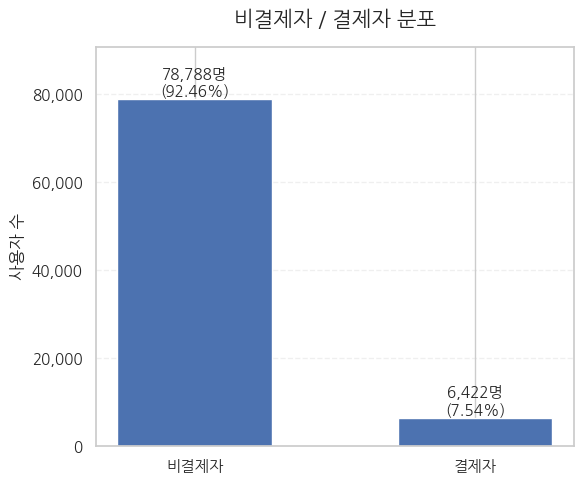

In [ ]:
# 그래프

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    ["비결제자", "결제자"],
    [non_subscriber_users, subscriber_users],
    width=0.55
)

for bar, count, rate in zip(
    bars,
    [non_subscriber_users, subscriber_users],
    [non_subscriber_rate, subscriber_rate]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}명\n({rate:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "비결제자 / 결제자 분포",
    fontsize=15,
    pad=15
)

ax.set_ylabel("사용자 수")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"{int(x):,}"
    )
)

ax.set_ylim(
    0,
    max(non_subscriber_users, subscriber_users) * 1.15
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

전체 회원의 92.5%가 비결제자로 확인됨에 따라 비결제자를 하나의 동질적인 집단으로 해석하기보다 서비스 내 주요 행동 경험에 따라 세분화할 필요가 있다고 판단하였다.

## 비결제자 핵심 행동 패턴

비결제자 78,788명을 대상으로 회원가입 이후 주요 서비스 행동 경험 여부 및 이용 수준을 분석하였다.

In [ ]:
# 전처리 완료 데이터의 분석 종료일(미포함)
# 마지막 7일 가입자 검증에 사용
analysis_end_exclusive = pd.Timestamp("2023-12-01")

# 주요 조인 키와 날짜 형식 통일
analysis_population = analysis_population.copy()
analysis_population["user_id"] = (
    analysis_population["user_id"]
    .astype("string")
    .str.strip()
)
analysis_population["signup_at"] = pd.to_datetime(
    analysis_population["signup_at"],
    errors="coerce"
)


# ============================================================
# 1. 모집단 검증
# ============================================================

population = analysis_population.copy()

population["is_subscriber_num"] = pd.to_numeric(
    population["is_subscriber"],
    errors="coerce"
)

total_users = population["user_id"].nunique()

paid_users = population.loc[
    population["is_subscriber_num"] == 1,
    "user_id"
].nunique()

non_paid_users = population.loc[
    population["is_subscriber_num"] == 0,
    "user_id"
].nunique()

print("\n[모집단]")
print(f"전체 회원: {total_users:,}명")
print(f"결제자: {paid_users:,}명")
print(f"비결제자: {non_paid_users:,}명")

if total_users != 85210:
    raise ValueError(
        f"전체 회원이 85,210명이 아닙니다: {total_users:,}명"
    )

if paid_users != 6422:
    raise ValueError(
        f"결제자가 6,422명이 아닙니다: {paid_users:,}명"
    )

if non_paid_users != 78788:
    raise ValueError(
        f"비결제자가 78,788명이 아닙니다: {non_paid_users:,}명"
    )


# ============================================================
# 2. 비결제자 및 가입 시각 준비
# ============================================================

non_payer_population = (
    population.loc[
        population["is_subscriber_num"] == 0,
        ["user_id", "signup_at"]
    ]
    .drop_duplicates(subset="user_id")
    .copy()
)

non_payer_signup = (
    non_payer_population
    .set_index("user_id")["signup_at"]
)

total_non_payers = (
    non_payer_population["user_id"].nunique()
)


# ============================================================
# 3. 비결제자 유효 이벤트 생성 함수
# 비결제자 + 분석 기간 + 회원가입 이후
# ============================================================

def make_valid_non_payer_events(event_df):
    df = event_df.copy()

    # user_id와 날짜 형식 통일
    df["user_id"] = (
        df["user_id"]
        .astype("string")
        .str.strip()
    )

    df["client_event_time"] = pd.to_datetime(
        df["client_event_time"],
        errors="coerce"
    )

    df = df.dropna(
        subset=["user_id", "client_event_time"]
    ).copy()

    # 비결제자 이벤트만 선택
    df = df.loc[
        df["user_id"].isin(
            non_payer_signup.index
        )
    ].copy()

    # 회원가입 완료 시각 연결
    df["signup_at"] = (
        df["user_id"].map(non_payer_signup)
    )

    # 회원가입 완료 이후 이벤트만 유지
    df = df.loc[
        df["client_event_time"]
        >= df["signup_at"]
    ].copy()

    return df


# ============================================================
# 4. 핵심 행동 이벤트 생성
# enter_lesson_page는 is_trial 조건을 적용하지 않음
# ============================================================

behavior_tables = {
    "enter_lesson_page": enter_lesson_page,
    "enter_payment_page": enter_payment_page,
    "enter_content_page": enter_content_page,
    "start_content": start_content,
    "enter_main_page": enter_main_page,
    "complete_lesson": complete_lesson,
    "click_content_page_start_content_button":
        click_content_page_start_content_button,
    "click_lesson_page_related_question_box":
        click_lesson_page_related_question_box,
    "end_content": end_content,
    "click_content_page_more_review_button":
        click_content_page_more_review_button
}

valid_behavior_events = {}

for table_name, event_df in behavior_tables.items():
    valid_behavior_events[table_name] = (
        make_valid_non_payer_events(event_df)
    )


# ============================================================
# 5. 비결제자 핵심 행동표
# ============================================================

behavior_records = []

for table_name in behavior_tables:
    df = valid_behavior_events[table_name]

    event_count = len(df)
    experienced_users = (
        df["user_id"].nunique()
    )

    experience_rate = (
        experienced_users
        / total_non_payers
        * 100
    )

    experienced_average = (
        event_count / experienced_users
        if experienced_users > 0
        else 0
    )

    behavior_records.append({
        "이벤트": table_name,
        "경험률(%)": experience_rate,
        "발생(건)": event_count,
        "경험자(명)": experienced_users,
        "1인당 횟수": experienced_average
    })

behavior_summary = (
    pd.DataFrame(behavior_records)
    .sort_values(
        "경험률(%)",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n[비결제자 핵심 행동표]")

display(
    behavior_summary.style
    .hide(axis="index")
    .format({
        "경험률(%)": "{:.2f}",
        "발생(건)": "{:,.0f}",
        "경험자(명)": "{:,.0f}",
        "1인당 횟수": "{:.2f}"
    })
)

enter_content_result = behavior_summary.loc[
    behavior_summary["이벤트"]
    == "enter_content_page"
].iloc[0]

if enter_content_result["발생(건)"] != 108489:
    raise ValueError(
        "enter_content_page가 108,489건이 아닙니다."
    )

if enter_content_result["경험자(명)"] != 23842:
    raise ValueError(
        "enter_content_page 경험자가 23,842명이 아닙니다."
    )



[모집단]
전체 회원: 85,210명
결제자: 6,422명
비결제자: 78,788명

[비결제자 핵심 행동표]


이벤트,경험률(%),발생(건),경험자(명),1인당 횟수
enter_lesson_page,61.82,"1,491,941","48,707",30.63
enter_payment_page,51.75,"74,581","40,776",1.83
enter_content_page,30.26,"108,489","23,842",4.55
start_content,27.27,"29,690","21,484",1.38
enter_main_page,20.76,"41,525","16,355",2.54
complete_lesson,19.05,"336,734","15,007",22.44
click_content_page_start_content_button,10.91,"15,619","8,592",1.82
click_lesson_page_related_question_box,9.29,"42,827","7,321",5.85
end_content,5.32,"8,472","4,188",2.02
click_content_page_more_review_button,0.49,465,390,1.19


비결제자의 상당수가 핵심 서비스 행동까지 도달 했다.

### 비결제자 행동 조합 정의

비 결제자의 행동 수준을 구체적으로 파악하기 위해 콘텐츠 페이지, 레슨 페이지, 결제 페이지 진입 여부를 O/X 형태로 구분 하였다.
세 가지 행동의 조합을 통해 총 8개 Case를 구성하였다.


In [ ]:
# ============================================================
# 1. 세 가지 핵심 행동 경험 사용자
# ============================================================

content_users = set(
    valid_behavior_events[
        "enter_content_page"
    ]["user_id"].unique()
)

lesson_users = set(
    valid_behavior_events[
        "enter_lesson_page"
    ]["user_id"].unique()
)

payment_page_users = set(
    valid_behavior_events[
        "enter_payment_page"
    ]["user_id"].unique()
)


# ============================================================
# 2. 8개 Case 독립 재산출
# ============================================================

non_payer_segments = (
    non_payer_population.copy()
)

non_payer_segments[
    "has_content_page"
] = (
    non_payer_segments["user_id"]
    .isin(content_users)
    .astype(int)
)

non_payer_segments[
    "has_lesson_page"
] = (
    non_payer_segments["user_id"]
    .isin(lesson_users)
    .astype(int)
)

non_payer_segments[
    "has_payment_page"
] = (
    non_payer_segments["user_id"]
    .isin(payment_page_users)
    .astype(int)
)

case_map = {
    (0, 0, 0): "Case 1",
    (1, 0, 0): "Case 2",
    (0, 1, 0): "Case 3",
    (1, 1, 0): "Case 4",
    (0, 0, 1): "Case 5",
    (1, 0, 1): "Case 6",
    (0, 1, 1): "Case 7",
    (1, 1, 1): "Case 8"
}

non_payer_segments["Case"] = [
    case_map[
        (
            content_flag,
            lesson_flag,
            payment_flag
        )
    ]
    for content_flag, lesson_flag, payment_flag
    in zip(
        non_payer_segments[
            "has_content_page"
        ],
        non_payer_segments[
            "has_lesson_page"
        ],
        non_payer_segments[
            "has_payment_page"
        ]
    )
]

segment_map = {
    "Case 1": "미활성화 층",
    "Case 2": "콘텐츠 탐색층",
    "Case 3": "학습 경험층",
    "Case 4": "학습 경험층",
    "Case 5": "결제 탐색층",
    "Case 6": "결제 탐색층",
    "Case 7": "결제 고민층",
    "Case 8": "결제 고민층"
}

non_payer_segments["세그먼트"] = (
    non_payer_segments["Case"]
    .map(segment_map)
)


# ============================================================
# 3. Case 8개 결과표
# 회원가입 / 콘텐츠 페이지 / 레슨 페이지 / 결제 페이지 OX 표시
# ============================================================

case_order = [
    "Case 1",
    "Case 2",
    "Case 3",
    "Case 4",
    "Case 5",
    "Case 6",
    "Case 7",
    "Case 8"
]

case_count = (
    non_payer_segments["Case"]
    .value_counts()
    .reindex(case_order, fill_value=0)
)

case_summary = pd.DataFrame({
    "구분": case_order,
    "회원 가입": ["O"] * 8,
    "콘텐츠 페이지": [
        "X", "O", "X", "O",
        "X", "O", "X", "O"
    ],
    "레슨 페이지": [
        "X", "X", "O", "O",
        "X", "X", "O", "O"
    ],
    "결제 페이지": [
        "X", "X", "X", "X",
        "O", "O", "O", "O"
    ],
    "유저 수": [
        int(case_count[case_name])
        for case_name in case_order
    ]
})

case_summary["비중"] = (
    case_summary["유저 수"]
    / total_non_payers
    * 100
)

print("\n[Case 8개 분류표]")

display(
    case_summary.style
    .hide(axis="index")
    .format({
        "유저 수": "{:,.0f}",
        "비중": "{:.2f}%"
    })
)

case_total_users = int(case_summary["유저 수"].sum())

print(
    "Case 분류 전체 사용자 수:",
    f"{case_total_users:,}명"
)

if case_total_users != total_non_payers:
    raise ValueError(
        "Case별 사용자 수 합계와 전체 비결제자 수가 "
        "일치하지 않습니다."
    )


[Case 8개 분류표]


구분,회원 가입,콘텐츠 페이지,레슨 페이지,결제 페이지,유저 수,비중
Case 1,O,X,X,X,"9,903",12.57%
Case 2,O,O,X,X,"1,511",1.92%
Case 3,O,X,O,X,"20,340",25.82%
Case 4,O,O,O,X,"6,258",7.94%
Case 5,O,X,X,O,"14,537",18.45%
Case 6,O,O,X,O,"4,130",5.24%
Case 7,O,X,O,O,"10,166",12.90%
Case 8,O,O,O,O,"11,943",15.16%


Case 분류 전체 사용자 수: 78,788명


행동 조합을 살펴보면 콘텐츠 페이지 진입 없이 레슨이나 결제 페이지에 진입한 사용자가 상당수 존재한다. 이는 실제 사용자 여정이 ‘콘텐츠 탐색 → 레슨 이용 → 결제 고려’라는 하나의 순차적 경로로만 형성되지 않음을 보여준다.

### 비결제자 세그먼트 정의

위의 핵심 동에 따라 비결제자 그룹을 아래 5개 상호 배타적 세그먼트로 최종 분류 하고자 한다.

In [ ]:
# ============================================================
# 1. Segment 5개 결과표
# 정의 / 포함 Case / 사용자 수 / 비율 표시
# ============================================================

segment_order = [
    "미활성화 층",
    "콘텐츠 탐색층",
    "학습 경험층",
    "결제 탐색층",
    "결제 고민층"
]

segment_count = (
    non_payer_segments["세그먼트"]
    .value_counts()
    .reindex(segment_order, fill_value=0)
)

segment_summary = pd.DataFrame({
    "분류": segment_order,
    "정의": [
        "회원 가입 진입 O / 콘텐츠, 레슨, 결제 진입 X",
        "콘텐츠 진입 O / 레슨, 결제 진입 X",
        "레슨 진입 O / 결제 페이지 진입 X",
        "결제 페이지 진입 O / 레슨 진입 X",
        "레슨, 결제 페이지 모두 진입 O"
    ],
    "포함 Case": [
        "Case 1",
        "Case 2",
        "Case 3, Case 4",
        "Case 5, Case 6",
        "Case 7, Case 8"
    ],
    "유저 수": [
        int(segment_count[segment_name])
        for segment_name in segment_order
    ]
})

segment_summary["비율"] = (
    segment_summary["유저 수"]
    / total_non_payers
    * 100
)

print("\n[Segment 5개 분류표]")

display(
    segment_summary.style
    .hide(axis="index")
    .format({
        "유저 수": "{:,.0f}",
        "비율": "{:.1f}%"
    })
)

segment_total_users = int(segment_summary["유저 수"].sum())

print(
    "Segment 분류 전체 사용자 수:",
    f"{segment_total_users:,}명"
)

if segment_total_users != total_non_payers:
    raise ValueError(
        "Segment별 사용자 수 합계와 전체 비결제자 수가 "
        "일치하지 않습니다."
    )

expected_segment_counts = {
    "미활성화 층": 9903,
    "콘텐츠 탐색층": 1511,
    "학습 경험층": 26598,
    "결제 탐색층": 18667,
    "결제 고민층": 22109
}

for segment_name, expected_count in expected_segment_counts.items():
    actual_count = int(
        segment_summary.loc[
            segment_summary["분류"] == segment_name,
            "유저 수"
        ].iloc[0]
    )

    if actual_count != expected_count:
        raise ValueError(
            f"{segment_name}: "
            f"예상 {expected_count:,}명, "
            f"현재 {actual_count:,}명"
        )


[Segment 5개 분류표]


분류,정의,포함 Case,유저 수,비율
미활성화 층,"회원 가입 진입 O / 콘텐츠, 레슨, 결제 진입 X",Case 1,"9,903",12.6%
콘텐츠 탐색층,"콘텐츠 진입 O / 레슨, 결제 진입 X",Case 2,"1,511",1.9%
학습 경험층,레슨 진입 O / 결제 페이지 진입 X,"Case 3, Case 4","26,598",33.8%
결제 탐색층,결제 페이지 진입 O / 레슨 진입 X,"Case 5, Case 6","18,667",23.7%
결제 고민층,"레슨, 결제 페이지 모두 진입 O","Case 7, Case 8","22,109",28.1%


Segment 분류 전체 사용자 수: 78,788명


# 세그먼트별 행동 특성 분석

## 미활성화층

In [ ]:
# --------------------------------------------------
# 미활성화층 행동 특성표 산출
# --------------------------------------------------

inactive_behavior_tables = {
    "메인 진입": enter_main_page,
    "콘텐츠 시작": start_content,
    "레슨 완료": complete_lesson,
    "콘텐츠 완료": end_content,
    "질문 클릭": click_lesson_page_related_question_box,
    "수강 버튼 클릭": click_content_page_start_content_button
}

inactive_detail_records = []

inactive_users = non_payer_segments.loc[
    non_payer_segments["Case"] == "Case 1",
    "user_id"
].unique()

total_inactive_users = len(inactive_users)

print(f"미활성화층 사용자 수: {total_inactive_users:,}명")

for behavior_name, df in inactive_behavior_tables.items():

    # 미활성화층 사용자만 추출
    event_df = df[
        df["user_id"].isin(inactive_users)
    ].copy()

    # 회원가입 시각 연결
    event_df["signup_at"] = (
        event_df["user_id"]
        .map(non_payer_signup)
    )

    # 회원가입 이후 행동만 유지
    event_df = event_df[
        event_df["client_event_time"]
        >= event_df["signup_at"]
    ].copy()

    event_count = len(event_df)
    experienced_users = event_df["user_id"].nunique()

    experience_rate = (
        experienced_users
        / total_inactive_users
        * 100
    )

    average_count = (
        event_count / experienced_users
        if experienced_users > 0
        else 0
    )

    # 사용자별 첫 행동
    first_action = (
        event_df
        .groupby("user_id", as_index=False)
        .agg(
            first_action_at=(
                "client_event_time",
                "min"
            ),
            signup_at=(
                "signup_at",
                "first"
            )
        )
    )

    # 회원가입 이후 첫 행동까지 걸린 일수
    first_action["days_to_first_action"] = (
        first_action["first_action_at"]
        - first_action["signup_at"]
    ).dt.total_seconds() / (24 * 60 * 60)

    median_days = (
        first_action["days_to_first_action"].median()
        if experienced_users > 0
        else 0
    )

    average_days = (
        first_action["days_to_first_action"].mean()
        if experienced_users > 0
        else 0
    )

    inactive_detail_records.append({
        "행동": behavior_name,
        "경험률(%)": experience_rate,
        "발생(건)": event_count,
        "경험자(명)": experienced_users,
        "1인당 횟수": average_count,
        "첫 행동 중앙값(일)": median_days,
        "첫 행동 평균(일)": average_days
    })

inactive_detail_summary = pd.DataFrame(
    inactive_detail_records
)

display(
    inactive_detail_summary.style.format({
        "경험률(%)": "{:.2f}%",
        "발생(건)": "{:,.0f}",
        "경험자(명)": "{:,.0f}",
        "1인당 횟수": "{:.2f}",
        "첫 행동 중앙값(일)": "{:.2f}",
        "첫 행동 평균(일)": "{:.2f}"
    })
)

미활성화층 사용자 수: 9,903명


,행동,경험률(%),발생(건),경험자(명),1인당 횟수,첫 행동 중앙값(일),첫 행동 평균(일)
0,메인 진입,16.49%,"3,192","1,633",1.95,0.00,1.21
1,콘텐츠 시작,4.66%,612,461,1.33,0.00,4.30
2,레슨 완료,2.86%,"5,067",283,17.90,0.00,4.14
3,콘텐츠 완료,0.69%,141,68,2.07,0.92,6.81
4,질문 클릭,0.06%,8,6,1.33,0.01,0.02
5,수강 버튼 클릭,0.05%,5,5,1.00,0.00,0.00


## 콘텐츠 탐색층

In [ ]:
# ============================================================
# 1. enter_content_page 중복 정리
# user_id + client_event_time 기준
# ============================================================

enter_content_before = len(
    enter_content_page
)

enter_content_page = (
    enter_content_page
    .drop_duplicates(
        subset=["user_id", "client_event_time"],
        keep="first"
    )
    .reset_index(drop=True)
)

enter_content_after = len(
    enter_content_page
)

removed_enter_content_duplicates = (
    enter_content_before - enter_content_after
)


print(
    "enter_content_page 제거 중복:",
    f"{removed_enter_content_duplicates:,}건"
)

remaining_duplicates = (
    enter_content_page
    .duplicated(
        subset=["user_id", "client_event_time"]
    )
    .sum()
)

if remaining_duplicates != 0:
    raise ValueError(
        "enter_content_page 중복이 남아 있습니다."
    )

# ============================================================
# 2. 콘텐츠 탐색층 사용자
# ============================================================

segment2_users = set(
    non_payer_segments.loc[
        non_payer_segments["세그먼트"]
        == "콘텐츠 탐색층",
        "user_id"
    ]
)

segment2_population = (
    non_payer_segments.loc[
        non_payer_segments["세그먼트"]
        == "콘텐츠 탐색층",
        ["user_id", "signup_at"]
    ]
    .copy()
)

total_segment2_users = len(
    segment2_users
)

print("\n[콘텐츠 탐색층]")
print(
    "전체 사용자:",
    f"{total_segment2_users:,}명"
)

if total_segment2_users != 1511:
    raise ValueError(
        "콘텐츠 탐색층이 1,511명이 아닙니다."
    )


# ============================================================
# 3. 콘텐츠 탐색층 마지막 7일 가입자
# ============================================================

last_7_days_start = (
    analysis_end_exclusive
    - pd.Timedelta(days=7)
)

segment2_population[
    "마지막_7일_가입자"
] = (
    (
        segment2_population["signup_at"]
        >= last_7_days_start
    )
    & (
        segment2_population["signup_at"]
        < analysis_end_exclusive
    )
)

segment2_last7_count = int(
    segment2_population[
        "마지막_7일_가입자"
    ].sum()
)

segment2_last7_rate = (
    segment2_last7_count
    / total_segment2_users
    * 100
)

segment2_observation_summary = pd.DataFrame({
    "검증 지표": [
        "세그먼트 2 전체 인원",
        "마지막 7일 가입자",
        "마지막 7일 가입자 비율",
        "최종 분석 대상"
    ],
    "결과": [
        f"{total_segment2_users:,}명",
        f"{segment2_last7_count:,}명",
        f"{segment2_last7_rate:.2f}%",
        f"{total_segment2_users:,}명"
    ]
})

print("\n[관찰기간 검증]")

display(
    segment2_observation_summary.style
    .hide(axis="index")
)

if segment2_last7_count != 19:
    raise ValueError(
        "콘텐츠 탐색층의 마지막 7일 가입자가 19명이 아닙니다."
    )


# ============================================================
# 4. 콘텐츠 탐색층의 enter_content_page 이벤트
# 반드시 중복 제거된 이벤트 사용
# ============================================================

segment2_content_events = (
    valid_behavior_events[
        "enter_content_page"
    ]
    .loc[
        lambda df: df["user_id"].isin(
            segment2_users
        )
    ]
    .copy()
)

print(
    "\n콘텐츠 탐색층 콘텐츠 페이지 이벤트:",
    f"{len(segment2_content_events):,}건"
)


# ============================================================
# 5. 콘텐츠 탐색층 사용자별 지표
# ============================================================

segment2_user_metrics = (
    segment2_content_events
    .groupby("user_id")
    .agg(
        콘텐츠_진입_횟수=(
            "client_event_time",
            "size"
        ),
        고유_콘텐츠_수=(
            "content.id",
            "nunique"
        ),
        탐색_활동일_수=(
            "client_event_time",
            lambda values: (
                values.dt.normalize().nunique()
            )
        ),
        첫_탐색_시각=(
            "client_event_time",
            "min"
        ),
        마지막_탐색_시각=(
            "client_event_time",
            "max"
        ),
        가입_시각=(
            "signup_at",
            "first"
        )
    )
    .reset_index()
)

segment2_user_metrics[
    "가입_후_첫_콘텐츠_진입_시간"
] = (
    (
        segment2_user_metrics[
            "첫_탐색_시각"
        ]
        - segment2_user_metrics[
            "가입_시각"
        ]
    )
    .dt.total_seconds()
    / 3600
)

segment2_user_metrics[
    "첫_탐색부터_마지막_탐색까지_일수"
] = (
    (
        segment2_user_metrics[
            "마지막_탐색_시각"
        ]
        - segment2_user_metrics[
            "첫_탐색_시각"
        ]
    )
    .dt.total_seconds()
    / (24 * 60 * 60)
)

if len(segment2_user_metrics) != 1511:
    raise ValueError(
        "콘텐츠 탐색층 사용자별 지표가 "
        "1,511명이 아닙니다."
    )


# ============================================================
# 6. 콘텐츠 탐색 활동일 유형
# ============================================================

segment2_user_metrics[
    "탐색 유형"
] = (
    segment2_user_metrics[
        "탐색_활동일_수"
    ]
    .apply(
        lambda value: (
            "하루만 콘텐츠 탐색"
            if value == 1
            else "2일 이상 콘텐츠 탐색"
        )
    )
)

exploration_type_summary = (
    segment2_user_metrics[
        "탐색 유형"
    ]
    .value_counts()
    .reindex([
        "하루만 콘텐츠 탐색",
        "2일 이상 콘텐츠 탐색"
    ])
    .rename_axis("탐색 유형")
    .reset_index(name="사용자 수")
)

exploration_type_summary["비율(%)"] = (
    exploration_type_summary["사용자 수"]
    / total_segment2_users
    * 100
)

print("\n[콘텐츠 탐색 활동일]")

display(
    exploration_type_summary.style
    .hide(axis="index")
    .format({
        "사용자 수": "{:,.0f}",
        "비율(%)": "{:.2f}"
    })
)


# ============================================================
# 7. 고유 콘텐츠 수 분포
# ============================================================

unique_content_summary = (
    segment2_user_metrics[
        "고유_콘텐츠_수"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("고유 콘텐츠 수")
    .reset_index(name="사용자 수")
)

unique_content_summary["사용자 비율(%)"] = (
    unique_content_summary["사용자 수"]
    / total_segment2_users
    * 100
)

print("\n[고유 콘텐츠 수 분포]")

display(
    unique_content_summary.style
    .hide(axis="index")
    .format({
        "사용자 수": "{:,.0f}",
        "사용자 비율(%)": "{:.2f}"
    })
)


# ============================================================
# 8. 콘텐츠 탐색층 주요 지표 요약
# ============================================================

metric_columns = {
    "콘텐츠 페이지 진입 횟수":
        "콘텐츠_진입_횟수",

    "고유 콘텐츠 수":
        "고유_콘텐츠_수",

    "콘텐츠 탐색 활동일 수":
        "탐색_활동일_수",

    "가입 후 첫 콘텐츠 진입 시간(시간)":
        "가입_후_첫_콘텐츠_진입_시간",

    "첫 탐색부터 마지막 탐색까지 일수":
        "첫_탐색부터_마지막_탐색까지_일수"
}

segment2_metric_records = []

for metric_name, column_name in (
    metric_columns.items()
):
    values = (
        segment2_user_metrics[
            column_name
        ].dropna()
    )

    segment2_metric_records.append({
        "분석 지표": metric_name,
        "사용자 수": len(values),
        "평균": values.mean(),
        "25%": values.quantile(0.25),
        "중앙값": values.median(),
        "75%": values.quantile(0.75),
        "90%": values.quantile(0.90),
        "최대": values.max()
    })

segment2_metric_summary = pd.DataFrame(
    segment2_metric_records
)

print("\n[콘텐츠 탐색층 주요 지표]")

display(
    segment2_metric_summary.style
    .hide(axis="index")
    .format({
        "사용자 수": "{:,.0f}",
        "평균": "{:.2f}",
        "25%": "{:.2f}",
        "중앙값": "{:.2f}",
        "75%": "{:.2f}",
        "90%": "{:.2f}",
        "최대": "{:.2f}"
    })
)

print("\n모든 분석이 정상적으로 완료됐습니다.")

enter_content_page 제거 중복: 0건

[콘텐츠 탐색층]
전체 사용자: 1,511명

[관찰기간 검증]


검증 지표,결과
세그먼트 2 전체 인원,"1,511명"
마지막 7일 가입자,19명
마지막 7일 가입자 비율,1.26%
최종 분석 대상,"1,511명"



콘텐츠 탐색층 콘텐츠 페이지 이벤트: 2,591건

[콘텐츠 탐색 활동일]


탐색 유형,사용자 수,비율(%)
하루만 콘텐츠 탐색,"1,429",94.57
2일 이상 콘텐츠 탐색,82,5.43



[고유 콘텐츠 수 분포]


고유 콘텐츠 수,사용자 수,사용자 비율(%)
1,"1,228",81.27
2,183,12.11
3,45,2.98
4,25,1.65
5,8,0.53
6,7,0.46
7,6,0.40
8,3,0.20
9,2,0.13
10,2,0.13



[콘텐츠 탐색층 주요 지표]


분석 지표,사용자 수,평균,25%,중앙값,75%,90%,최대
콘텐츠 페이지 진입 횟수,"1,511",1.71,1.00,1.00,2.00,3.00,36.00
고유 콘텐츠 수,"1,511",1.35,1.00,1.00,1.00,2.00,12.00
콘텐츠 탐색 활동일 수,"1,511",1.10,1.00,1.00,1.00,1.00,30.00
가입 후 첫 콘텐츠 진입 시간(시간),"1,511",75.49,0.00,0.01,0.03,5.53,7048.72
첫 탐색부터 마지막 탐색까지 일수,"1,511",1.47,0.00,0.00,0.00,0.00,185.50



모든 분석이 정상적으로 완료됐습니다.


## 학습경험층

In [ ]:
# 핵십 가치 분석 모집단 생성
# 1. analysis_population 정리

population = analysis_population.copy()

population = (
    population
    .dropna(subset=["user_id"])
    .drop_duplicates(subset=["user_id"])
    .reset_index(drop=True)
)

population["signup_time"] = pd.to_datetime(
    population["signup_at"],
    errors="coerce"
)

population["is_subscriber"] = pd.to_numeric(
    population["is_subscriber"],
    errors="coerce"
)

population["segment"] = (
    population["segment"]
    .astype(str)
    .str.upper()
)

# ============================================================
# 2. S3 학습 경험층
# ============================================================

learning_users = population[
    (population["is_subscriber"] == 0)
    &
    (population["segment"] == "S3")
][["user_id","signup_time"]].copy()

learning_users["group"] = "학습 경험층"

# ============================================================
# 3. S5 고관여 미결제층
# ============================================================

high_engagement_users = population[
    (population["is_subscriber"] == 0)
    &
    (population["segment"] == "S5")
][["user_id","signup_time"]].copy()

high_engagement_users["group"] = "고관여 미결제층"

# ============================================================
# 4. 실제 결제자
# ============================================================

subscriber_users = population[
    population["is_subscriber"] == 1
][["user_id","signup_time"]].copy()

subscriber_users["group"] = "실제 결제자"

# ============================================================
# 5. 결과 확인
# ============================================================

print("="*60)
print("핵심가치 분석 모집단")
print("="*60)

print(
    f"학습 경험층 : {learning_users['user_id'].nunique():,}명"
)

print(
    f"고관여 미결제층 : {high_engagement_users['user_id'].nunique():,}명"
)

print(
    f"실제 결제자 : {subscriber_users['user_id'].nunique():,}명"
)

핵심가치 분석 모집단
학습 경험층 : 26,598명
고관여 미결제층 : 22,109명
실제 결제자 : 6,422명


### 핵심 가치1. 콘텐츠 탐색 경험



In [ ]:
# ============================================================
# 핵심가치 1. 콘텐츠 탐색 여부
# ============================================================

# 분석 모집단 (S3 + S5)
core_users = pd.concat(
    [learning_users, high_engagement_users],
    ignore_index=True
)

# 콘텐츠 페이지 이벤트
content_event = enter_content_page.copy()

content_event["client_event_time"] = pd.to_datetime(
    content_event["client_event_time"],
    errors="coerce"
)

# 가입 이후 이벤트만 인정
content_event = (
    content_event
    .merge(
        core_users[["user_id", "signup_time"]],
        on="user_id",
        how="inner"
    )
)

content_event = content_event[
    content_event["client_event_time"]
    >= content_event["signup_time"]
]

# 콘텐츠 방문 사용자
visit_users = set(content_event["user_id"])

# 방문 여부 생성
core_users["콘텐츠 탐색 여부"] = np.where(
    core_users["user_id"].isin(visit_users),
    "방문",
    "미방문"
)

# S5는 결제페이지 진입 집단
core_users["결제페이지 진입"] = np.where(
    core_users["group"] == "고관여 미결제층",
    1,
    0
)

# 결과 집계
content_summary = (
    core_users
    .groupby("콘텐츠 탐색 여부")
    .agg(
        사용자수=("user_id", "nunique"),
        결제페이지_진입자수=("결제페이지 진입", "sum")
    )
    .reset_index()
)

content_summary["결제페이지_미진입자수"] = (
    content_summary["사용자수"]
    - content_summary["결제페이지_진입자수"]
)

content_summary["결제페이지_진입률(%)"] = (
    content_summary["결제페이지_진입자수"]
    / content_summary["사용자수"]
    * 100
).round(2)

display(content_summary)

,콘텐츠 탐색 여부,사용자수,결제페이지_진입자수,결제페이지_미진입자수,결제페이지_진입률(%)
0,미방문,30506,10166,20340,33.32
1,방문,18201,11943,6258,65.62


### 핵심 가치1-2. 콘텐츠 탐색 깊이

In [ ]:
# ============================================================
# 핵심가치 1-2. 콘텐츠 탐색 깊이
# ============================================================

# 분석 모집단 (S3 + S5)
core_users = pd.concat(
    [learning_users, high_engagement_users],
    ignore_index=True
)

# 콘텐츠 페이지 이벤트
content_event = enter_content_page[
    ["user_id", "client_event_time"]
].copy()

content_event["client_event_time"] = pd.to_datetime(
    content_event["client_event_time"],
    errors="coerce"
)

# 가입 이후 행동만 인정
content_event = (
    content_event
    .merge(
        core_users[
            ["user_id", "signup_time"]
        ],
        on="user_id",
        how="inner"
    )
)

content_event = content_event[
    content_event["client_event_time"]
    >= content_event["signup_time"]
]

# 사용자별 콘텐츠 페이지 방문 횟수
content_count = (
    content_event
    .groupby("user_id")
    .size()
    .reset_index(name="방문횟수")
)

# 모집단과 병합
core_users = (
    core_users
    .merge(
        content_count,
        on="user_id",
        how="left"
    )
)

core_users["방문횟수"] = (
    core_users["방문횟수"]
    .fillna(0)
    .astype(int)
)

# 콘텐츠 탐색 깊이 구간
core_users["콘텐츠 탐색 깊이"] = pd.cut(
    core_users["방문횟수"],
    bins=[-1, 0, 2, 5, np.inf],
    labels=[
        "0회",
        "1~2회",
        "3~5회",
        "6회 이상"
    ]
)

# 결제페이지 진입 여부 (S5)
core_users["결제페이지 진입"] = np.where(
    core_users["group"] == "고관여 미결제층",
    1,
    0
)

# 결과
content_depth_summary = (
    core_users
    .groupby(
        "콘텐츠 탐색 깊이",
        observed=False
    )
    .agg(
        사용자수=("user_id", "nunique"),
        결제페이지_진입자수=("결제페이지 진입", "sum")
    )
    .reset_index()
)

content_depth_summary["결제페이지_미진입자수"] = (
    content_depth_summary["사용자수"]
    - content_depth_summary["결제페이지_진입자수"]
)

content_depth_summary["결제페이지_진입률(%)"] = (
    content_depth_summary["결제페이지_진입자수"]
    / content_depth_summary["사용자수"]
    * 100
).round(2)

display(content_depth_summary)

,콘텐츠 탐색 깊이,사용자수,결제페이지_진입자수,결제페이지_미진입자수,결제페이지_진입률(%)
0,0회,30506,10166,20340,33.32
1,1~2회,10290,5880,4410,57.14
2,3~5회,4166,3162,1004,75.90
3,6회 이상,3745,2901,844,77.46


### 핵심 가치2. 체험 학습 몰입도

In [ ]:
# ============================================================
# 핵심가치 2. 체험 학습 몰입도
# ============================================================

# 분석 모집단 (S3 + S5)
core_users = pd.concat(
    [learning_users, high_engagement_users],
    ignore_index=True
)

# ------------------------------------------------------------
# enter_lesson_page
# ------------------------------------------------------------

lesson_enter = enter_lesson_page[
    [
        "user_id",
        "content.id",
        "lesson.id",
        "client_event_time"
    ]
].copy()

lesson_enter["client_event_time"] = pd.to_datetime(
    lesson_enter["client_event_time"],
    errors="coerce"
)

lesson_enter = (
    lesson_enter
    .merge(
        core_users[["user_id", "signup_time"]],
        on="user_id",
        how="inner"
    )
)

# 가입 이후 레슨 진입만 인정
lesson_enter = lesson_enter[
    lesson_enter["client_event_time"]
    >= lesson_enter["signup_time"]
]

# 사용자·콘텐츠·레슨별 최초 진입
lesson_enter = (
    lesson_enter
    .groupby(
        ["user_id", "content.id", "lesson.id"],
        as_index=False
    )
    .agg(
        enter_time=("client_event_time", "min")
    )
)

# ------------------------------------------------------------
# complete_lesson
# ------------------------------------------------------------

lesson_complete = complete_lesson[
    [
        "user_id",
        "content.id",
        "lesson.id",
        "client_event_time"
    ]
].copy()

lesson_complete["client_event_time"] = pd.to_datetime(
    lesson_complete["client_event_time"],
    errors="coerce"
)

# ------------------------------------------------------------
# 동일 user_id + content.id + lesson.id 매칭
# ------------------------------------------------------------

lesson_match = (
    lesson_enter
    .merge(
        lesson_complete,
        on=[
            "user_id",
            "content.id",
            "lesson.id"
        ],
        how="left"
    )
)

# 레슨 진입 이후 완료만 인정
lesson_match = lesson_match[
    lesson_match["client_event_time"]
    >= lesson_match["enter_time"]
]

# 완료 사용자
complete_users = set(lesson_match["user_id"])

# ------------------------------------------------------------
# 체험 학습 몰입도
# ------------------------------------------------------------

core_users["체험 학습 몰입도"] = np.where(
    core_users["user_id"].isin(complete_users),
    "완료",
    "미완료"
)

# 결제페이지 진입 여부
core_users["결제페이지 진입"] = np.where(
    core_users["group"] == "고관여 미결제층",
    1,
    0
)

# ------------------------------------------------------------
# 결과
# ------------------------------------------------------------

experience_learning_summary = (
    core_users
    .groupby("체험 학습 몰입도")
    .agg(
        사용자수=("user_id", "nunique"),
        결제페이지_진입자수=("결제페이지 진입", "sum")
    )
    .reset_index()
)

experience_learning_summary["결제페이지_미진입자수"] = (
    experience_learning_summary["사용자수"]
    - experience_learning_summary["결제페이지_진입자수"]
)

experience_learning_summary["결제페이지_진입률(%)"] = (
    experience_learning_summary["결제페이지_진입자수"]
    / experience_learning_summary["사용자수"]
    * 100
).round(2)

display(experience_learning_summary)

,체험 학습 몰입도,사용자수,결제페이지_진입자수,결제페이지_미진입자수,결제페이지_진입률(%)
0,미완료,34180,13754,20426,40.24
1,완료,14527,8355,6172,57.51


### 핵심 가치3. 학습 참여도



In [ ]:
# ============================================================
# 핵심가치 3. 학습 참여도
# ============================================================

# 분석 모집단 (S3 + S5)
core_users = pd.concat(
    [learning_users, high_engagement_users],
    ignore_index=True
)

# ------------------------------------------------------------
# 질문 기능 클릭 이벤트
# ------------------------------------------------------------

question_event = click_lesson_page_related_question_box[
    [
        "user_id",
        "client_event_time"
    ]
].copy()

question_event["client_event_time"] = pd.to_datetime(
    question_event["client_event_time"],
    errors="coerce"
)

# 가입 이후 행동만 인정
question_event = (
    question_event
    .merge(
        core_users[
            ["user_id", "signup_time"]
        ],
        on="user_id",
        how="inner"
    )
)

question_event = question_event[
    question_event["client_event_time"]
    >= question_event["signup_time"]
]

# 질문 기능 이용 사용자
question_users = set(
    question_event["user_id"]
)

# ------------------------------------------------------------
# 학습 참여도 생성
# ------------------------------------------------------------

core_users["질문기능_이용여부"] = np.where(
    core_users["user_id"].isin(question_users),
    "이용",
    "미이용"
)

# 결제페이지 진입 여부
core_users["결제페이지 진입"] = np.where(
    core_users["group"] == "고관여 미결제층",
    1,
    0
)

# ------------------------------------------------------------
# 결과
# ------------------------------------------------------------

learning_participation_summary = (
    core_users
    .groupby("질문기능_이용여부")
    .agg(
        사용자수=("user_id", "nunique"),
        결제페이지_진입자수=("결제페이지 진입", "sum")
    )
    .reset_index()
)

learning_participation_summary["결제페이지_미진입자수"] = (
    learning_participation_summary["사용자수"]
    - learning_participation_summary["결제페이지_진입자수"]
)

learning_participation_summary["결제페이지_진입률(%)"] = (
    learning_participation_summary["결제페이지_진입자수"]
    / learning_participation_summary["사용자수"]
    * 100
).round(2)

display(learning_participation_summary)

,질문기능_이용여부,사용자수,결제페이지_진입자수,결제페이지_미진입자수,결제페이지_진입률(%)
0,미이용,41399,17564,23835,42.43
1,이용,7308,4545,2763,62.19


### 핵심 가치4. 리뷰 확인 여부

In [ ]:
# ============================================================
# 핵심가치 4. 리뷰 확인 여부
# ============================================================

# 분석 모집단 (S3 + S5)
core_users = pd.concat(
    [learning_users, high_engagement_users],
    ignore_index=True
)

# ------------------------------------------------------------
# 리뷰 더보기 클릭 이벤트
# ------------------------------------------------------------

review_event = click_content_page_more_review_button[
    [
        "user_id",
        "client_event_time"
    ]
].copy()

review_event["client_event_time"] = pd.to_datetime(
    review_event["client_event_time"],
    errors="coerce"
)

# 가입 이후 행동만 인정
review_event = (
    review_event
    .merge(
        core_users[
            ["user_id", "signup_time"]
        ],
        on="user_id",
        how="inner"
    )
)

review_event = review_event[
    review_event["client_event_time"]
    >= review_event["signup_time"]
]

# 리뷰 확인 사용자
review_users = set(
    review_event["user_id"]
)

# ------------------------------------------------------------
# 리뷰 확인 여부 생성
# ------------------------------------------------------------

core_users["리뷰 확인 여부"] = np.where(
    core_users["user_id"].isin(review_users),
    "확인",
    "미확인"
)

# 결제페이지 진입 여부
core_users["결제페이지 진입"] = np.where(
    core_users["group"] == "고관여 미결제층",
    1,
    0
)

# ------------------------------------------------------------
# 결과
# ------------------------------------------------------------

review_summary = (
    core_users
    .groupby("리뷰 확인 여부")
    .agg(
        사용자수=("user_id", "nunique"),
        결제페이지_진입자수=("결제페이지 진입", "sum")
    )
    .reset_index()
)

review_summary["결제페이지_미진입자수"] = (
    review_summary["사용자수"]
    - review_summary["결제페이지_진입자수"]
)

review_summary["결제페이지_진입률(%)"] = (
    review_summary["결제페이지_진입자수"]
    / review_summary["사용자수"]
    * 100
).round(2)

display(review_summary)

,리뷰 확인 여부,사용자수,결제페이지_진입자수,결제페이지_미진입자수,결제페이지_진입률(%)
0,미확인,48410,21886,26524,45.21
1,확인,297,223,74,75.08


## 결제 탐색층

### 핵심 가설 검증 및 지표 분석

In [ ]:
# ============================================================
# 결제 탐색층(Case 5 + Case 6) 전체 행동 이벤트 분석
# ============================================================

import pandas as pd


# ======================================
# 1. 결제 탐색층 유저 추출
# Case 5 & Case 6
# 결제 진입 O / 레슨 진입 X
# ======================================

target_users = user_segment[
    (user_segment["has_payment"] == True) &
    (user_segment["has_lesson"] == False)
]["user_id"].unique()

print(
    f"✅ 결제 탐색층 타겟 유저 수: "
    f"{len(target_users):,}명"
)


# ======================================
# 2. 가입 시점 준비
# analysis_population의 signup_at 사용
# ======================================

base = analysis_population[
    [
        "user_id",
        "signup_at"
    ]
].copy()

base["signup_time"] = pd.to_datetime(
    base["signup_at"],
    errors="coerce"
)

base = (
    base
    .dropna(
        subset=[
            "user_id",
            "signup_time"
        ]
    )
    .drop_duplicates(
        subset="user_id"
    )
    [
        [
            "user_id",
            "signup_time"
        ]
    ]
)


# ======================================
# 3. 분석할 이벤트 테이블
# 현재 사용 중인 DataFrame만 직접 지정
# ======================================

event_tables = {

    "enter_main_page":
        enter_main_page,

    "enter_signup_page":
        enter_signup_page,

    "enter_content_page":
        enter_content_page,

    "click_content_page_start_content_button":
        click_content_page_start_content_button,

    "click_content_page_more_review_button":
        click_content_page_more_review_button,

    "enter_payment_page":
        enter_payment_page,

    "complete_subscription":
        complete_subscription,

    "renew_subscription":
        renew_subscription,

    "resubscribe_subscription":
        resubscribe_subscription,

    "start_content":
        start_content,

    "enter_lesson_page":
        enter_lesson_page,

    "complete_lesson":
        complete_lesson,

    "click_lesson_page_related_question_box":
        click_lesson_page_related_question_box,

    "end_content":
        end_content,

    "click_cancel_plan_button":
        click_cancel_plan_button
}


# ======================================
# 4. 전체 이벤트 데이터 통합
# ======================================

event_dfs = []

for event_name, df in event_tables.items():

    # 필요한 컬럼만 가져오기
    temp_df = df[
        [
            "user_id",
            "client_event_time"
        ]
    ].copy()

    # 날짜형 변환
    temp_df["client_event_time"] = pd.to_datetime(
        temp_df["client_event_time"],
        errors="coerce"
    )

    # 결측 제거
    temp_df = temp_df.dropna(
        subset=[
            "user_id",
            "client_event_time"
        ]
    )

    # 이벤트 이름 지정
    temp_df["event_name"] = event_name

    # 동일 이벤트 중복 제거
    temp_df = temp_df.drop_duplicates(
        subset=[
            "user_id",
            "event_name",
            "client_event_time"
        ]
    )

    event_dfs.append(
        temp_df[
            [
                "user_id",
                "event_name",
                "client_event_time"
            ]
        ]
    )


all_events_df = pd.concat(
    event_dfs,
    ignore_index=True
)


# ======================================
# 5. 가입 시각 연결
# ======================================

all_events_df = all_events_df.merge(
    base,
    on="user_id",
    how="inner"
)


# ======================================
# 6. 결제 탐색층 + 가입 이후 행동만 사용
# ======================================

valid_events_df = all_events_df[
    (
        all_events_df["user_id"]
        .isin(target_users)
    )
    &
    (
        all_events_df["client_event_time"]
        >=
        all_events_df["signup_time"]
    )
].copy()


# ======================================
# 7. 전체 행동 이벤트 집계
# ======================================

event_summary = (
    valid_events_df
    .groupby("event_name")
    .agg(

        총_발생_횟수=(
            "user_id",
            "count"
        ),

        경험_유저_수=(
            "user_id",
            "nunique"
        )

    )
    .reset_index()
)


# ======================================
# 8. 행동 경험률 및 평균 횟수
# ======================================

total_target_cnt = len(target_users)

event_summary["유저_침투율(%)"] = (
    event_summary["경험_유저_수"]
    / total_target_cnt
    * 100
).round(2)

event_summary["인당_평균_발생_횟수"] = (
    event_summary["총_발생_횟수"]
    / event_summary["경험_유저_수"]
).round(2)


# ======================================
# 9. 발생 횟수 기준 정렬
# ======================================

event_summary = (
    event_summary
    .sort_values(
        "총_발생_횟수",
        ascending=False
    )
    .reset_index(drop=True)
)


# ======================================
# 10. 결과 출력
# ======================================

pd.set_option(
    "display.max_rows",
    None
)

print(
    f"\n📊 [결제 탐색층 "
    f"({len(target_users):,}명) "
    f"전체 행동 이벤트 집계 결과]"
)

display(event_summary)

NameError: name 'user_segment' is not defined

### 결제 탐색층 vs 실제 결제자 주요 행동 지표 비교

In [ ]:
# ============================================================
# 결제 탐색층 vs 실제 결제자 핵심 행동 비교
# ============================================================

# 가입 이후 이벤트만 추출
def valid_event(df):

    temp = df.copy()

    temp["client_event_time"] = pd.to_datetime(
        temp["client_event_time"],
        errors="coerce"
    )

    temp = temp.merge(
        target_df[["user_id", "signup_time"]],
        on="user_id",
        how="inner"
    )

    return temp[
        temp["client_event_time"] >= temp["signup_time"]
    ]


# -----------------------------
# 이벤트 추출
# -----------------------------
payment = valid_event(enter_payment_page)
main = valid_event(enter_main_page)
content = valid_event(enter_content_page)
review = valid_event(click_content_page_more_review_button)


# -----------------------------
# 결제페이지 진입 횟수
# -----------------------------
pay_cnt = (
    payment
    .groupby("user_id")
    .size()
    .rename("payment_cnt")
)


# -----------------------------
# 사용자 테이블 생성
# -----------------------------
metrics = target_df.copy()

metrics = metrics.merge(
    pay_cnt,
    on="user_id",
    how="left"
)

metrics["payment_cnt"] = (
    metrics["payment_cnt"]
    .fillna(0)
    .astype(int)
)

metrics["main_visit"] = (
    metrics["user_id"]
    .isin(main["user_id"])
)

metrics["content_visit"] = (
    metrics["user_id"]
    .isin(content["user_id"])
)

metrics["review_click"] = (
    metrics["user_id"]
    .isin(review["user_id"])
)


# -----------------------------
# 최종 비교
# -----------------------------
comparison = (
    metrics
    .groupby("비교 그룹")
    .agg(

        사용자수=(
            "user_id",
            "nunique"
        ),

        결제페이지_평균진입횟수=(
            "payment_cnt",
            "mean"
        ),

        결제1회후이탈비율=(
            "payment_cnt",
            lambda x: (x == 1).mean() * 100
        ),

        결제2회이상재방문비율=(
            "payment_cnt",
            lambda x: (x >= 2).mean() * 100
        ),

        메인페이지진입비율=(
            "main_visit",
            lambda x: x.mean() * 100
        ),

        콘텐츠페이지진입비율=(
            "content_visit",
            lambda x: x.mean() * 100
        ),

        리뷰클릭비율=(
            "review_click",
            lambda x: x.mean() * 100
        )

    )
    .round(2)
    .reset_index()
)

comparison.columns = [
    "비교 그룹",
    "사용자 수",
    "결제페이지 평균 진입 횟수",
    "1회만 진입 후 이탈 비율(%)",
    "2회 이상 재방문 비율(%)",
    "메인페이지 진입 비율(%)",
    "콘텐츠페이지 진입 비율(%)",
    "리뷰 클릭 비율(%)"
]

print("===== 결제 탐색층 vs 실제 결제자 핵심 행동 비교 =====")
display(comparison)

===== 결제 탐색층 vs 실제 결제자 핵심 행동 비교 =====


,비교 그룹,사용자 수,결제페이지 평균 진입 횟수,1회만 진입 후 이탈 비율(%),2회 이상 재방문 비율(%),메인페이지 진입 비율(%),콘텐츠페이지 진입 비율(%),리뷰 클릭 비율(%)
0,결제 탐색층,18667,1.52,68.43,31.57,25.71,22.12,0.40
1,실제 결제자,6422,3.60,19.25,71.82,54.31,92.39,6.43


### 결제 탐색층 vs 실제 결제자 심층 행동 지표 비교

In [ ]:
# ============================================================
# 결제 탐색층 vs 실제 결제자 심층 행동 비교
# 모든 행동 집계 = user_id 기준
# ============================================================

import pandas as pd


# ======================================
# 1. 가입 이후 이벤트 추출
# ======================================

def valid_event(df):

    temp = df[
        ["user_id", "client_event_time"]
    ].copy()

    temp["client_event_time"] = pd.to_datetime(
        temp["client_event_time"],
        errors="coerce"
    )

    temp = temp.dropna(
        subset=["user_id", "client_event_time"]
    )

    temp = temp.merge(
        target_df[
            ["user_id", "signup_time"]
        ],
        on="user_id",
        how="inner"
    )

    temp = temp[
        temp["client_event_time"]
        >= temp["signup_time"]
    ].copy()

    return temp


# 필요한 이벤트
valid_payment = valid_event(enter_payment_page)
valid_main = valid_event(enter_main_page)
valid_content = valid_event(enter_content_page)
valid_start = valid_event(start_content)


# ======================================
# 2. 가입 후 첫 결제페이지 진입 시차
# user_id별 최초 결제페이지 진입
# ======================================

first_pay = (
    valid_payment
    .groupby("user_id", as_index=False)
    .agg(
        first_pay_time=("client_event_time", "min")
    )
)

first_pay = first_pay.merge(
    target_df[
        ["user_id", "signup_time"]
    ],
    on="user_id",
    how="left"
)

first_pay["첫결제페이지_진입시차_분"] = (
    first_pay["first_pay_time"]
    - first_pay["signup_time"]
).dt.total_seconds() / 60


# ======================================
# 3. 결제페이지 진입 후 다음 행동까지 시간
# user_id 기준
# ======================================

all_logs = pd.concat(
    [
        valid_payment.assign(event="payment"),
        valid_content.assign(event="content"),
        valid_main.assign(event="main")
    ],
    ignore_index=True
)

all_logs = all_logs.sort_values(
    ["user_id", "client_event_time"]
)

all_logs["next_event_time"] = (
    all_logs
    .groupby("user_id")["client_event_time"]
    .shift(-1)
)

payment_logs = all_logs[
    all_logs["event"] == "payment"
].copy()

payment_logs["체류시간_초"] = (
    payment_logs["next_event_time"]
    - payment_logs["client_event_time"]
).dt.total_seconds()

# 1초 ~ 30분 사이만 인정
payment_dwell = (
    payment_logs[
        payment_logs["체류시간_초"].between(1, 1800)
    ]
    .groupby("user_id")["체류시간_초"]
    .mean()
)


# ======================================
# 4. 콘텐츠 시작 여부
# user_id 기준
# ======================================

start_users = set(
    valid_start["user_id"].unique()
)


# ======================================
# 5. 콘텐츠 페이지 조회 횟수
# user_id별 enter_content_page 발생 횟수
# ======================================

content_count = (
    valid_content
    .groupby("user_id")
    .size()
    .rename("콘텐츠페이지_조회횟수")
)


# ======================================
# 6. 사용자별 지표 병합
# ======================================

user_metrics = target_df.copy()

user_metrics = user_metrics.merge(
    first_pay[
        [
            "user_id",
            "첫결제페이지_진입시차_분"
        ]
    ],
    on="user_id",
    how="left"
)

user_metrics = user_metrics.merge(
    payment_dwell.rename(
        "결제페이지_체류시간_초"
    ),
    on="user_id",
    how="left"
)

user_metrics = user_metrics.merge(
    content_count,
    on="user_id",
    how="left"
)

user_metrics["콘텐츠페이지_조회횟수"] = (
    user_metrics["콘텐츠페이지_조회횟수"]
    .fillna(0)
    .astype(int)
)

user_metrics["콘텐츠_시작여부"] = (
    user_metrics["user_id"]
    .isin(start_users)
)


# ======================================
# 7. 최종 비교
# ======================================

final_deep_comparison = (
    user_metrics
    .groupby("비교 그룹")
    .agg(

        총_유저_수=(
            "user_id",
            "nunique"
        ),

        가입_후_첫결제페이지_진입시차_중앙값_분=(
            "첫결제페이지_진입시차_분",
            "median"
        ),

        결제페이지_평균_체류시간_초=(
            "결제페이지_체류시간_초",
            "mean"
        ),

        콘텐츠_시작_비율=(
            "콘텐츠_시작여부",
            lambda x: x.mean() * 100
        ),

        인당_평균_콘텐츠페이지_조회횟수=(
            "콘텐츠페이지_조회횟수",
            "mean"
        )
    )
    .round(2)
    .reset_index()
)


# ======================================
# 8. 컬럼명 정리
# ======================================

final_deep_comparison.columns = [
    "비교 그룹",
    "총 유저 수",
    "가입 후 첫 결제페이지 진입 시차(중앙값, 분)",
    "결제페이지 평균 체류시간(초)",
    "콘텐츠 시작 비율(%)",
    "인당 평균 콘텐츠페이지 조회 횟수(회)"
]


print(
    "📊 [결제 탐색층 vs 실제 결제자 심층 행동 비교]"
)

display(final_deep_comparison)

📊 [결제 탐색층 vs 실제 결제자 심층 행동 비교]


,비교 그룹,총 유저 수,"가입 후 첫 결제페이지 진입 시차(중앙값, 분)",결제페이지 평균 체류시간(초),콘텐츠 시작 비율(%),인당 평균 콘텐츠페이지 조회 횟수(회)
0,결제 탐색층,18667,0.08,79.75,0.62,0.53
1,실제 결제자,6422,0.80,258.93,95.67,32.88


## 결제 고민층

### 핵심 가설 검증 및 지표 분석


### 결제자와 학습 경험층 비교

### s5 s5_CG 정의

In [ ]:
# =========================================================
# 0. 공통 함수
# =========================================================
def clean_join_key(series):
    return (
        series
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )


# =========================================================
# 1. analysis_population 정리
# =========================================================
analysis_population = analysis_population.copy()

analysis_population["user_id"] = clean_join_key(
    analysis_population["user_id"]
)

analysis_population["is_subscriber"] = pd.to_numeric(
    analysis_population["is_subscriber"],
    errors="coerce"
)

analysis_population = (
    analysis_population
    .dropna(subset=["user_id", "is_subscriber"])
    .drop_duplicates(subset="user_id", keep="first")
    .reset_index(drop=True)
)

# segment 없으면 생성
if "segment" not in analysis_population.columns:
    analysis_population["segment"] = pd.NA

analysis_population["segment"] = (
    analysis_population["segment"]
    .astype("string")
)

# 결제자의 기존 segment 초기화
subscriber_mask = (
    analysis_population["is_subscriber"] == 1
)

analysis_population.loc[
    subscriber_mask,
    "segment"
] = pd.NA


# =========================================================
# 2. 사용자별 최초 complete_signup 시각
# =========================================================
signup = complete_signup[
    ["user_id", "client_event_time"]
].copy()

signup["user_id"] = clean_join_key(
    signup["user_id"]
)

signup["client_event_time"] = pd.to_datetime(
    signup["client_event_time"],
    errors="coerce"
)

signup = signup.dropna(
    subset=["user_id", "client_event_time"]
)

first_signup = (
    signup
    .groupby("user_id", as_index=False)
    ["client_event_time"]
    .min()
    .rename(
        columns={
            "client_event_time": "signup_at"
        }
    )
)


# =========================================================
# 3. 사용자별 최초 complete_subscription 시각
# =========================================================
subscription = complete_subscription[
    ["user_id", "client_event_time"]
].copy()

subscription["user_id"] = clean_join_key(
    subscription["user_id"]
)

subscription["client_event_time"] = pd.to_datetime(
    subscription["client_event_time"],
    errors="coerce"
)

subscription = subscription.dropna(
    subset=["user_id", "client_event_time"]
)

first_subscription = (
    subscription
    .groupby("user_id", as_index=False)
    ["client_event_time"]
    .min()
    .rename(
        columns={
            "client_event_time": "subscription_at"
        }
    )
)


# =========================================================
# 4. 결제자 기준 테이블 생성
# =========================================================
subscriber_base = (
    analysis_population.loc[
        analysis_population["is_subscriber"] == 1,
        ["user_id", "is_subscriber"]
    ]
    .merge(
        first_signup,
        on="user_id",
        how="left"
    )
    .merge(
        first_subscription,
        on="user_id",
        how="left"
    )
)

subscriber_base = subscriber_base.dropna(
    subset=[
        "signup_at",
        "subscription_at"
    ]
)

print("[결제자 기준]")
print(
    f"전체 결제자 수: "
    f"{analysis_population.loc[subscriber_mask, 'user_id'].nunique():,}명"
)

print(
    f"가입·결제 시각 확인 가능 결제자 수: "
    f"{subscriber_base['user_id'].nunique():,}명"
)


# =========================================================
# 5. enter_lesson_page 정리
# =========================================================
lesson = enter_lesson_page[
    [
        "user_id",
        "client_event_time",
        "content.id",
        "lesson.id"
    ]
].copy()

lesson["user_id"] = clean_join_key(
    lesson["user_id"]
)

lesson["content.id"] = clean_join_key(
    lesson["content.id"]
)

lesson["lesson.id"] = clean_join_key(
    lesson["lesson.id"]
)

lesson["client_event_time"] = pd.to_datetime(
    lesson["client_event_time"],
    errors="coerce"
)

lesson = lesson.dropna(
    subset=[
        "user_id",
        "client_event_time",
        "content.id",
        "lesson.id"
    ]
)


# =========================================================
# 6. 결제자의 가입·결제 시각 연결
# =========================================================
lesson = lesson.merge(
    subscriber_base[
        [
            "user_id",
            "signup_at",
            "subscription_at"
        ]
    ],
    on="user_id",
    how="inner"
)


# =========================================================
# 7. 가입 이후 ~ 최초 결제 이전 레슨 기록
# =========================================================
lesson_before_subscription = lesson[
    (
        lesson["client_event_time"]
        >= lesson["signup_at"]
    )
    &
    (
        lesson["client_event_time"]
        < lesson["subscription_at"]
    )
].copy()


# =========================================================
# 8. S5_CG 사용자 선별
# 결제 전 enter_lesson_page 1회 이상
# =========================================================
s5_cg_user_ids = set(
    lesson_before_subscription[
        "user_id"
    ]
    .dropna()
    .unique()
)

print()
print("[S5_CG 선별]")
print(
    f"결제 전 유효한 레슨 기록 수: "
    f"{len(lesson_before_subscription):,}건"
)

print(
    f"S5_CG 사용자 수: "
    f"{len(s5_cg_user_ids):,}명"
)


# =========================================================
# 9. analysis_population에 S5_CG 입력
# =========================================================
analysis_population.loc[
    (
        analysis_population["is_subscriber"] == 1
    )
    &
    (
        analysis_population["user_id"].isin(
            s5_cg_user_ids
        )
    ),
    "segment"
] = "S5_CG"


# =========================================================
# 10. 최종 population 정리
# =========================================================
analysis_population = (
    analysis_population
    .sort_values("user_id")
    .reset_index(drop=True)
)

final_population = analysis_population


# =========================================================
# 11. 최종 검증
# =========================================================
s5_count = (
    final_population.loc[
        final_population["segment"] == "S5",
        "user_id"
    ]
    .nunique()
)

s5_cg_count = (
    final_population.loc[
        final_population["segment"] == "S5_CG",
        "user_id"
    ]
    .nunique()
)

invalid_s5_cg_count = (
    final_population.loc[
        (
            final_population["segment"] == "S5_CG"
        )
        &
        (
            final_population["is_subscriber"] != 1
        ),
        "user_id"
    ]
    .nunique()
)

subscriber_without_segment_count = (
    final_population.loc[
        (
            final_population["is_subscriber"] == 1
        )
        &
        (
            final_population["segment"].isna()
        ),
        "user_id"
    ]
    .nunique()
)

print()
print("[최종 검증]")
print(f"S5 사용자 수: {s5_count:,}명")
print(f"S5_CG 사용자 수: {s5_cg_count:,}명")

print(
    f"S5_CG 중 결제자가 아닌 사용자 수: "
    f"{invalid_s5_cg_count:,}명"
)

print(
    f"S5_CG에 포함되지 않은 결제자 수: "
    f"{subscriber_without_segment_count:,}명"
)


# =========================================================
# 12. S5_CG 사용자별 결제 전 강의 행동
# =========================================================
s5_cg_lesson_check = (
    lesson_before_subscription[
        lesson_before_subscription["user_id"].isin(
            s5_cg_user_ids
        )
    ]
    .groupby(
        "user_id",
        as_index=False
    )
    .agg(
        결제_전_레슨_진입_횟수=(
            "client_event_time",
            "size"
        ),
        결제_전_고유_content_id_수=(
            "content.id",
            "nunique"
        ),
        결제_전_고유_lesson_id_수=(
            "lesson.id",
            "nunique"
        )
    )
)

print()
print("[S5_CG 사용자별 결제 전 강의 행동]")
display(
    s5_cg_lesson_check.head()
)


# =========================================================
# 13. S5 / S5_CG 사용자 확인
# =========================================================
segment_check = (
    final_population.loc[
        final_population["segment"].isin(
            ["S5", "S5_CG"]
        ),
        [
            "user_id",
            "is_subscriber",
            "segment"
        ]
    ]
    .sort_values(
        [
            "segment",
            "user_id"
        ]
    )
    .reset_index(drop=True)
)

print()
print("[S5 및 S5_CG 사용자]")
display(
    segment_check.head()
)

[결제자 기준]
전체 결제자 수: 6,422명
가입·결제 시각 확인 가능 결제자 수: 6,422명

[S5_CG 선별]
결제 전 유효한 레슨 기록 수: 319,975건
S5_CG 사용자 수: 3,962명

[최종 검증]
S5 사용자 수: 22,109명
S5_CG 사용자 수: 3,962명
S5_CG 중 결제자가 아닌 사용자 수: 0명
S5_CG에 포함되지 않은 결제자 수: 2,460명

[S5_CG 사용자별 결제 전 강의 행동]



[S5 및 S5_CG 사용자]


### S5와 S5_CG 강의 행동 비교

In [ ]:
# =========================================================
# 0. 공통 함수
# =========================================================

def clean_join_key(series):
    return (
        series
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )


def prepare_event_table(df, required_columns):

    result = df[required_columns].copy()

    for column in [
        "user_id",
        "content.id",
        "lesson.id"
    ]:
        if column in result.columns:
            result[column] = clean_join_key(
                result[column]
            )

    if "client_event_time" in result.columns:
        result["client_event_time"] = pd.to_datetime(
            result["client_event_time"],
            errors="coerce"
        )

    return result


# =========================================================
# 1. analysis_population 정리
# S5 / S5_CG만 사용
# =========================================================

population = analysis_population[
    [
        "user_id",
        "is_subscriber",
        "segment"
    ]
].copy()

population["user_id"] = clean_join_key(
    population["user_id"]
)

population["is_subscriber"] = pd.to_numeric(
    population["is_subscriber"],
    errors="coerce"
)

population["segment"] = (
    population["segment"]
    .astype("string")
    .str.strip()
)

population = (
    population
    .dropna(
        subset=[
            "user_id",
            "is_subscriber"
        ]
    )
    .drop_duplicates(
        subset="user_id"
    )
)

comparison_population = population[
    population["segment"].isin(
        ["S5", "S5_CG"]
    )
].copy()


# =========================================================
# 2. 최초 회원가입 시각
# =========================================================

signup = prepare_event_table(
    complete_signup,
    [
        "user_id",
        "client_event_time"
    ]
)

signup = signup.dropna(
    subset=[
        "user_id",
        "client_event_time"
    ]
)

first_signup = (
    signup
    .groupby(
        "user_id",
        as_index=False
    )["client_event_time"]
    .min()
    .rename(
        columns={
            "client_event_time": "signup_at"
        }
    )
)


# =========================================================
# 3. 최초 결제 시각
# =========================================================

subscription = prepare_event_table(
    complete_subscription,
    [
        "user_id",
        "client_event_time"
    ]
)

subscription = subscription.dropna(
    subset=[
        "user_id",
        "client_event_time"
    ]
)

first_subscription = (
    subscription
    .groupby(
        "user_id",
        as_index=False
    )["client_event_time"]
    .min()
    .rename(
        columns={
            "client_event_time":
                "subscription_at"
        }
    )
)


# =========================================================
# 4. 비교 대상 사용자
# =========================================================

user_base = (
    comparison_population
    .merge(
        first_signup,
        on="user_id",
        how="left"
    )
    .merge(
        first_subscription,
        on="user_id",
        how="left"
    )
)

# 가입 기록 없는 사용자 제외
user_base = user_base[
    user_base["signup_at"].notna()
].copy()

# S5_CG는 결제 시각 필수
user_base = user_base[
    ~(
        (user_base["segment"] == "S5_CG")
        &
        (user_base["subscription_at"].isna())
    )
].copy()

s5_ids = set(
    user_base.loc[
        user_base["segment"] == "S5",
        "user_id"
    ]
)

s5_cg_ids = set(
    user_base.loc[
        user_base["segment"] == "S5_CG",
        "user_id"
    ]
)


# =========================================================
# 5. enter_lesson_page
# =========================================================

lesson_enter = prepare_event_table(
    enter_lesson_page,
    [
        "user_id",
        "client_event_time",
        "content.id",
        "lesson.id"
    ]
)

lesson_enter = lesson_enter.dropna(
    subset=[
        "user_id",
        "client_event_time",
        "content.id",
        "lesson.id"
    ]
)

lesson_enter = lesson_enter.merge(
    user_base[
        [
            "user_id",
            "segment",
            "signup_at",
            "subscription_at"
        ]
    ],
    on="user_id",
    how="inner"
)

# 가입 이후만
lesson_enter = lesson_enter[
    lesson_enter["client_event_time"]
    >= lesson_enter["signup_at"]
].copy()


# S5: 가입 이후 전체
s5_lesson = lesson_enter[
    lesson_enter["segment"] == "S5"
].copy()

s5_lesson["그룹"] = "S5"


# S5_CG: 가입 이후 ~ 최초 결제 이전
s5_cg_lesson = lesson_enter[
    (lesson_enter["segment"] == "S5_CG")
    &
    (
        lesson_enter["client_event_time"]
        <
        lesson_enter["subscription_at"]
    )
].copy()

s5_cg_lesson["그룹"] = "S5_CG"

group_lesson_enter = pd.concat(
    [
        s5_lesson,
        s5_cg_lesson
    ],
    ignore_index=True
)


# =========================================================
# 6. 사용자 + 콘텐츠 + 레슨별 최초 진입
# =========================================================

first_lesson_enter = (
    group_lesson_enter
    .groupby(
        [
            "그룹",
            "user_id",
            "content.id",
            "lesson.id"
        ],
        as_index=False
    )["client_event_time"]
    .min()
    .rename(
        columns={
            "client_event_time":
                "first_lesson_enter_at"
        }
    )
)


# =========================================================
# 7. complete_lesson
# =========================================================

lesson_complete = prepare_event_table(
    complete_lesson,
    [
        "user_id",
        "client_event_time",
        "content.id",
        "lesson.id"
    ]
)

lesson_complete = lesson_complete.dropna(
    subset=[
        "user_id",
        "client_event_time",
        "content.id",
        "lesson.id"
    ]
)

lesson_complete = lesson_complete.merge(
    user_base[
        [
            "user_id",
            "segment",
            "signup_at",
            "subscription_at"
        ]
    ],
    on="user_id",
    how="inner"
)

lesson_complete = lesson_complete[
    lesson_complete["client_event_time"]
    >= lesson_complete["signup_at"]
].copy()


# S5
s5_complete = lesson_complete[
    lesson_complete["segment"] == "S5"
].copy()

s5_complete["그룹"] = "S5"


# S5_CG
s5_cg_complete = lesson_complete[
    (lesson_complete["segment"] == "S5_CG")
    &
    (
        lesson_complete["client_event_time"]
        <
        lesson_complete["subscription_at"]
    )
].copy()

s5_cg_complete["그룹"] = "S5_CG"

group_complete = pd.concat(
    [
        s5_complete,
        s5_cg_complete
    ],
    ignore_index=True
)


# =========================================================
# 8. 동일 레슨 진입 이후 완료만 인정
# =========================================================

matched_complete = group_complete.merge(
    first_lesson_enter,
    on=[
        "그룹",
        "user_id",
        "content.id",
        "lesson.id"
    ],
    how="inner"
)

matched_complete = matched_complete[
    matched_complete["client_event_time"]
    >= matched_complete["first_lesson_enter_at"]
].copy()


# =========================================================
# 9. 사용자별 강의 행동 지표
# =========================================================

# 레슨페이지 진입 횟수
lesson_event_count = (
    group_lesson_enter
    .groupby(
        ["그룹", "user_id"]
    )
    .size()
    .reset_index(
        name="레슨페이지 진입 횟수"
    )
)

# 수강한 고유 레슨 수
lesson_count = (
    first_lesson_enter
    .groupby(
        ["그룹", "user_id"]
    )
    .size()
    .reset_index(
        name="수강 레슨 수"
    )
)

# 완료한 고유 레슨 수
complete_count = (
    matched_complete[
        [
            "그룹",
            "user_id",
            "content.id",
            "lesson.id"
        ]
    ]
    .drop_duplicates()
    .groupby(
        ["그룹", "user_id"]
    )
    .size()
    .reset_index(
        name="완료 레슨 수"
    )
)


# =========================================================
# 10. 전체 사용자 기준 테이블
# =========================================================

comparison_users = pd.concat(
    [
        pd.DataFrame({
            "그룹": "S5",
            "user_id": list(s5_ids)
        }),

        pd.DataFrame({
            "그룹": "S5_CG",
            "user_id": list(s5_cg_ids)
        })
    ],
    ignore_index=True
)


user_comparison = (
    comparison_users
    .merge(
        lesson_event_count,
        on=["그룹", "user_id"],
        how="left"
    )
    .merge(
        lesson_count,
        on=["그룹", "user_id"],
        how="left"
    )
    .merge(
        complete_count,
        on=["그룹", "user_id"],
        how="left"
    )
)

count_columns = [
    "레슨페이지 진입 횟수",
    "수강 레슨 수",
    "완료 레슨 수"
]

user_comparison[count_columns] = (
    user_comparison[count_columns]
    .fillna(0)
    .astype(int)
)


# =========================================================
# 11. 강의 경험 여부 / 완료율
# =========================================================

user_comparison["강의 경험 여부"] = np.where(
    user_comparison["레슨페이지 진입 횟수"] > 0,
    1,
    0
)

user_comparison["완료율(%)"] = np.where(
    user_comparison["수강 레슨 수"] > 0,
    (
        user_comparison["완료 레슨 수"]
        /
        user_comparison["수강 레슨 수"]
        * 100
    ),
    np.nan
)


# =========================================================
# 12. S5 vs S5_CG 강의 행동 비교
# =========================================================

group_summary = (
    user_comparison
    .groupby(
        "그룹",
        as_index=False
    )
    .agg(

        사용자_수=(
            "user_id",
            "nunique"
        ),

        강의_경험자_수=(
            "강의 경험 여부",
            "sum"
        ),

        강의_경험률=(
            "강의 경험 여부",
            "mean"
        ),

        평균_레슨페이지_진입횟수=(
            "레슨페이지 진입 횟수",
            "mean"
        ),

        중앙값_레슨페이지_진입횟수=(
            "레슨페이지 진입 횟수",
            "median"
        ),

        평균_수강_레슨수=(
            "수강 레슨 수",
            "mean"
        ),

        중앙값_수강_레슨수=(
            "수강 레슨 수",
            "median"
        ),

        평균_완료_레슨수=(
            "완료 레슨 수",
            "mean"
        ),

        중앙값_완료_레슨수=(
            "완료 레슨 수",
            "median"
        ),

        평균_완료율=(
            "완료율(%)",
            "mean"
        ),

        중앙값_완료율=(
            "완료율(%)",
            "median"
        )
    )
)

group_summary["강의_경험률"] *= 100

group_summary = group_summary.round(2)

group_summary.columns = [
    "비교 그룹",
    "사용자 수",
    "강의 경험자 수",
    "강의 경험률(%)",
    "평균 레슨페이지 진입 횟수",
    "중앙값 레슨페이지 진입 횟수",
    "평균 수강 레슨 수",
    "중앙값 수강 레슨 수",
    "평균 완료 레슨 수",
    "중앙값 완료 레슨 수",
    "평균 완료율(%)",
    "중앙값 완료율(%)"
]


# =========================================================
# 13. 분석 대상 검증
# =========================================================

analysis_population_check = pd.DataFrame({
    "비교 그룹": [
        "S5",
        "S5_CG"
    ],

    "사용자 수": [
        len(s5_ids),
        len(s5_cg_ids)
    ],

    "분석 구간": [
        "회원가입 이후 전체",
        "회원가입 이후 ~ 최초 결제 이전"
    ]
})


# =========================================================
# 14. 최종 출력
# =========================================================

print("\n[비교 대상]")
print(
    f"S5: {len(s5_ids):,}명"
)
print(
    f"S5_CG: {len(s5_cg_ids):,}명"
)

print("\n[분석 대상 검증]")
display(
    analysis_population_check
)

print("\n[S5와 S5_CG 강의 행동 비교]")
display(
    group_summary
)


[비교 대상]
S5: 22,109명
S5_CG: 3,962명

[분석 대상 검증]


,비교 그룹,사용자 수,분석 구간
0,S5,22109,회원가입 이후 전체
1,S5_CG,3962,회원가입 이후 ~ 최초 결제 이전



[S5와 S5_CG 강의 행동 비교]


,비교 그룹,사용자 수,강의 경험자 수,강의 경험률(%),평균 레슨페이지 진입 횟수,중앙값 레슨페이지 진입 횟수,평균 수강 레슨 수,중앙값 수강 레슨 수,평균 완료 레슨 수,중앙값 완료 레슨 수,평균 완료율(%),중앙값 완료율(%)
0,S5,22109,22109,100.0,39.42,4.0,10.92,3.0,7.21,0.0,26.95,0.0
1,S5_CG,3962,3962,100.0,80.76,23.0,21.08,11.0,16.53,5.0,48.39,60.0


### S5 vs S5_CG 강의 이용 날짜 수 비교

In [ ]:
# =========================================================
# S5 vs S5_CG 강의 이용 날짜 수 비교
# =========================================================

import pandas as pd


# 1. 비교 대상
population = (
    analysis_population[
        ["user_id", "segment"]
    ]
    .dropna()
    .drop_duplicates("user_id")
)

population["user_id"] = (
    population["user_id"]
    .astype("string")
    .str.strip()
)

population = population[
    population["segment"].isin(["S5", "S5_CG"])
]


# 2. 최초 가입 / 최초 결제 시각
signup = complete_signup[
    ["user_id", "client_event_time"]
].copy()

subscription = complete_subscription[
    ["user_id", "client_event_time"]
].copy()

for df in [signup, subscription]:
    df["user_id"] = (
        df["user_id"]
        .astype("string")
        .str.strip()
    )
    df["client_event_time"] = pd.to_datetime(
        df["client_event_time"],
        errors="coerce"
    )

first_signup = (
    signup
    .dropna()
    .groupby("user_id", as_index=False)
    .agg(signup_time=("client_event_time", "min"))
)

first_subscription = (
    subscription
    .dropna()
    .groupby("user_id", as_index=False)
    .agg(subscription_time=("client_event_time", "min"))
)

user_base = (
    population
    .merge(first_signup, on="user_id", how="inner")
    .merge(first_subscription, on="user_id", how="left")
)

# S5_CG는 최초 결제 시각이 있는 사용자만
user_base = user_base[
    (user_base["segment"] == "S5")
    |
    (
        (user_base["segment"] == "S5_CG")
        &
        user_base["subscription_time"].notna()
    )
]


# 3. 레슨페이지 진입
lesson = enter_lesson_page[
    ["user_id", "client_event_time"]
].copy()

lesson["user_id"] = (
    lesson["user_id"]
    .astype("string")
    .str.strip()
)

lesson["client_event_time"] = pd.to_datetime(
    lesson["client_event_time"],
    errors="coerce"
)

lesson = (
    lesson
    .dropna()
    .merge(
        user_base[
            [
                "user_id",
                "segment",
                "signup_time",
                "subscription_time"
            ]
        ],
        on="user_id",
        how="inner"
    )
)

# 가입 이후
lesson = lesson[
    lesson["client_event_time"]
    >= lesson["signup_time"]
]

# S5 = 가입 이후 전체
# S5_CG = 가입 이후 ~ 최초 결제 이전
lesson = lesson[
    (lesson["segment"] == "S5")
    |
    (
        (lesson["segment"] == "S5_CG")
        &
        (
            lesson["client_event_time"]
            < lesson["subscription_time"]
        )
    )
].copy()

lesson["이용 날짜"] = (
    lesson["client_event_time"].dt.date
)


# 4. user_id별 강의 이용 날짜 수
user_days = (
    lesson
    .groupby(
        ["segment", "user_id"],
        as_index=False
    )
    .agg(
        강의_이용_날짜_수=(
            "이용 날짜",
            "nunique"
        )
    )
)

# 강의를 이용하지 않은 사용자도 0으로 포함
user_days = (
    user_base[
        ["segment", "user_id"]
    ]
    .merge(
        user_days,
        on=["segment", "user_id"],
        how="left"
    )
)

user_days["강의_이용_날짜_수"] = (
    user_days["강의_이용_날짜_수"]
    .fillna(0)
    .astype(int)
)


# 5. 최종 비교
summary = (
    user_days
    .groupby("segment", as_index=False)
    .agg(
        사용자수=("user_id", "nunique"),
        강의경험자수=(
            "강의_이용_날짜_수",
            lambda x: (x > 0).sum()
        ),
        평균_이용_날짜수=(
            "강의_이용_날짜_수",
            "mean"
        ),
        중앙값=(
            "강의_이용_날짜_수",
            "median"
        ),
        Q1=(
            "강의_이용_날짜_수",
            lambda x: x.quantile(0.25)
        ),
        Q3=(
            "강의_이용_날짜_수",
            lambda x: x.quantile(0.75)
        ),
        최댓값=(
            "강의_이용_날짜_수",
            "max"
        )
    )
)

summary["강의경험률(%)"] = (
    summary["강의경험자수"]
    / summary["사용자수"]
    * 100
).round(2)

summary[
    ["평균_이용_날짜수", "중앙값", "Q1", "Q3"]
] = (
    summary[
        ["평균_이용_날짜수", "중앙값", "Q1", "Q3"]
    ]
    .round(2)
)

print("[S5와 S5_CG 강의 이용 날짜 수 비교]")
display(summary)

[S5와 S5_CG 강의 이용 날짜 수 비교]


,segment,사용자수,강의경험자수,평균_이용_날짜수,중앙값,Q1,Q3,최댓값,강의경험률(%)
0,S5,22109,22109,1.92,1.0,1.0,2.0,132,100.0
1,S5_CG,3962,3962,2.51,2.0,1.0,3.0,57,100.0


[강의 이용 날짜 수 요약]


,그룹,사용자_수,평균_이용_날짜_수,중앙값,Q1,Q3,최댓값
0,S5,22109,1.92,1.0,1.0,2.0,132
1,S5_CG,3962,2.51,2.0,1.0,3.0,57



S5: 22,109명
S5_CG: 3,962명


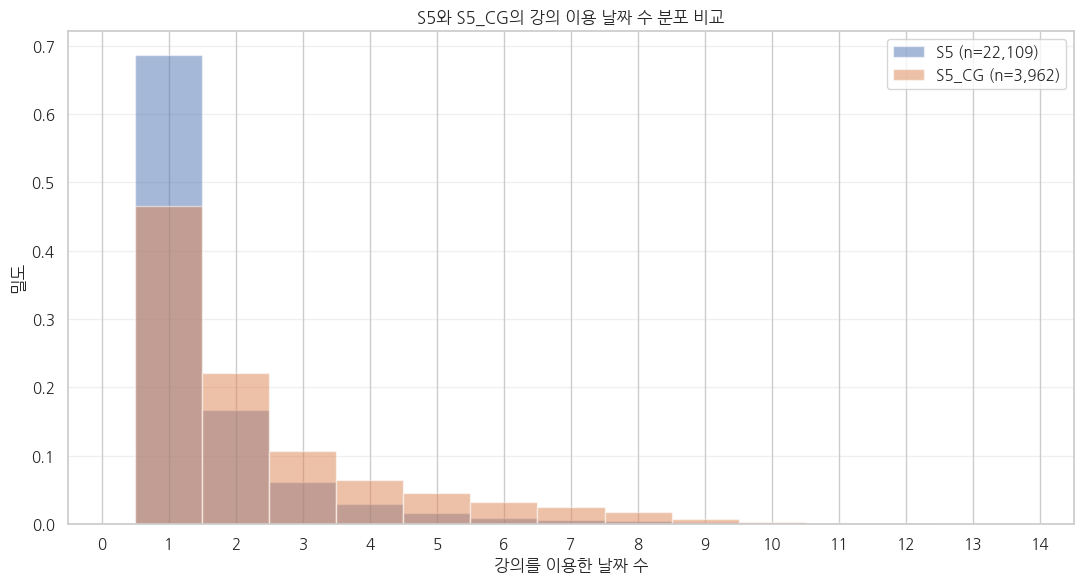

In [ ]:
# =========================================================
# S5 vs S5_CG 강의 이용 날짜 수 요약 + 분포 그래프
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ---------------------------------------------------------
# 1. user_days 컬럼명 맞추기
# ---------------------------------------------------------
user_days_compare = user_days.copy()

# segment 컬럼을 그룹으로 사용
if "그룹" not in user_days_compare.columns:
    user_days_compare = user_days_compare.rename(
        columns={"segment": "그룹"}
    )

# S5 / S5_CG만 사용
user_days_compare = user_days_compare[
    user_days_compare["그룹"].isin(["S5", "S5_CG"])
].copy()

user_days_compare["강의_이용_날짜_수"] = pd.to_numeric(
    user_days_compare["강의_이용_날짜_수"],
    errors="coerce"
)

user_days_compare = user_days_compare.dropna(
    subset=[
        "user_id",
        "그룹",
        "강의_이용_날짜_수"
    ]
)

user_days_compare["강의_이용_날짜_수"] = (
    user_days_compare["강의_이용_날짜_수"]
    .astype(int)
)


# ---------------------------------------------------------
# 2. 그룹별 요약
# ---------------------------------------------------------
summary = (
    user_days_compare
    .groupby("그룹")
    .agg(
        사용자_수=("user_id", "nunique"),
        평균_이용_날짜_수=("강의_이용_날짜_수", "mean"),
        중앙값=("강의_이용_날짜_수", "median"),
        Q1=("강의_이용_날짜_수", lambda x: x.quantile(0.25)),
        Q3=("강의_이용_날짜_수", lambda x: x.quantile(0.75)),
        최댓값=("강의_이용_날짜_수", "max")
    )
    .reindex(["S5", "S5_CG"])
    .reset_index()
)

summary[
    [
        "평균_이용_날짜_수",
        "중앙값",
        "Q1",
        "Q3"
    ]
] = summary[
    [
        "평균_이용_날짜_수",
        "중앙값",
        "Q1",
        "Q3"
    ]
].round(2)

print("[강의 이용 날짜 수 요약]")
display(summary)


# ---------------------------------------------------------
# 3. 분포 데이터
# ---------------------------------------------------------
s5_days = user_days_compare.loc[
    user_days_compare["그룹"] == "S5",
    "강의_이용_날짜_수"
]

s5_cg_days = user_days_compare.loc[
    user_days_compare["그룹"] == "S5_CG",
    "강의_이용_날짜_수"
]

print()
print(f"S5: {len(s5_days):,}명")
print(f"S5_CG: {len(s5_cg_days):,}명")


# ---------------------------------------------------------
# 4. 한글 폰트
# ---------------------------------------------------------
plt.rcParams["axes.unicode_minus"] = False


# ---------------------------------------------------------
# 5. 히스토그램
# ---------------------------------------------------------
max_days = int(
    user_days_compare["강의_이용_날짜_수"].max()
)

bins = np.arange(
    -0.5,
    max_days + 1.5,
    1
)

plt.figure(figsize=(11, 6))

plt.hist(
    s5_days,
    bins=bins,
    density=True,
    alpha=0.5,
    label=f"S5 (n={len(s5_days):,})"
)

plt.hist(
    s5_cg_days,
    bins=bins,
    density=True,
    alpha=0.5,
    label=f"S5_CG (n={len(s5_cg_days):,})"
)

# 화면만 0~14일 표시
plt.xlim(-0.5, 14.5)
plt.xticks(range(0, 15))

plt.xlabel("강의를 이용한 날짜 수")
plt.ylabel("밀도")
plt.title("S5와 S5_CG의 강의 이용 날짜 수 분포 비교")

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 가입 후 최초 결제 페이지 진입까지의 기간 비교

[가입 후 최초 결제페이지 진입까지의 기간 요약]


,segment,사용자수,평균,중앙값,Q1,Q3,최댓값
0,S5,22109,7.03,0.0,0.0,0.03,357.62
1,S5_CG,3815,4.98,0.0,0.0,0.41,302.13


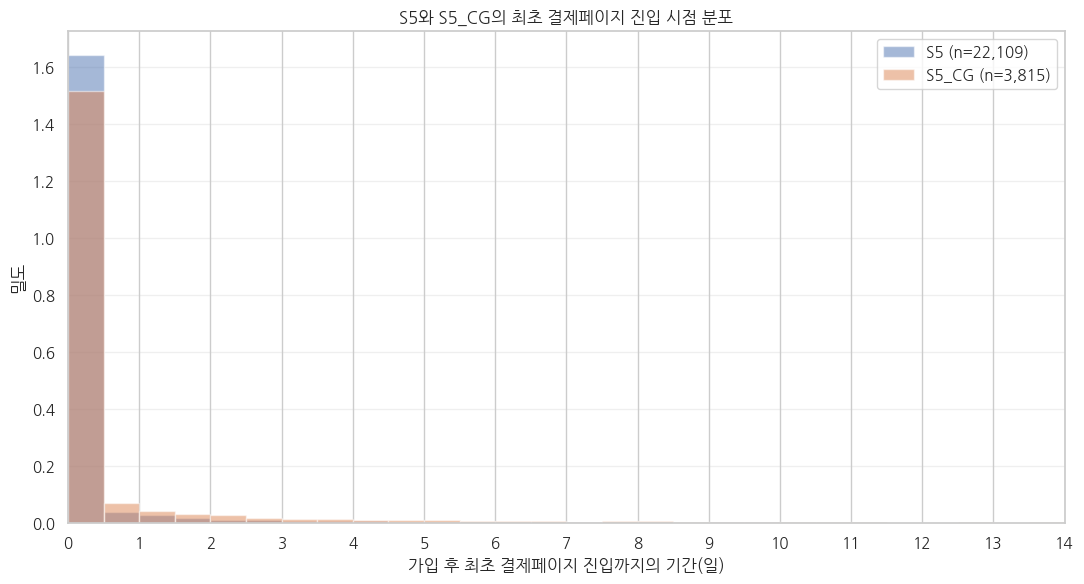

In [ ]:
# =========================================================
# S5 vs S5_CG
# 가입 후 최초 결제페이지 진입 시점 비교
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. 비교 대상
population = (
    analysis_population[
        ["user_id", "segment"]
    ]
    .dropna()
    .drop_duplicates("user_id")
)

population = population[
    population["segment"].isin(["S5", "S5_CG"])
]


# 2. 최초 가입 / 최초 결제 시각
def first_event(df, col_name):

    temp = df[
        ["user_id", "client_event_time"]
    ].copy()

    temp["client_event_time"] = pd.to_datetime(
        temp["client_event_time"],
        errors="coerce"
    )

    return (
        temp
        .dropna()
        .groupby("user_id", as_index=False)
        .agg(**{
            col_name: ("client_event_time", "min")
        })
    )


signup = first_event(
    complete_signup,
    "signup_time"
)

subscription = first_event(
    complete_subscription,
    "subscription_time"
)

base = (
    population
    .merge(signup, on="user_id", how="inner")
    .merge(subscription, on="user_id", how="left")
)

# S5_CG는 결제 시각 필수
base = base[
    (base["segment"] == "S5")
    |
    (
        (base["segment"] == "S5_CG")
        &
        base["subscription_time"].notna()
    )
]


# 3. 결제페이지 이벤트
payment = enter_payment_page[
    ["user_id", "client_event_time"]
].copy()

payment["client_event_time"] = pd.to_datetime(
    payment["client_event_time"],
    errors="coerce"
)

payment = (
    payment
    .dropna()
    .merge(
        base,
        on="user_id",
        how="inner"
    )
)

# 가입 이후
payment = payment[
    payment["client_event_time"]
    >= payment["signup_time"]
]

# S5 = 가입 이후 전체
# S5_CG = 가입 이후 ~ 최초 결제 이전
payment = payment[
    (payment["segment"] == "S5")
    |
    (
        (payment["segment"] == "S5_CG")
        &
        (
            payment["client_event_time"]
            < payment["subscription_time"]
        )
    )
]


# 4. user_id별 최초 결제페이지 진입
first_payment = (
    payment
    .groupby(
        ["segment", "user_id"],
        as_index=False
    )
    .agg(
        first_payment_time=(
            "client_event_time",
            "min"
        )
    )
    .merge(
        base[
            ["user_id", "signup_time"]
        ],
        on="user_id",
        how="left"
    )
)

first_payment["진입까지_기간_일"] = (
    first_payment["first_payment_time"]
    - first_payment["signup_time"]
).dt.total_seconds() / 86400


# 5. 요약
summary = (
    first_payment
    .groupby("segment")
    .agg(
        사용자수=("user_id", "nunique"),
        평균=("진입까지_기간_일", "mean"),
        중앙값=("진입까지_기간_일", "median"),
        Q1=("진입까지_기간_일", lambda x: x.quantile(0.25)),
        Q3=("진입까지_기간_일", lambda x: x.quantile(0.75)),
        최댓값=("진입까지_기간_일", "max")
    )
    .reindex(["S5", "S5_CG"])
    .round(2)
    .reset_index()
)

print("[가입 후 최초 결제페이지 진입까지의 기간 요약]")
display(summary)


# 6. 그래프
plt.figure(figsize=(11, 6))

for group in ["S5", "S5_CG"]:

    data = first_payment.loc[
        first_payment["segment"] == group,
        "진입까지_기간_일"
    ]

    plt.hist(
        data,
        bins=np.arange(0, data.max() + 0.5, 0.5),
        density=True,
        alpha=0.5,
        label=f"{group} (n={len(data):,})"
    )

plt.xlim(0, 14)
plt.xticks(range(0, 15))

plt.xlabel("가입 후 최초 결제페이지 진입까지의 기간(일)")
plt.ylabel("밀도")
plt.title("S5와 S5_CG의 최초 결제페이지 진입 시점 분포")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 결제 페이지 방문 및 이탈 후 학습 복귀 패턴 분석

### 결제 고민층(세그먼트5) vs 결제자 결제 페이지 방문 패턴

In [ ]:
# =========================================================
# S5 vs S5_CG 결제페이지 방문 패턴
# dfs 사용 안 함
# =========================================================

import pandas as pd


# =========================================================
# 0. 공통 함수
# =========================================================
def clean_user_id(series):
    return (
        series
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )


# =========================================================
# 1. S5 / S5_CG 사용자 추출
# =========================================================

population = analysis_population[
    ["user_id", "segment"]
].copy()

population["user_id"] = clean_user_id(
    population["user_id"]
)

population = (
    population
    .dropna(subset=["user_id", "segment"])
    .drop_duplicates("user_id")
)


s5_population = (
    population.loc[
        population["segment"] == "S5",
        ["user_id"]
    ]
    .reset_index(drop=True)
)

s5_cg_population = (
    population.loc[
        population["segment"] == "S5_CG",
        ["user_id"]
    ]
    .reset_index(drop=True)
)


print("[세그먼트 추출]")
print(f"S5 사용자 수: {len(s5_population):,}명")
print(f"S5_CG 사용자 수: {len(s5_cg_population):,}명")


# =========================================================
# 2. enter_payment_page 정리
# =========================================================

payment = enter_payment_page[
    [
        "user_id",
        "client_event_time"
    ]
].copy()

payment["user_id"] = clean_user_id(
    payment["user_id"]
)

payment["client_event_time"] = pd.to_datetime(
    payment["client_event_time"],
    errors="coerce"
)

payment = payment.dropna(
    subset=[
        "user_id",
        "client_event_time"
    ]
)


# =========================================================
# 3. user_id별 결제페이지 방문 횟수
# =========================================================

payment_count = (
    payment
    .groupby("user_id")
    .size()
    .rename("payment_visit_count")
    .reset_index()
)


# =========================================================
# 4. S5 사용자별 방문 횟수
# 방문 기록 없으면 0회
# =========================================================

s5_user_level = (
    s5_population
    .merge(
        payment_count,
        on="user_id",
        how="left"
    )
)

s5_user_level["payment_visit_count"] = (
    s5_user_level["payment_visit_count"]
    .fillna(0)
    .astype(int)
)

s5_user_level["group"] = "S5"


# =========================================================
# 5. S5_CG 사용자별 방문 횟수
# 결제페이지 방문 기록이 있는 사용자만 사용
# =========================================================

s5_cg_user_level = (
    s5_cg_population
    .merge(
        payment_count,
        on="user_id",
        how="inner"
    )
)

s5_cg_user_level = (
    s5_cg_user_level[
        s5_cg_user_level["payment_visit_count"] >= 1
    ]
    .copy()
    .reset_index(drop=True)
)

s5_cg_user_level["group"] = "S5_CG"


# =========================================================
# 6. 분석 대상 확인
# =========================================================

s5_count = len(s5_user_level)

s5_cg_original_count = len(
    s5_cg_population
)

s5_cg_filtered_count = len(
    s5_cg_user_level
)

s5_cg_excluded_count = (
    s5_cg_original_count
    - s5_cg_filtered_count
)


print("\n[분석 대상 사용자 규모]")
print(f"S5: {s5_count:,}명")

print(
    f"S5_CG: "
    f"{s5_cg_original_count:,}명"
)

print(
    f"  ├ 결제페이지 방문: "
    f"{s5_cg_filtered_count:,}명"
)

if s5_cg_original_count > 0:

    excluded_pct = (
        s5_cg_excluded_count
        / s5_cg_original_count
        * 100
    )

    print(
        f"  └ 결제페이지 미방문: "
        f"{s5_cg_excluded_count:,}명 "
        f"({excluded_pct:.1f}%)"
    )


# =========================================================
# 7. 두 그룹 통합
# =========================================================

user_level = pd.concat(
    [
        s5_user_level[
            [
                "user_id",
                "group",
                "payment_visit_count"
            ]
        ],

        s5_cg_user_level[
            [
                "user_id",
                "group",
                "payment_visit_count"
            ]
        ]
    ],
    ignore_index=True
)


# =========================================================
# 8. 그룹별 집계
# =========================================================

summary = (
    user_level
    .groupby(
        "group",
        as_index=False
    )
    .agg(

        규모=(
            "user_id",
            "nunique"
        ),

        방문_1회=(
            "payment_visit_count",
            lambda x: (x == 1).sum()
        ),

        방문_2회이상=(
            "payment_visit_count",
            lambda x: (x >= 2).sum()
        ),

        평균_방문_횟수=(
            "payment_visit_count",
            "mean"
        )
    )
)


# =========================================================
# 9. 비율 계산
# =========================================================

summary["1회_방문_비율(%)"] = (
    summary["방문_1회"]
    / summary["규모"]
    * 100
).round(1)

summary["2회이상_방문_비율(%)"] = (
    summary["방문_2회이상"]
    / summary["규모"]
    * 100
).round(1)

summary["평균_방문_횟수"] = (
    summary["평균_방문_횟수"]
    .round(2)
)


# =========================================================
# 10. 출력 순서
# =========================================================

summary["group"] = pd.Categorical(
    summary["group"],
    categories=[
        "S5",
        "S5_CG"
    ],
    ordered=True
)

summary = (
    summary
    .sort_values("group")
    .reset_index(drop=True)
)


# =========================================================
# 11. 최종 비교표
# =========================================================

s5_row = summary.loc[
    summary["group"] == "S5"
].iloc[0]

s5_cg_row = summary.loc[
    summary["group"] == "S5_CG"
].iloc[0]


comparison_table = pd.DataFrame({

    "지표": [
        "규모",
        "1회 방문",
        "2회 이상",
        "평균 방문"
    ],

    "S5": [
        f"{int(s5_row['규모']):,}명",

        (
            f"{int(s5_row['방문_1회']):,}명 "
            f"({s5_row['1회_방문_비율(%)']:.1f}%)"
        ),

        (
            f"{int(s5_row['방문_2회이상']):,}명 "
            f"({s5_row['2회이상_방문_비율(%)']:.1f}%)"
        ),

        f"{s5_row['평균_방문_횟수']:.2f}회"
    ],

    "S5_CG": [
        f"{int(s5_cg_row['규모']):,}명",

        (
            f"{int(s5_cg_row['방문_1회']):,}명 "
            f"({s5_cg_row['1회_방문_비율(%)']:.1f}%)"
        ),

        (
            f"{int(s5_cg_row['방문_2회이상']):,}명 "
            f"({s5_cg_row['2회이상_방문_비율(%)']:.1f}%)"
        ),

        f"{s5_cg_row['평균_방문_횟수']:.2f}회"
    ]
})


# =========================================================
# 12. 최종 출력
# =========================================================

print("\n[결제페이지 방문 패턴: S5 vs S5_CG]")
display(comparison_table)

print("\n[수치형 집계]")
display(
    summary.rename(
        columns={
            "group": "비교그룹"
        }
    )
)

[세그먼트 추출]
S5 사용자 수: 22,109명
S5_CG 사용자 수: 3,962명

[분석 대상 사용자 규모]
S5: 22,109명
S5_CG: 3,962명
  ├ 결제페이지 방문: 3,845명
  └ 결제페이지 미방문: 117명 (3.0%)

[결제페이지 방문 패턴: S5 vs S5_CG]


,지표,S5,S5_CG
0,규모,"22,109명","3,845명"
1,1회 방문,"11,091명 (50.2%)",512명 (13.3%)
2,2회 이상,"11,018명 (49.8%)","3,333명 (86.7%)"
3,평균 방문,2.12회,4.56회



[수치형 집계]


,비교그룹,규모,방문_1회,방문_2회이상,평균_방문_횟수,1회_방문_비율(%),2회이상_방문_비율(%)
0,S5,22109,11091,11018,2.12,50.2,49.8
1,S5_CG,3845,512,3333,4.56,13.3,86.7


In [ ]:
!apt-get -qq install fonts-nanum
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

✓ 차트 저장 완료: 가설4_결제페이지방문패턴.png


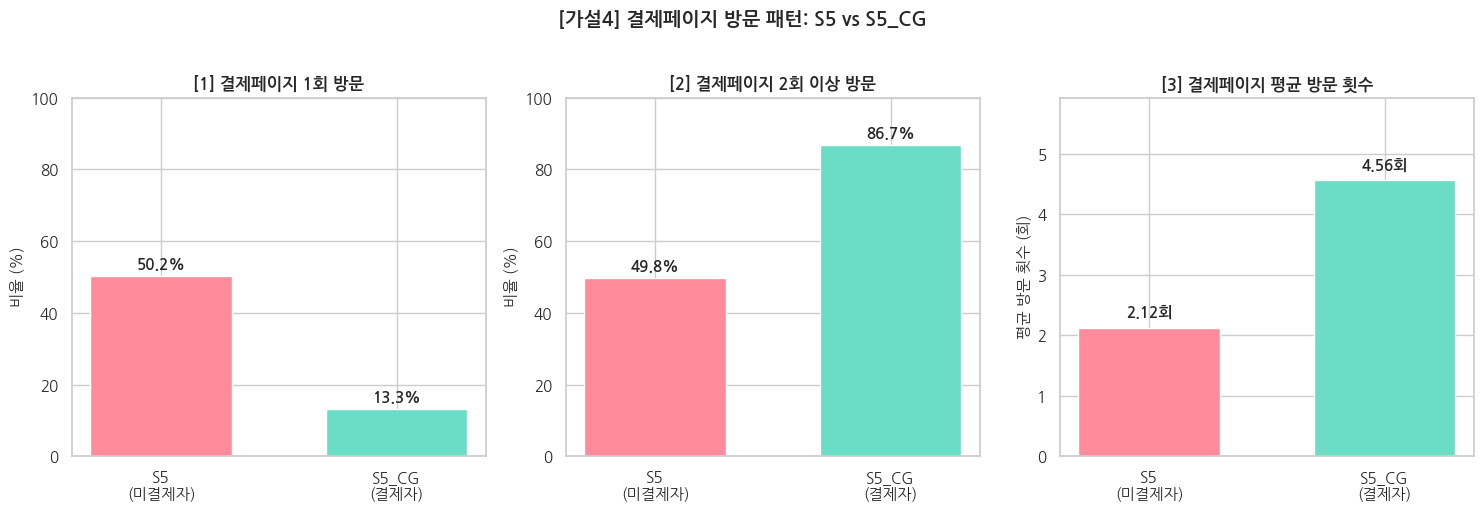

In [ ]:
plt.rcParams["axes.unicode_minus"] = False

color_s5 = "#FF8B9B"
color_s5_cg = "#6BDDC4"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# [1] 1회 방문 비율
s5_1회 = summary.loc[
    summary["group"] == "S5",
    "1회_방문_비율(%)"
].values[0]

s5_cg_1회 = summary.loc[
    summary["group"] == "S5_CG",
    "1회_방문_비율(%)"
].values[0]

axes[0].bar(
    ["S5\n(미결제자)", "S5_CG\n(결제자)"],
    [s5_1회, s5_cg_1회],
    color=[color_s5, color_s5_cg],
    width=0.6
)

axes[0].set_ylabel("비율 (%)", fontsize=11)
axes[0].set_ylim(0, 100)
axes[0].set_title(
    "[1] 결제페이지 1회 방문",
    fontsize=12,
    fontweight="bold"
)

for i, v in enumerate([s5_1회, s5_cg_1회]):
    axes[0].text(
        i,
        v + 2,
        f"{v:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )


# [2] 2회 이상 방문 비율
s5_2회이상 = summary.loc[
    summary["group"] == "S5",
    "2회이상_방문_비율(%)"
].values[0]

s5_cg_2회이상 = summary.loc[
    summary["group"] == "S5_CG",
    "2회이상_방문_비율(%)"
].values[0]

axes[1].bar(
    ["S5\n(미결제자)", "S5_CG\n(결제자)"],
    [s5_2회이상, s5_cg_2회이상],
    color=[color_s5, color_s5_cg],
    width=0.6
)

axes[1].set_ylabel("비율 (%)", fontsize=11)
axes[1].set_ylim(0, 100)
axes[1].set_title(
    "[2] 결제페이지 2회 이상 방문",
    fontsize=12,
    fontweight="bold"
)

for i, v in enumerate([s5_2회이상, s5_cg_2회이상]):
    axes[1].text(
        i,
        v + 2,
        f"{v:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )


# [3] 평균 방문 횟수
s5_avg = summary.loc[
    summary["group"] == "S5",
    "평균_방문_횟수"
].values[0]

s5_cg_avg = summary.loc[
    summary["group"] == "S5_CG",
    "평균_방문_횟수"
].values[0]

axes[2].bar(
    ["S5\n(미결제자)", "S5_CG\n(결제자)"],
    [s5_avg, s5_cg_avg],
    color=[color_s5, color_s5_cg],
    width=0.6
)

axes[2].set_ylabel(
    "평균 방문 횟수 (회)",
    fontsize=11
)

axes[2].set_ylim(
    0,
    max(s5_avg, s5_cg_avg) * 1.3
)

axes[2].set_title(
    "[3] 결제페이지 평균 방문 횟수",
    fontsize=12,
    fontweight="bold"
)

for i, v in enumerate([s5_avg, s5_cg_avg]):
    axes[2].text(
        i,
        v + max(s5_avg, s5_cg_avg) * 0.04,
        f"{v:.2f}회",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )


plt.suptitle(
    "[가설4] 결제페이지 방문 패턴: S5 vs S5_CG",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "가설4_결제페이지방문패턴.png",
    dpi=300,
    bbox_inches="tight"
)

print("✓ 차트 저장 완료: 가설4_결제페이지방문패턴.png")

plt.show()

### 결제 페이지 방문 이후 학습 복귀 현황

In [ ]:
# =========================================================
# 가설 4-2
# 결제페이지 방문 후 학습 복귀 분석
# 결과 기준 유지 버전
# =========================================================

import pandas as pd


# 1. S5 / S5_CG 사용자
s5_user_ids = set(
    analysis_population.loc[
        analysis_population["segment"] == "S5",
        "user_id"
    ].dropna().unique()
)

s5_cg_user_ids = set(
    analysis_population.loc[
        analysis_population["segment"] == "S5_CG",
        "user_id"
    ].dropna().unique()
)


# 2. 결제페이지 최초 방문 시점
payment = enter_payment_page[
    ["user_id", "client_event_time"]
].copy()

payment["client_event_time"] = pd.to_datetime(
    payment["client_event_time"],
    errors="coerce"
)

payment = payment.dropna(
    subset=["user_id", "client_event_time"]
)

first_payment_visit = (
    payment
    .groupby("user_id", as_index=False)
    .agg(
        first_payment_page_at=(
            "client_event_time",
            "min"
        )
    )
)


# 3. 레슨페이지
lesson = enter_lesson_page[
    ["user_id", "client_event_time"]
].copy()

lesson["client_event_time"] = pd.to_datetime(
    lesson["client_event_time"],
    errors="coerce"
)

lesson = lesson.dropna(
    subset=["user_id", "client_event_time"]
)


# 4. 첫 결제페이지 방문 이후 레슨 기록
lesson_after_payment = (
    lesson
    .merge(
        first_payment_visit,
        on="user_id",
        how="inner"
    )
)

lesson_after_payment = lesson_after_payment[
    lesson_after_payment["client_event_time"]
    >= lesson_after_payment["first_payment_page_at"]
].copy()


# 5. 그룹별 결과 계산 함수
def make_return_summary(group_name, user_ids):

    # 결제페이지 방문한 사용자만 분모
    payment_users = first_payment_visit[
        first_payment_visit["user_id"].isin(user_ids)
    ].copy()

    # 결제페이지 방문 이후 레슨 진입한 사용자
    return_users = set(
        lesson_after_payment.loc[
            lesson_after_payment["user_id"].isin(user_ids),
            "user_id"
        ].unique()
    )

    total = payment_users["user_id"].nunique()

    returned = payment_users[
        payment_users["user_id"].isin(return_users)
    ]["user_id"].nunique()

    not_returned = total - returned

    return {
        "비교 그룹": group_name,
        "결제페이지 방문 사용자 수": total,
        "학습 복귀 사용자 수": returned,
        "미복귀 사용자 수": not_returned,
        "학습 복귀율(%)": (
            returned / total * 100
            if total > 0 else 0
        ),
        "미복귀율(%)": (
            not_returned / total * 100
            if total > 0 else 0
        )
    }


# 6. 최종 결과
summary_table = pd.DataFrame([
    make_return_summary(
        "세그먼트5",
        s5_user_ids
    ),
    make_return_summary(
        "S5_CG",
        s5_cg_user_ids
    )
])

summary_table[
    [
        "학습 복귀율(%)",
        "미복귀율(%)"
    ]
] = (
    summary_table[
        [
            "학습 복귀율(%)",
            "미복귀율(%)"
        ]
    ]
    .round(2)
)


# 7. 출력
print("[가설 4-2] 결제페이지 방문 후 학습 복귀 분석")
print()

print(
    f"S5 사용자: "
    f"{summary_table.loc[0, '결제페이지 방문 사용자 수']:,}명"
)

print(
    f"S5_CG 사용자: "
    f"{summary_table.loc[1, '결제페이지 방문 사용자 수']:,}명"
)

print()
display(summary_table)

[가설 4-2] 결제페이지 방문 후 학습 복귀 분석

S5 사용자: 22,109명
S5_CG 사용자: 3,845명



,비교 그룹,결제페이지 방문 사용자 수,학습 복귀 사용자 수,미복귀 사용자 수,학습 복귀율(%),미복귀율(%)
0,세그먼트5,22109,15994,6115,72.34,27.66
1,S5_CG,3845,3816,29,99.25,0.75


줄어드는 이유는 enter_payment_page 기록이 없는 인원이 117명이 있기 때문

In [ ]:
!apt-get -qq install fonts-nanum
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

[가설 4-2 시각화]

✓ 차트 저장 완료: 가설4_2_결제페이지후학습복귀.png


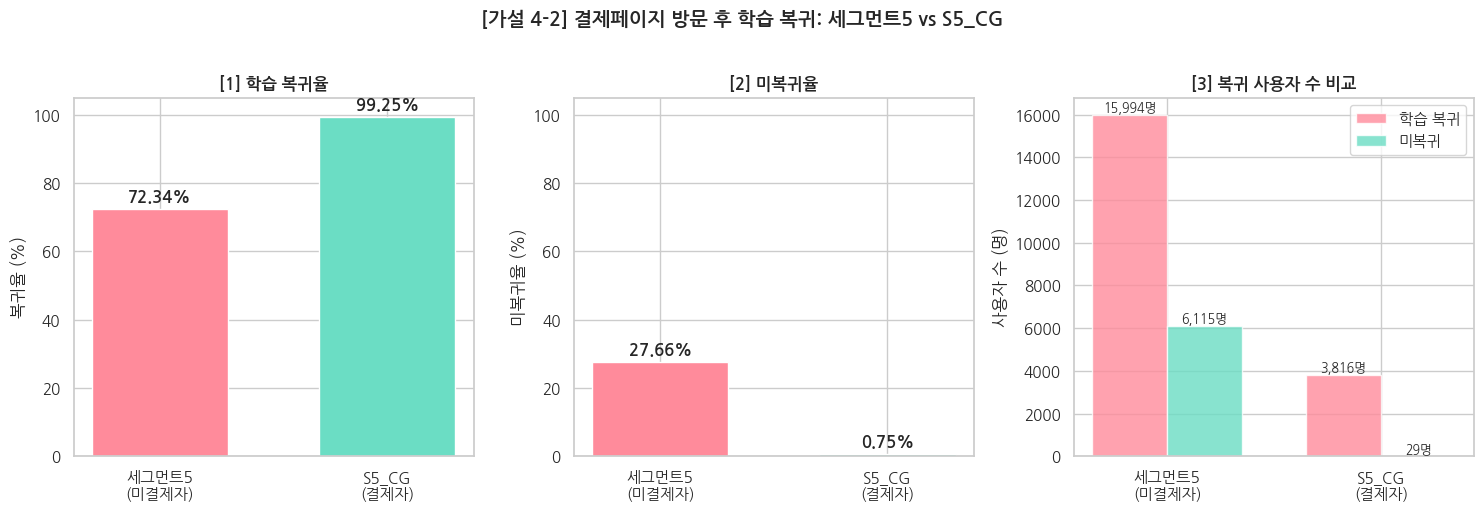

In [ ]:
# =========================================================
# 가설 4-2 시각화
# summary_table 기준
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

print("[가설 4-2 시각화]")
print()

# Colab에서는 Malgun Gothic 지정하지 않음
plt.rcParams["axes.unicode_minus"] = False

color_s5 = "#FF8B9B"
color_s5_cg = "#6BDDC4"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


# =========================================================
# 1. 그룹 데이터
# =========================================================

s5_data = summary_table[
    summary_table["비교 그룹"] == "세그먼트5"
].iloc[0]

s5_cg_data = summary_table[
    summary_table["비교 그룹"] == "S5_CG"
].iloc[0]

groups = [
    "세그먼트5\n(미결제자)",
    "S5_CG\n(결제자)"
]

colors = [
    color_s5,
    color_s5_cg
]


# =========================================================
# 2. 학습 복귀율
# =========================================================

returned_rates = [
    s5_data["학습 복귀율(%)"],
    s5_cg_data["학습 복귀율(%)"]
]

axes[0].bar(
    groups,
    returned_rates,
    color=colors,
    width=0.6
)

axes[0].set_ylabel("복귀율 (%)")
axes[0].set_ylim(0, 105)
axes[0].set_title(
    "[1] 학습 복귀율",
    fontweight="bold"
)

for i, v in enumerate(returned_rates):
    axes[0].text(
        i,
        v + 2,
        f"{v:.2f}%",
        ha="center",
        fontweight="bold"
    )


# =========================================================
# 3. 미복귀율
# =========================================================

not_returned_rates = [
    s5_data["미복귀율(%)"],
    s5_cg_data["미복귀율(%)"]
]

axes[1].bar(
    groups,
    not_returned_rates,
    color=colors,
    width=0.6
)

axes[1].set_ylabel("미복귀율 (%)")
axes[1].set_ylim(0, 105)
axes[1].set_title(
    "[2] 미복귀율",
    fontweight="bold"
)

for i, v in enumerate(not_returned_rates):
    axes[1].text(
        i,
        v + 2,
        f"{v:.2f}%",
        ha="center",
        fontweight="bold"
    )


# =========================================================
# 4. 복귀 / 미복귀 사용자 수
# =========================================================

s5_returned = s5_data["학습 복귀 사용자 수"]
s5_not_returned = s5_data["미복귀 사용자 수"]

s5_cg_returned = s5_cg_data["학습 복귀 사용자 수"]
s5_cg_not_returned = s5_cg_data["미복귀 사용자 수"]

x_pos = np.arange(len(groups))
width = 0.35

bars1 = axes[2].bar(
    x_pos - width / 2,
    [
        s5_returned,
        s5_cg_returned
    ],
    width,
    label="학습 복귀",
    color=color_s5,
    alpha=0.8
)

bars2 = axes[2].bar(
    x_pos + width / 2,
    [
        s5_not_returned,
        s5_cg_not_returned
    ],
    width,
    label="미복귀",
    color=color_s5_cg,
    alpha=0.8
)

axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(groups)
axes[2].set_ylabel("사용자 수 (명)")
axes[2].set_title(
    "[3] 복귀 사용자 수 비교",
    fontweight="bold"
)

axes[2].legend()


# 값 표시
for bars in [bars1, bars2]:

    for bar in bars:

        height = bar.get_height()

        axes[2].text(
            bar.get_x()
            + bar.get_width() / 2,
            height,
            f"{int(height):,}명",
            ha="center",
            va="bottom",
            fontsize=9
        )


# =========================================================
# 5. 전체 제목
# =========================================================

plt.suptitle(
    "[가설 4-2] 결제페이지 방문 후 학습 복귀: 세그먼트5 vs S5_CG",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "가설4_2_결제페이지후학습복귀.png",
    dpi=300,
    bbox_inches="tight"
)

print(
    "✓ 차트 저장 완료: "
    "가설4_2_결제페이지후학습복귀.png"
)

plt.show()

### 결제 직전 72시간 학습 행동

In [ ]:
# =========================================================
# 가설 5
# 결제 직전 72시간 학습 행동 분석
# 원래 결과 재현 버전
#
# 필요 변수:
# s5_user_ids
# s5_cg_user_ids
# subscriber_base
# =========================================================

import pandas as pd
import numpy as np


# =========================================================
# 0. 공통 함수
# =========================================================
def clean_join_key(series):
    return (
        series
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )


print("[가설 5] 결제 직전 72시간 학습 행동 분석")
print()


# =========================================================
# 1. enter_lesson_page
# =========================================================
lesson_enter = enter_lesson_page[
    [
        "user_id",
        "client_event_time"
    ]
].copy()

lesson_enter["user_id"] = clean_join_key(
    lesson_enter["user_id"]
)

lesson_enter["client_event_time"] = pd.to_datetime(
    lesson_enter["client_event_time"],
    errors="coerce"
)

lesson_enter = lesson_enter.dropna(
    subset=[
        "user_id",
        "client_event_time"
    ]
)


# =========================================================
# 2. complete_lesson
# =========================================================
lesson_complete = complete_lesson[
    [
        "user_id",
        "client_event_time"
    ]
].copy()

lesson_complete["user_id"] = clean_join_key(
    lesson_complete["user_id"]
)

lesson_complete["client_event_time"] = pd.to_datetime(
    lesson_complete["client_event_time"],
    errors="coerce"
)

lesson_complete = lesson_complete.dropna(
    subset=[
        "user_id",
        "client_event_time"
    ]
)


# =========================================================
# 3. enter_payment_page
# S5의 기준 시점 = 최신 결제페이지 방문
# =========================================================
payment = enter_payment_page[
    [
        "user_id",
        "client_event_time"
    ]
].copy()

payment["user_id"] = clean_join_key(
    payment["user_id"]
)

payment["client_event_time"] = pd.to_datetime(
    payment["client_event_time"],
    errors="coerce"
)

payment = payment.dropna(
    subset=[
        "user_id",
        "client_event_time"
    ]
)

latest_payment_visit = (
    payment
    .groupby(
        "user_id",
        as_index=False
    )["client_event_time"]
    .max()
    .rename(
        columns={
            "client_event_time":
                "latest_payment_visit_at"
        }
    )
)


# =========================================================
# 4. S5
# 최신 결제페이지 방문 직전 72시간
# =========================================================
print("【S5 미결제자 분석】")

s5_users_with_payment = (
    pd.DataFrame({
        "user_id": list(s5_user_ids)
    })
    .merge(
        latest_payment_visit,
        on="user_id",
        how="inner"
    )
)

print(
    f"분석 대상 S5: "
    f"{len(s5_users_with_payment):,}명"
)

s5_users_with_payment["72h_start"] = (
    s5_users_with_payment["latest_payment_visit_at"]
    - pd.Timedelta(hours=72)
)

s5_users_with_payment["72h_end"] = (
    s5_users_with_payment["latest_payment_visit_at"]
)


# 72시간 내 레슨 진입
s5_lesson_enter = lesson_enter.merge(
    s5_users_with_payment[
        [
            "user_id",
            "72h_start",
            "72h_end"
        ]
    ],
    on="user_id",
    how="inner"
)

s5_lesson_enter = s5_lesson_enter[
    (
        s5_lesson_enter["client_event_time"]
        >= s5_lesson_enter["72h_start"]
    )
    &
    (
        s5_lesson_enter["client_event_time"]
        <= s5_lesson_enter["72h_end"]
    )
]


# 72시간 내 레슨 완강
s5_lesson_complete = lesson_complete.merge(
    s5_users_with_payment[
        [
            "user_id",
            "72h_start",
            "72h_end"
        ]
    ],
    on="user_id",
    how="inner"
)

s5_lesson_complete = s5_lesson_complete[
    (
        s5_lesson_complete["client_event_time"]
        >= s5_lesson_complete["72h_start"]
    )
    &
    (
        s5_lesson_complete["client_event_time"]
        <= s5_lesson_complete["72h_end"]
    )
]


# 사용자별 횟수
s5_enter_count = (
    s5_lesson_enter
    .groupby("user_id")
    .size()
    .rename("lesson_enter_count")
)

s5_complete_count = (
    s5_lesson_complete
    .groupby("user_id")
    .size()
    .rename("lesson_complete_count")
)


# 원래 코드와 동일:
# 전체 s5_user_ids를 기준으로 0회 사용자도 포함
s5_stats = pd.DataFrame({
    "user_id": list(s5_user_ids)
})

s5_stats = (
    s5_stats
    .merge(
        s5_enter_count,
        on="user_id",
        how="left"
    )
    .merge(
        s5_complete_count,
        on="user_id",
        how="left"
    )
)

s5_stats[
    [
        "lesson_enter_count",
        "lesson_complete_count"
    ]
] = (
    s5_stats[
        [
            "lesson_enter_count",
            "lesson_complete_count"
        ]
    ]
    .fillna(0)
    .astype(int)
)

s5_stats["completion_rate"] = np.where(
    s5_stats["lesson_enter_count"] > 0,
    (
        s5_stats["lesson_complete_count"]
        /
        s5_stats["lesson_enter_count"]
        * 100
    ),
    0
)

s5_stats["segment"] = "세그먼트5"


# =========================================================
# 5. S5_CG
# 실제 결제 직전 72시간
# =========================================================
print()
print("【S5_CG 결제자 분석】")

s5_cg_users_with_subscription = (
    pd.DataFrame({
        "user_id": list(s5_cg_user_ids)
    })

    # 결제페이지 방문 기록이 있는 사용자만 남김
    .merge(
        latest_payment_visit[
            ["user_id"]
        ],
        on="user_id",
        how="inner"
    )

    # 실제 최초 결제 시각 연결
    .merge(
        subscriber_base[
            [
                "user_id",
                "subscription_at"
            ]
        ],
        on="user_id",
        how="inner"
    )

    .drop_duplicates("user_id")
)


print(
    f"분석 대상 S5_CG: "
    f"{len(s5_cg_users_with_subscription):,}명"
)

s5_cg_users_with_subscription["72h_start"] = (
    s5_cg_users_with_subscription["subscription_at"]
    - pd.Timedelta(hours=72)
)

s5_cg_users_with_subscription["72h_end"] = (
    s5_cg_users_with_subscription["subscription_at"]
)


# 72시간 내 레슨 진입
s5_cg_lesson_enter = lesson_enter.merge(
    s5_cg_users_with_subscription[
        [
            "user_id",
            "72h_start",
            "72h_end"
        ]
    ],
    on="user_id",
    how="inner"
)

s5_cg_lesson_enter = s5_cg_lesson_enter[
    (
        s5_cg_lesson_enter["client_event_time"]
        >= s5_cg_lesson_enter["72h_start"]
    )
    &
    (
        s5_cg_lesson_enter["client_event_time"]
        <= s5_cg_lesson_enter["72h_end"]
    )
]


# 72시간 내 레슨 완강
s5_cg_lesson_complete = lesson_complete.merge(
    s5_cg_users_with_subscription[
        [
            "user_id",
            "72h_start",
            "72h_end"
        ]
    ],
    on="user_id",
    how="inner"
)

s5_cg_lesson_complete = s5_cg_lesson_complete[
    (
        s5_cg_lesson_complete["client_event_time"]
        >= s5_cg_lesson_complete["72h_start"]
    )
    &
    (
        s5_cg_lesson_complete["client_event_time"]
        <= s5_cg_lesson_complete["72h_end"]
    )
]


# 사용자별 횟수
s5_cg_enter_count = (
    s5_cg_lesson_enter
    .groupby("user_id")
    .size()
    .reset_index(
        name="lesson_enter_count"
    )
)

s5_cg_complete_count = (
    s5_cg_lesson_complete
    .groupby("user_id")
    .size()
    .reset_index(
        name="lesson_complete_count"
    )
)


# 원래 코드와 동일:
# 전체 s5_cg_user_ids를 기준으로 0회 사용자도 포함
s5_cg_stats = (
    s5_cg_users_with_subscription[
        ["user_id"]
    ]
    .drop_duplicates()
    .copy()
)

s5_cg_stats = s5_cg_stats.merge(
    s5_cg_enter_count,
    on="user_id",
    how="left"
)

# 레슨 완강 횟수 연결
s5_cg_stats = s5_cg_stats.merge(
    s5_cg_complete_count,
    on="user_id",
    how="left"
)

s5_cg_stats[
    [
        "lesson_enter_count",
        "lesson_complete_count"
    ]
] = (
    s5_cg_stats[
        [
            "lesson_enter_count",
            "lesson_complete_count"
        ]
    ]
    .fillna(0)
    .astype(int)
)


s5_cg_stats["completion_rate"] = np.where(
    s5_cg_stats["lesson_enter_count"] > 0,
    (
        s5_cg_stats["lesson_complete_count"]
        /
        s5_cg_stats["lesson_enter_count"]
        * 100
    ),
    0
)

s5_cg_stats["segment"] = "S5_CG"


# =========================================================
# 6. 통합
# =========================================================
all_stats = pd.concat(
    [
        s5_stats,
        s5_cg_stats
    ],
    ignore_index=True
)


# =========================================================
# 7. 기존 형식 그대로 출력
# =========================================================
print()
print("=" * 80)
print("[가설 5] 결제 직전 72시간 학습 행동 분석")
print("=" * 80)

for segment in [
    "세그먼트5",
    "S5_CG"
]:

    seg_data = all_stats[
        all_stats["segment"] == segment
    ]

    print()
    print(f"【{segment}】")
    print(
        f"사용자 수: "
        f"{len(seg_data):,}명"
    )

    print("\n[학습 진입 횟수]")
    print(
        f"  중앙값: "
        f"{seg_data['lesson_enter_count'].median():.1f}회"
    )
    print(
        f"  평균값: "
        f"{seg_data['lesson_enter_count'].mean():.2f}회"
    )
    print(
        f"  사분위수: "
        f"Q1={seg_data['lesson_enter_count'].quantile(0.25):.1f}, "
        f"Q3={seg_data['lesson_enter_count'].quantile(0.75):.1f}"
    )

    print("\n[학습 완강 횟수]")
    print(
        f"  중앙값: "
        f"{seg_data['lesson_complete_count'].median():.1f}회"
    )
    print(
        f"  평균값: "
        f"{seg_data['lesson_complete_count'].mean():.2f}회"
    )
    print(
        f"  사분위수: "
        f"Q1={seg_data['lesson_complete_count'].quantile(0.25):.1f}, "
        f"Q3={seg_data['lesson_complete_count'].quantile(0.75):.1f}"
    )

    # 원래 코드와 동일:
    # 학습 진입자 중 complete_lesson 1회 이상 경험 비율
    with_entry = seg_data[
        seg_data["lesson_enter_count"] > 0
    ]

    completion_pct = (
        (
            with_entry["lesson_complete_count"] > 0
        ).mean()
        * 100
        if len(with_entry) > 0
        else 0
    )

    print("\n[학습 완강률]")
    print(
        f"  완강 경험 비율: "
        f"{completion_pct:.1f}%"
    )
    print(
        f"  평균 완강률: "
        f"{seg_data['completion_rate'].mean():.1f}%"
    )


# =========================================================
# 8. 비교 요약
# =========================================================
comparison_data = []

for segment in [
    "세그먼트5",
    "S5_CG"
]:

    seg_data = all_stats[
        all_stats["segment"] == segment
    ]

    with_entry = seg_data[
        seg_data["lesson_enter_count"] > 0
    ]

    completion_pct = (
        (
            with_entry["lesson_complete_count"] > 0
        ).mean()
        * 100
        if len(with_entry) > 0
        else 0
    )

    comparison_data.append({
        "구분": segment,
        "사용자_수": len(seg_data),
        "진입_중앙값":
            seg_data["lesson_enter_count"].median(),
        "진입_평균값":
            seg_data["lesson_enter_count"].mean(),
        "완강_중앙값":
            seg_data["lesson_complete_count"].median(),
        "완강_평균값":
            seg_data["lesson_complete_count"].mean(),
        "완강_경험_비율(%)":
            completion_pct
    })


comparison_table = pd.DataFrame(
    comparison_data
)

print()
print("=" * 80)
print("[비교 요약]")
print("=" * 80)

display(comparison_table)

[가설 5] 결제 직전 72시간 학습 행동 분석

【S5 미결제자 분석】
분석 대상 S5: 22,109명

【S5_CG 결제자 분석】
분석 대상 S5_CG: 3,845명

[가설 5] 결제 직전 72시간 학습 행동 분석

【세그먼트5】
사용자 수: 22,109명

[학습 진입 횟수]
  중앙값: 1.0회
  평균값: 8.10회
  사분위수: Q1=0.0, Q3=4.0

[학습 완강 횟수]
  중앙값: 0.0회
  평균값: 1.71회
  사분위수: Q1=0.0, Q3=0.0

[학습 완강률]
  완강 경험 비율: 28.8%
  평균 완강률: 10.0%

【S5_CG】
사용자 수: 3,845명

[학습 진입 횟수]
  중앙값: 5.0회
  평균값: 30.50회
  사분위수: Q1=1.0, Q3=37.0

[학습 완강 횟수]
  중앙값: 0.0회
  평균값: 6.77회
  사분위수: Q1=0.0, Q3=11.0

[학습 완강률]
  완강 경험 비율: 53.9%
  평균 완강률: 20.1%

[비교 요약]


,구분,사용자_수,진입_중앙값,진입_평균값,완강_중앙값,완강_평균값,완강_경험_비율(%)
0,세그먼트5,22109,1.0,8.095255,0.0,1.708354,28.824588
1,S5_CG,3845,5.0,30.502731,0.0,6.772432,53.917846


In [ ]:
!apt-get -qq install fonts-nanum
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

[가설 5 시각화]



/tmp/ipykernel_158862/492466802.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(
/tmp/ipykernel_158862/492466802.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(


✓ 차트 저장 완료: 가설5_결제직전72시간학습행동.png



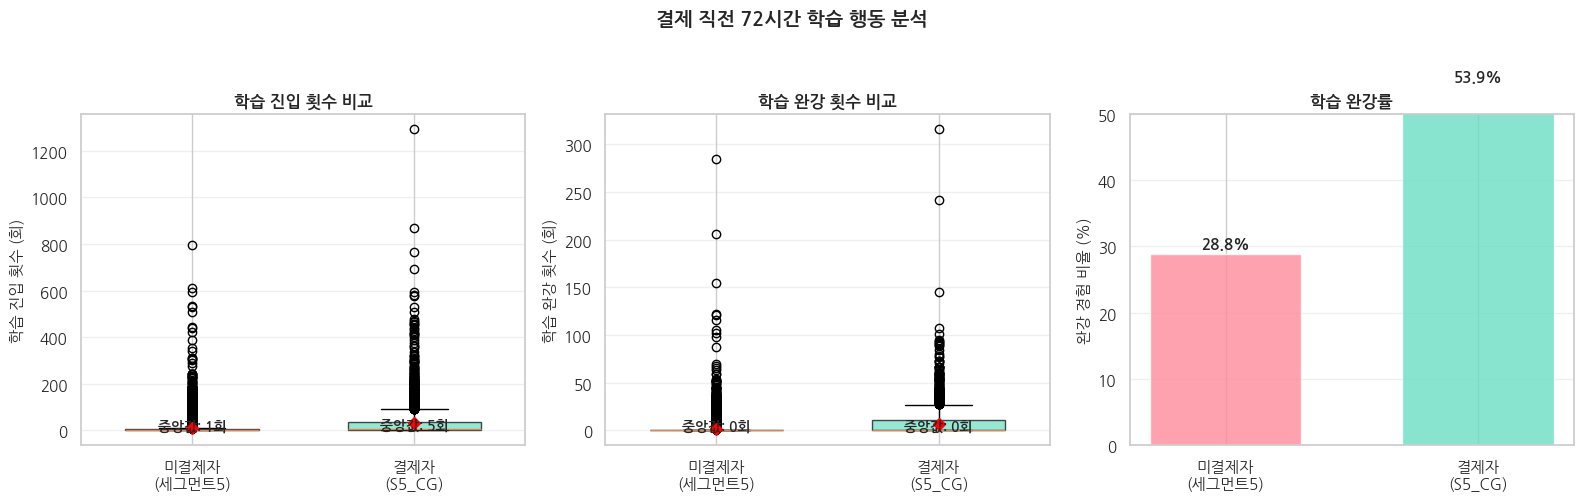

In [ ]:
# 가설 5 분석 코드를 먼저 실행한 후 이 코드 실행
# 필요 변수: all_stats

print("[가설 5 시각화]")
print()

# =========================================================
# 시각화 설정
# =========================================================
!apt-get -qq install fonts-nanum
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

color_s5 = "#FF8B9B"      # 세그먼트5 (분홍색)
color_s5_cg = "#6BDDC4"   # S5_CG (청록색)


# =========================================================
# 1. 3개 서브플롯 생성
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 데이터 준비
s5_data = all_stats[all_stats["segment"] == "세그먼트5"]
s5_cg_data = all_stats[all_stats["segment"] == "S5_CG"]

box_data_enter = [
    s5_data["lesson_enter_count"].values,
    s5_cg_data["lesson_enter_count"].values
]

box_data_complete = [
    s5_data["lesson_complete_count"].values,
    s5_cg_data["lesson_complete_count"].values
]

# =========================================================
# [1] 학습 진입 횟수 비교 (박스플롯)
# =========================================================
bp1 = axes[0].boxplot(
    box_data_enter,
    labels=["미결제자\n(세그먼트5)", "결제자\n(S5_CG)"],
    patch_artist=True,
    widths=0.6,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='red', markersize=6)
)

# 박스 색상 설정
for patch, color in zip(bp1['boxes'], [color_s5, color_s5_cg]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_ylabel("학습 진입 횟수 (회)", fontsize=11)
axes[0].set_title("학습 진입 횟수 비교", fontsize=12, fontweight="bold")
axes[0].grid(axis='y', alpha=0.3)

# 중앙값 표시
median_enter_s5 = s5_data["lesson_enter_count"].median()
median_enter_s5_cg = s5_cg_data["lesson_enter_count"].median()

axes[0].text(1, median_enter_s5 + 2, f"중앙값: {median_enter_s5:.0f}회",
             ha="center", fontsize=10, fontweight="bold")
axes[0].text(2, median_enter_s5_cg + 2, f"중앙값: {median_enter_s5_cg:.0f}회",
             ha="center", fontsize=10, fontweight="bold")


# =========================================================
# [2] 학습 완강 횟수 비교 (박스플롯)
# =========================================================
bp2 = axes[1].boxplot(
    box_data_complete,
    labels=["미결제자\n(세그먼트5)", "결제자\n(S5_CG)"],
    patch_artist=True,
    widths=0.6,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='red', markersize=6)
)

# 박스 색상 설정
for patch, color in zip(bp2['boxes'], [color_s5, color_s5_cg]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel("학습 완강 횟수 (회)", fontsize=11)
axes[1].set_title("학습 완강 횟수 비교", fontsize=12, fontweight="bold")
axes[1].grid(axis='y', alpha=0.3)

# 중앙값 표시
median_complete_s5 = s5_data["lesson_complete_count"].median()
median_complete_s5_cg = s5_cg_data["lesson_complete_count"].median()

axes[1].text(1, median_complete_s5 + 0.5, f"중앙값: {median_complete_s5:.0f}회",
             ha="center", fontsize=10, fontweight="bold")
axes[1].text(2, median_complete_s5_cg + 0.5, f"중앙값: {median_complete_s5_cg:.0f}회",
             ha="center", fontsize=10, fontweight="bold")


# =========================================================
# [3] 학습 완강률 비교 (막대 그래프)
# =========================================================
# 완강 경험 비율 계산
s5_with_entry = s5_data[s5_data["lesson_enter_count"] > 0]
s5_completion_pct = (
    (s5_with_entry["lesson_complete_count"] > 0).sum() / len(s5_with_entry) * 100
    if len(s5_with_entry) > 0 else 0
)

s5_cg_with_entry = s5_cg_data[s5_cg_data["lesson_enter_count"] > 0]
s5_cg_completion_pct = (
    (s5_cg_with_entry["lesson_complete_count"] > 0).sum() / len(s5_cg_with_entry) * 100
    if len(s5_cg_with_entry) > 0 else 0
)

completion_rates = [s5_completion_pct, s5_cg_completion_pct]
x_pos = np.arange(2)

bars = axes[2].bar(
    x_pos,
    completion_rates,
    color=[color_s5, color_s5_cg],
    width=0.6,
    alpha=0.8
)

axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(["미결제자\n(세그먼트5)", "결제자\n(S5_CG)"])
axes[2].set_ylabel("완강 경험 비율 (%)", fontsize=11)
axes[2].set_ylim(0, 50)
axes[2].set_title("학습 완강률", fontsize=12, fontweight="bold")
axes[2].grid(axis='y', alpha=0.3)

# 값 라벨
for i, (bar, rate) in enumerate(zip(bars, completion_rates)):
    height = bar.get_height()
    axes[2].text(
        i, height + 1,
        f"{rate:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )


# =========================================================
# 전체 제목 및 저장
# =========================================================
plt.suptitle(
    "결제 직전 72시간 학습 행동 분석",
    fontsize=14,
    fontweight="bold",
    y=1.00
)

plt.tight_layout()
plt.savefig(
    "가설5_결제직전72시간학습행동.png",
    dpi=300,
    bbox_inches="tight"
)

print("✓ 차트 저장 완료: 가설5_결제직전72시간학습행동.png")
print()

plt.show()

#결론